# WGAN_GP 
Andrew E. Davidson aedavids@ucsc.edu 8/29/24  

Copyright (c) 2020-2023, Regents of the University of California All rights reserved.   https://polyformproject.org/licenses/noncommercial/1.0.0

This notebook's purpose is to ensure the correctness of our PyTorch implementation. Our test generator learns to create points on a parabola. We have an infinite number of real training examples and can easily verify the results with a simple plot.

Most GANs train the discriminator using a binary cross-entropy loss function. This forces the discriminator to output either zero or one. This can lead to mode collapse and vanishing gradients.

We replaced the discriminator in basicPytorchGAN.ipynb with a Wasserstein critic and loss. The Wasserstein loss is unbounded and based on the "Earth Mover's Distance." The norm of the gradient of the Wasserstein critic must be 1-Lipschitz continuous, ensuring it is differentiable and grows linearly. This constraint is implemented using a penalty term on the gradient.


$\begin{equation}
L = \mathbb{E}_{\tilde{x} \sim \mathbb{P}_g} [C(\tilde{x})] - \mathbb{E}_{x \sim \mathbb{P}_r} [C(G(z))] + \lambda \, \mathbb{E}_{\hat{x} \sim \mathbb{P}_{\hat{x}}} \left[ \left(\|\nabla_{\hat{x}} C(\hat{x})\|_2 - 1\right)^2 \right]
\end{equation}
$

Where:
* L is the loss
* $\mathbb{E}$ is the Expected value function
* C(x) is the critic
* G(z) is the generator
* z is the noise vector
* $\lambda$ is the graient penality coefficient
* $\hat{x}$ is a generated example
* $\tilde{x}$ is a real example

**ref:**  
- [Wasserstein GAN](https://arxiv.org/abs/1701.07875)
- [Improved Training of Wasserstein GANs](https://arxiv.org/abs/1704.00028)
- [pytorch doc](https://pytorch.org/docs/stable/index.html)
- basicPytorchGAN.ipynb

installed following to get rid of warning
```
https://ipywidgets.readthedocs.io/en/stable/user_install.html
conda install -c conda-forge jupyterlab_widgets
conda install -c conda-forge ipywidgets

/private/home/aedavids/miniconda3/envs/extraCellularRNA/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
```

In [1]:
import ipynbname
import matplotlib.pyplot as plt

from numpy import hstack
from numpy import zeros
from numpy import ones
import psutil # provides process stats
from numpy.random import rand
from numpy.random import randn
import os

# by default keras use tensorflow as backend
import torch
print(f'torch.__version__: {torch.__version__}')

from torch import nn
torch.manual_seed(0) # Set for testing purposes, 

# tqdm provides progress bars for loops and iterables.
from tqdm.auto import tqdm

# class that helps you efficiently load and iterate over your dataset
# during training or inference
# we do not need this for our toy example
from torch.utils.data import DataLoader

notebookName = ipynbname.name()
notebookPath = ipynbname.path()
notebookDir = os.path.dirname(notebookPath)

outDir = f'{notebookDir}/{notebookName}.out'
imgOut = f'{outDir}/img'
os.makedirs(imgOut, exist_ok=True) 
print(f'imgOut:\n{imgOut}')

torch.__version__: 2.5.1.post102
imgOut:
/private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img


## Create models

In [2]:
def generateLatentPoints(latentDimensions : int = 5, 
                         n : int = 100, device : str = 'cpu' ) -> torch.Tensor :
    '''
    generate points in latent space as input for the generator

    latentDimensions:
        the number of dimensions for the generator's input vector

    n the number of vectors to generate

    device. either 'cpu' or 'cuda', default 'cpu'


    returns a tensor
    '''
    # generate points in the latent space
    xInput = randn(latentDimensions * n)
    
    # reshape into a batch of inputs for the network
    xInput = xInput.reshape(n, latentDimensions)
    
    ret = torch.Tensor( xInput ).to( device )
    
    return ret

def testGenerateLatentPoints():
    tglp = generateLatentPoints(latentDimensions=5, n=3 )
    print(f'tglp.device : {str(tglp.device)}')
    print( tglp )
    print( tglp.shape )

testGenerateLatentPoints()

tglp.device : cpu
tensor([[-0.4036, -0.4614,  1.6521, -0.3925, -0.8224],
        [ 2.3166, -0.4936,  0.2243, -1.1081, -1.1417],
        [-1.1409, -0.3610,  2.2031, -0.2490,  0.3028]])
torch.Size([3, 5])


In [3]:
class ParabolaGenerator( nn.Module ):
    def __init__( self, latentDim : int, nOutputs : int = 2 ) :
        '''
        arguments:
            latentDim: the length of the noise input vector

            nOutputs : the length of the output layers vector. Default = 2
        '''
        super().__init__()


        # keras
        # model.add(Dense(15, activation='relu', kernel_initializer='he_uniform', input_dim=latent_dim))
        # model.add(Dense(n_outputs, activation='linear'))
        
        self.model = nn.Sequential(
            nn.Linear(latentDim, 15),
            nn.ReLU(),

            # 11/12 add more capacity
            nn.Linear(15, 30),
            nn.ReLU(), 
            
            # nn.Linear(15, nOutputs),
            nn.Linear(30, nOutputs),
        )
        # Initialize weights
        # nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        # nn.init.zeros_(self.model[0].bias)
        # nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='linear')
        # nn.init.zeros_(self.model[2].bias)
        
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)

        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[2].bias)        
        
        nn.init.kaiming_uniform_(self.model[4].weight, nonlinearity='linear')
        nn.init.zeros_(self.model[4].bias)    

    def forward( self, noise : torch.Tensor ):
        '''
            noise should be the value returned by generateLatentPoints()
        '''
        ret = self.model( noise )
        return ret

def testParabolaGenerator():
    zDim = 5
    currentBatchSize = 3
    noiseVector = generateLatentPoints(zDim, currentBatchSize)
    generator = ParabolaGenerator(zDim, 2)
    fakeSamples = generator( noiseVector )
    print(f'fakeSamples:\n{fakeSamples}')

testParabolaGenerator()

fakeSamples:
tensor([[-0.5564,  0.0328],
        [-0.2012,  0.5949],
        [-0.3543, -0.3369]], grad_fn=<AddmmBackward0>)


In [4]:
class ParabolaCritic( nn.Module ):
    def __init__( self, inputSize : int = 2 ):
        '''
            inputSize, the length of the generated vectors
        '''
        super().__init__()

        # keras
        # model = Sequential()
    	# model.add(Dense(25, activation='relu', kernel_initializer='he_uniform', input_dim=n_inputs))
    	# model.add(Dense(1, activation='sigmoid'))
        
        self.model = nn.Sequential(
            nn.Linear(inputSize, 25),
            nn.ReLU(),
            
            nn.Linear(25, 40),
            # 11/12/24 add capacity
            nn.ReLU(),

            nn.Linear(40, 1),

            # output layer should be  1-Lipschitz continuous
            #nn.Sigmoid()
            # LeakyReLU default: negative_slope=0.01
            # 0.02 0.04
            nn.LeakyReLU(negative_slope=0.03, inplace=True)  # LeakyReLU instead of Sigmoid

        )
        
        # Initialize weights
        # nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        # nn.init.zeros_(self.model[0].bias)
        # nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='leaky_relu')
        # nn.init.zeros_(self.model[2].bias)

        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)

        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[2].bias)        
        
        nn.init.kaiming_uniform_(self.model[4].weight, nonlinearity='leaky_relu')
        nn.init.zeros_(self.model[4].bias)    

    def forward( self, X : torch.Tensor ):
        ret = self.model( X )
        return ret

def testParabolaCritic() :
    inputSize = 2
    discriminator = ParabolaCritic( inputSize )
    numTest = 3
    testInput = torch.randn( numTest, inputSize )
    predictions = discriminator( testInput )
    print(f'\npredictions :\n{predictions}')

testParabolaCritic()


predictions :
tensor([[-0.0091],
        [-0.0287],
        [-0.0368]], grad_fn=<LeakyReluBackward1>)


## Data Utilities
function to generate real and fake tensors

In [5]:
def generateRealSamples( n : int, device : str = 'cpu' ) -> tuple[torch.Tensor, torch.Tensor] :
    '''
    generate n real parabola samples with class labels

    arguments :
        n : number of examples to generated

        device. either 'cpu' or 'cuda', default 'cpu'

    Returns 2 Tensor
        X, y i.e. (realSamples, realLabels)

        y = 1, ie real
    '''
    # generate inputs in range [-0.5, 0.5]
    X1 = rand(n) - 0.5
    
    # generate outputs X^2
    X2 = X1 * X1
    
    # stack arrays
    X1 = X1.reshape(n, 1)
    X2 = X2.reshape(n, 1)
    X = hstack((X1, X2))
    
    # generate class labels
    y = ones((n, 1))

    # numpy dtype defaults to float64
    # pytorch default is float32
    realSamples = torch.tensor( X, dtype=torch.float32 ).to( device )
    realLabels = torch.tensor( y, dtype=torch.float32 ).to( device )
    
    return (realSamples, realLabels)

def testGenerateRealSamples() :
    X, y = generateRealSamples( n = 10 ) 
    print(f'X.device : {str(X.device)}')
    print( f'X.shape: {X.shape} rank : {len(X.shape)} num elements : {X.numel()}' )
    print( X )

    print(f'\ny.device : {str(y.device)}')
    print( f'y.shape: {y.shape} rank : {len(y.shape)} num elements : {y.numel()}' )
    print ( y) 

testGenerateRealSamples()

X.device : cpu
X.shape: torch.Size([10, 2]) rank : 2 num elements : 20
tensor([[-1.6715e-01,  2.7938e-02],
        [-1.8970e-01,  3.5984e-02],
        [ 6.0008e-02,  3.6010e-03],
        [-3.0297e-01,  9.1790e-02],
        [ 1.5174e-01,  2.3025e-02],
        [-1.0588e-01,  1.1211e-02],
        [-2.9824e-01,  8.8947e-02],
        [-1.7545e-02,  3.0784e-04],
        [ 4.0913e-01,  1.6739e-01],
        [ 4.1688e-01,  1.7379e-01]])

y.device : cpu
y.shape: torch.Size([10, 1]) rank : 2 num elements : 10
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [6]:
def generateFakeSamples(generator : ParabolaGenerator, 
                        latentDimensions : int,
                        n : int,
                        device : str = 'cpu') -> tuple[torch.Tensor, torch.Tensor]:
    '''
    use the generator to generate n fake examples, with class labels

    gradient calculation is disabled. (should run faster)

    device. either 'cpu' or 'cuda', default 'cpu'


    returns (fakeSamples, fakeLabels)
        labels will be zeros.
    '''
    # generate points in latent space
    noiseVector = generateLatentPoints(latentDimensions, n)

    # Set the model to evaluation mode
    # Layers like Dropout and Batch Normalization behave differently during 
    # training and evaluation.
    #
    # we do not need to worry about this. It a good future proofing code example
    generator.eval()

    # Disable gradient calculation for inference
    with torch.no_grad():
        fakeSamples = generator(noiseVector)
    
    # create class labels  
    y = zeros((n, 1))
    fakeLabels = torch.Tensor( y ).to( device )
    
    return fakeSamples, fakeLabels

def testGenerateFakeSamples():
    latentDimensions = 5
    numOutputs = 2
    

    gen = ParabolaGenerator( latentDimensions, numOutputs )

    numSamples = 3
    fakeSamples, fakeLabels = generateFakeSamples( gen, latentDimensions, numSamples)

    print( f'\nfakeSamples.shape: {fakeSamples.shape} rank : {len(fakeSamples.shape)} num elements : {fakeSamples.numel()}' )
    print(f'fakeSamples.device : {str(fakeSamples.device)}')

    print( fakeSamples )

    print( f'\nfakeLabels.shape: {fakeLabels.shape} rank : {len(fakeLabels.shape)} num elements : {fakeLabels.numel()}' )
    print(f'fakeLabels.device : {str(fakeLabels.device)}')
    
    print ( fakeLabels ) 


testGenerateFakeSamples()


fakeSamples.shape: torch.Size([3, 2]) rank : 2 num elements : 6
fakeSamples.device : cpu
tensor([[-0.5404, -0.8412],
        [ 2.9053, -0.0958],
        [ 0.5447, -0.2309]])

fakeLabels.shape: torch.Size([3, 1]) rank : 2 num elements : 3
fakeLabels.device : cpu
tensor([[0.],
        [0.],
        [0.]])


## Train Model

In [7]:
def getGradient(crit, real, fake, epsilon):
    '''
    Return the gradient of the critic's scores with respect to mixes of real and fake examples.
    Parameters:
        crit: the critic model
        real: a batch of real examples
        fake: a batch of fake examples
        epsilon: a vector of the uniformly random proportions of real/fake per mixed image
    Returns:
        gradient: the gradient of the critic's scores, with respect to the mixed image
    '''
    # Mix the images together
    mixedImages = real * epsilon + fake * (1 - epsilon)

    # Calculate the critic's scores on the mixed images
    mixedScores = crit(mixedImages)
    
    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
        # Note: You need to take the gradient of outputs with respect to inputs.
        # This documentation may be useful, but it should not be necessary:
        # https://pytorch.org/docs/stable/autograd.html#torch.autograd.grad
        inputs=mixedImages,
        outputs=mixedScores,
        
        # These other parameters have to do with the pytorch autograd engine works
        grad_outputs=torch.ones_like(mixedScores), 
        create_graph=True,
        retain_graph=True,
    )[0]
    return gradient

In [8]:
def gradientPenalty(gradient):
    '''
    Return the gradient penalty, given a gradient.
    Given a batch of examples gradients, calculate the magnitude of each example's gradient
    and penalize the mean quadratic distance of each magnitude to 1.
    Parameters:
        gradient: the gradient of the critic's scores, with respect to the mixed examples
    Returns:
        penalty: the gradient penalty
    '''
    # Flatten the gradients so that each row captures one image
    gradient = gradient.view(len(gradient), -1)

    # Calculate the magnitude of every row
    gradientNorm = gradient.norm(2, dim=1)
    
    # Penalize the mean squared distance of the gradient norms from 1
    penalty = torch.mean(gradientNorm - 1.0) ** 2
    
    return penalty

In [9]:
# def getDiscriminatorLoss(generator, discriminator, criterion, realSamples, 
#                          n, zDim, device) -> torch.Tensor:
#     '''
#     Return the loss of the discriminator on real and fake samples.
    
#     Parameters:
#         generator: the generator model, which returns an image given z-dimensional noise
        
#         discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
#         criterion: the loss function, which should be used to compare 
#                the discriminator's predictions to the ground truth reality of the images 
#                (e.g. fake = 0, real = 1)
               
#         real: a batch of real samples
        
#         n: the number of fakes the generator should produce, 
#                 which is also the length of the real images
                
#         zDim: the dimension of the noise vector, a scalar
        
#         device: the device type
        
#     Returns:
#         discriminatorLoss: a torch scalar loss value for the current batch
#     '''
#     # generate some fake samples
#     fakeSamples, fakeLabels  = generateFakeSamples( generator, zDim, n, device )

#     # get discriminator's prediction of the fake samples
#     # forward
#     predictionsOnFakes = discriminator( fakeSamples )
    
#     # calculate the loss on fakes
#     expected = torch.zeros(n, 1, device=device)  # All weights are equal to 0, ie fake
#     discriminatorLossOnFake = criterion(predictionsOnFakes, expected) 
   
#     # calculate loss on real samples
#     predictionsOnReal = discriminator( realSamples )
#     expected = torch.ones(n, 1, device=device)  # All weights are equal to 1, ie real
#     discriminatorLossOnReal = criterion(predictionsOnReal, expected) 
   
#     # calculate the average loss
#     discriminatorLoss = (discriminatorLossOnReal + discriminatorLossOnFake) / 2
    
#     return discriminatorLoss

In [10]:
def getGeneratorLoss(criticFakePredictions):
    '''
    Return the loss of a generator given the critic's scores of the generator's fake examples.
    Parameters:
        criticFakePredictions: the critic's scores of the fake images
    Returns:
        genertorLoss: a scalar loss value for the current batch of the generator
    '''
    genertorLoss = torch.mean( -1.0 * criticFakePredictions)

    return genertorLoss

In [11]:
def getCriticLoss(criticFakePredictions, criticRealPredicted, gp, criticLambda):
    '''
    Return the loss of a critic given the critic's scores for fake and real images,
    the gradient penalty, and gradient penalty weight.
    Parameters:
        criticFakePredictions: the critic's scores of the fake images
        criticRealPredicted: the critic's scores of the real images
        gp: the unweighted gradient penalty
        criticLambda: the current weight of the gradient penalty 
    Returns:
        crit_loss: a scalar for the critic's loss, accounting for the relevant factors
    '''
    # this is funky
    # notes say the loss is calculated by maximizing the distance between 
    # eq is mean(real) - mean(fake)
    # pytorch only minimizes so we we use mean(fake) - mean(real)
    crit_loss = torch.mean( criticFakePredictions ) \
                                    - torch.mean( criticRealPredicted ) \
                                    + (criticLambda * gp) 

    return crit_loss


In [12]:
# def testGetDiscriminatorLossSample() :
#     zDim = 5 # length of noise vector
#     exampleLength = 2 # X,Y
#     device = 'cpu'
#     batchSize = 4

#     generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
#     discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device) 
#     criterion = nn.BCEWithLogitsLoss()

#     realSamples, realLabels = generateRealSamples( batchSize, device )
    
#     discriminatorLoss = getDiscriminatorLoss(generator, discriminator, criterion, 
#                                              realSamples, batchSize,
#                                               zDim, device)

#     print( f'discriminator loss : {discriminatorLoss}') 

# testGetDiscriminatorLossSample()

In [13]:
# def getGeneratorLoss(generator, discriminator, criterion, 
#                      n, zDim, device) -> torch.Tensor:
#     '''
#     The generator never sees real samples. Loss is
#     calculated only on fake samples

#         Parameters:
#         generator: the generator model, which returns an image given z-dimensional noise
        
#         discriminator: the discriminator model, which returns a single-dimensional prediction of real/fake
        
#         criterion: the loss function, which should be used to compare 
#                the discriminator's predictions to the ground truth reality of the images 
#                (e.g. fake = 0, real = 1)
               
#         n: the number of fakes the generator should produce, 
                
#         zDim: the dimension of the noise vector, a scalar
        
#         device: the device type
        
#     Returns:
#         generatorLoss: a torch scalar loss value for the current batch
#     '''
#     noiseVector = generateLatentPoints(zDim, n, device)

#     # forward() is the old way of doing things it breaks the grader
#     #fakeImgs = gen.forward(noiseVector)
#     fakeSamples = generator(noiseVector)
    
#     # forward() is the old way of doing things     
#     # predictionsOnFake = disc.forward( fakeImgs ).detach()
#     predictionsOnFake = discriminator( fakeSamples )#.detach()
    
#     # we are trying to trick the discriminator into thinking
#     # the fakes are real
#     expected = torch.ones(n, 1, device=device)  
#     generatorLoss = criterion(predictionsOnFake, expected) 
#     #     print(f'\nAEDWIP type(generatorLoss): {type(generatorLoss)}')
#     #     print(f'AEDWIP generatorLoss.shape: {generatorLoss.shape}')
#     #     print(f'AEDWIP generatorLoss: {generatorLoss}')   

#     return generatorLoss

In [14]:
# def summarizePerformance(epoch, generator, discriminator, latentDim, n=100):
def summarizePerformance( generator : ParabolaGenerator, 
                         latentDimensions : int,
                         outDir : str,
                        title : str):
    n = 100
    realSamples, realLabels = generateRealSamples( n )
    fakeSamples, fakeLabels = generateFakeSamples( generator, latentDimensions, n)
    
    #    # evaluate discriminator on real examples
    # _, acc_real = discriminator.evaluate(xReal, yReal)
    # # prepare fake examples
    # x_fake, y_fake = generate_fake_samples(generator, latent_dim, n)
    # # evaluate discriminator on fake examples
    # _, acc_fake = discriminator.evaluate(x_fake, y_fake, verbose=0)
    # # summarize discriminator performance
    # print(epoch, acc_real, acc_fake)
    # scatter plot real and fake data points
    
    # parabola y = x^2, first column = x, second column = y
    plt.scatter(realSamples[:, 0], realSamples[:, 1], color='red')
    plt.scatter(fakeSamples[:, 0], fakeSamples[:, 1], color='blue')

    fig = plt.gcf()
    fig.suptitle(title)

    # save plot to file
    fileName = f'{outDir}/generated_plot_epoch{epoch+1:03d}.png'
    print(f'saved : {fileName}')
    plt.savefig(fileName)
    plt.show()
    plt.close()

In [15]:
# def testGetGeneratorLoss():
#     zDim = 5 # length of noise vector
#     n = 4 # number of fakes to generate  
#     exampleLength = 2 # X,Y
#     device = 'cpu'    
    
#     generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)    
#     discriminator = ParabolaDiscriminator(inputSize=exampleLength).to(device)     
#     criterion = nn.BCEWithLogitsLoss()

#     generatorLoss = getGeneratorLoss(generator, discriminator, criterion, n, zDim, device) 
#     print(f'generatorLoss.shape : {generatorLoss.shape}')
#     print(f'generatorLoss\n{generatorLoss}')
    
# testGetGeneratorLoss()    

In [16]:
# Set your parameters
# xxx criterion = nn.BCEWithLogitsLoss()

# nEpocs : the number of time you iterate through the entire training data set
nEpochs = 500 #100 # 200 #100 #500 #1000 #600 #500 #200

numBatchs = 200 #200 #100 #50 # number of batchs per epoch

zDim = 5 # length of noise vector
displayStep = 5000 #1000 #500 #200 # 500
batchSize = 64 #128 # number of examples per foward/backwards pass

lr = 0.00001 #0.0002 #0.00001 # learning rate

beta1 = 0.5
beta2 = 0.999

cLambda = 15 #5 #10 # weight of the gradient penalty

# criticRepeats = 1 i.e. update the critic every time we update the  generator
# see comment in for loop where criticRepeats is used
criticRepeats = 5 # 2 #1 

# 5, we got a very tight ball at point (0,-0.2)
generatorRepeats = 1 #2# 3# 5 #1

exampleLength = 2 # X,Y

#device = 'cuda'
device = 'cpu'
plotStep = displayStep #4000 #2000 

generator= ParabolaGenerator(latentDim=zDim , nOutputs=exampleLength).to(device)
generatorOptimizer = torch.optim.Adam( generator.parameters(), lr=lr, betas=(beta1,beta2) )

critic = ParabolaCritic(inputSize=exampleLength).to(device) 
criticOptimizer = torch.optim.Adam( critic.parameters(), lr=lr, betas=(beta1,beta2) )

In [17]:
def debugGAN(currentStep, criticRepeats, generatorRepeats, generator, zDim, currentBatchSize, device):
    print(f'\ncurrentStep : {currentStep:,} criticRepeats : {criticRepeats} generatorRepeats : {generatorRepeats}')
    fakeSamples3, fakeLabels3  = generateFakeSamples( generator, zDim, currentBatchSize, device )
    
    # Column-wise minimum
    colMin = torch.min(fakeSamples3, dim=0).values
    
    # Column-wise maximum
    colMax = torch.max(fakeSamples3, dim=0).values
    
    # concate horizontal
    colMinMax = torch.cat((colMin.unsqueeze(1), colMax.unsqueeze(1)), dim=1)
    print(f'x range : {colMinMax[0]} y range : {colMinMax[1]} max - min : {colMax - colMin}')

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch005.png


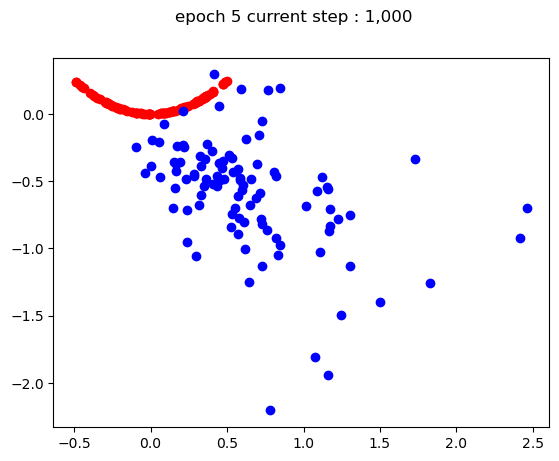


currentStep : 1,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.1478,  2.2111]) y range : tensor([-2.1863,  0.2202]) max - min : tensor([2.3589, 2.4065])
Step 1,000: Generator loss: -0.31691263899207117, crtic loss: 0.4811920460354891
Memory usage (RSS): 354.61328125 MB


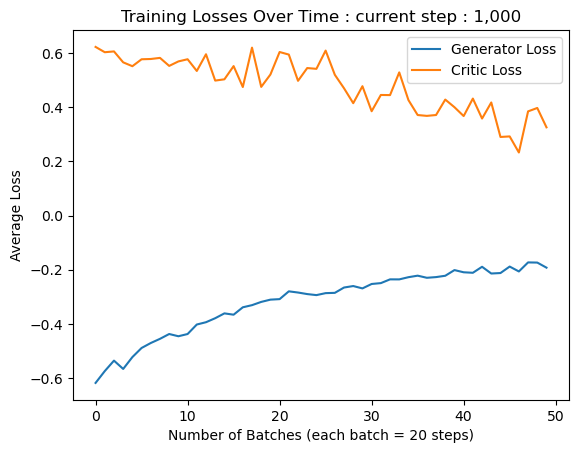

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch010.png


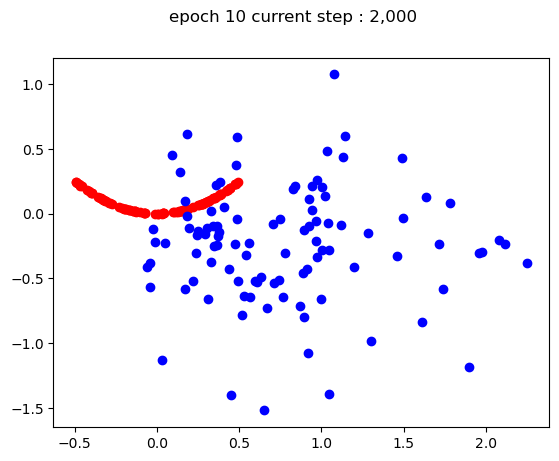


currentStep : 2,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([0.0399, 3.3651]) y range : tensor([-1.1313,  1.0001]) max - min : tensor([3.3252, 2.1314])
Step 2,000: Generator loss: -0.23626308947056532, crtic loss: 0.3519464209524682
Memory usage (RSS): 358.0234375 MB


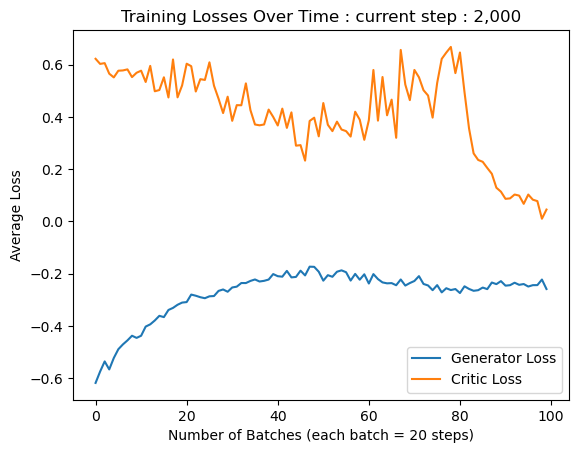

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch015.png


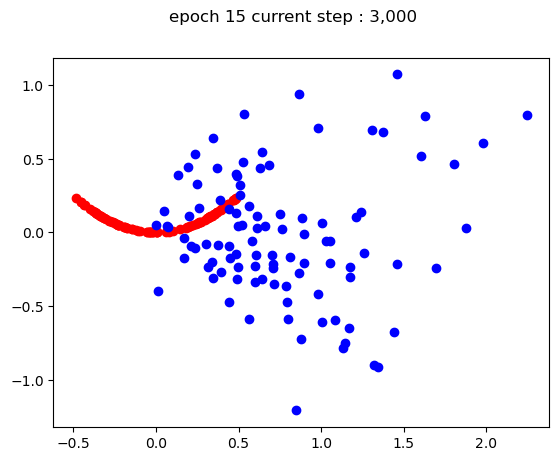


currentStep : 3,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([0.0332, 2.3897]) y range : tensor([-1.1329,  1.5110]) max - min : tensor([2.3565, 2.6439])
Step 3,000: Generator loss: -0.2106631535962224, crtic loss: -0.111995168506354
Memory usage (RSS): 360.22265625 MB


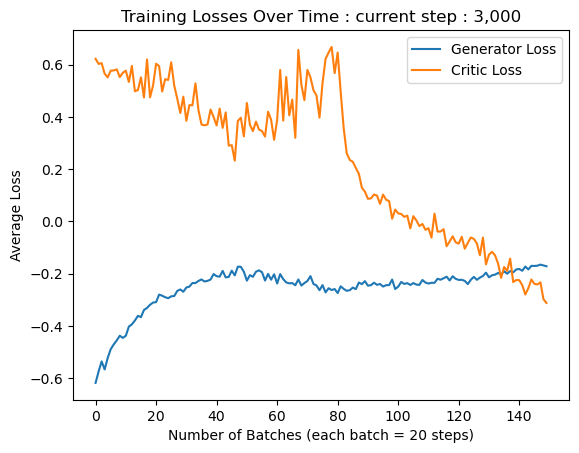

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch020.png


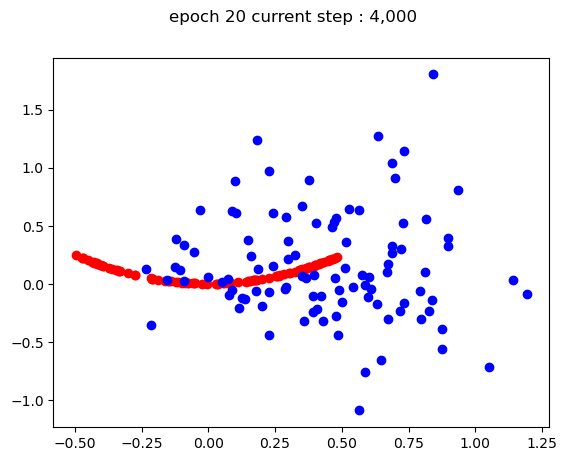


currentStep : 4,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.3111,  1.8916]) y range : tensor([-0.6756,  2.0501]) max - min : tensor([2.2027, 2.7257])
Step 4,000: Generator loss: -0.20163497868925334, crtic loss: -0.35823903478085994
Memory usage (RSS): 361.875 MB


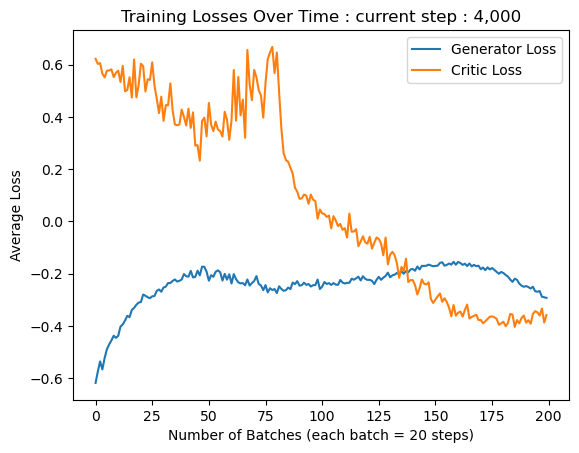

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch025.png


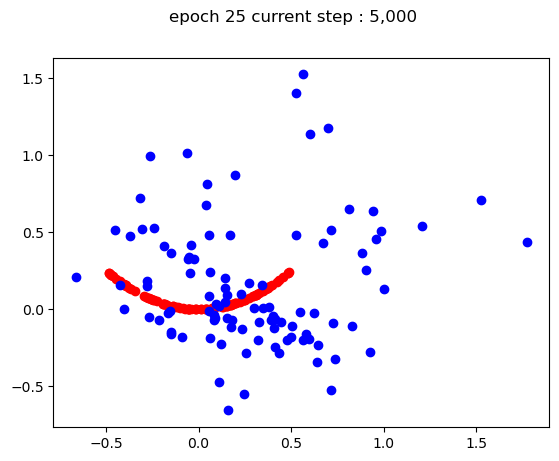


currentStep : 5,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4820,  1.0607]) y range : tensor([-0.8364,  1.0969]) max - min : tensor([1.5427, 1.9333])
Step 5,000: Generator loss: -0.39383002716302873, crtic loss: -0.26740600677430615
Memory usage (RSS): 363.78515625 MB


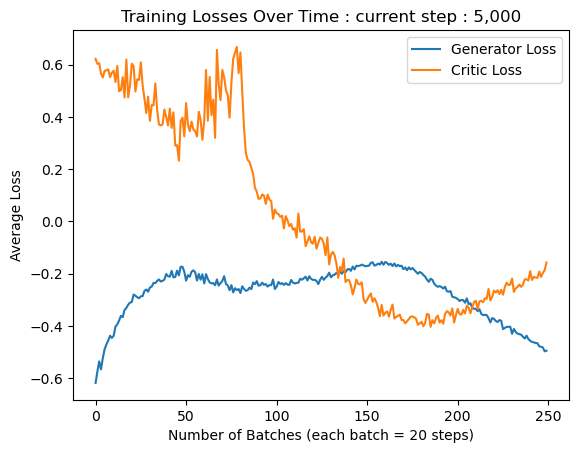

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch030.png


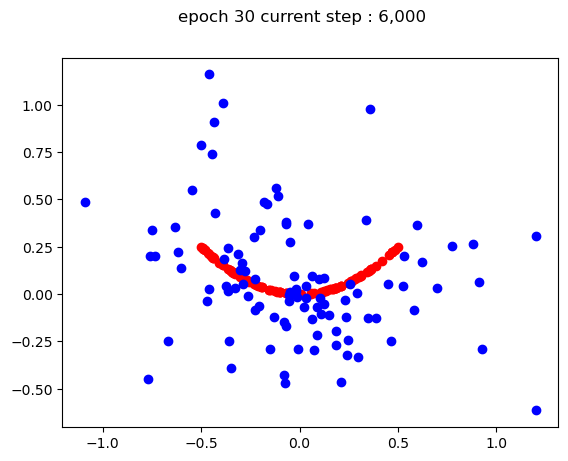


currentStep : 6,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7473,  0.8481]) y range : tensor([-0.9011,  1.2007]) max - min : tensor([1.5954, 2.1018])
Step 6,000: Generator loss: -0.5521309036016464, crtic loss: -0.17096297872811592
Memory usage (RSS): 366.2734375 MB


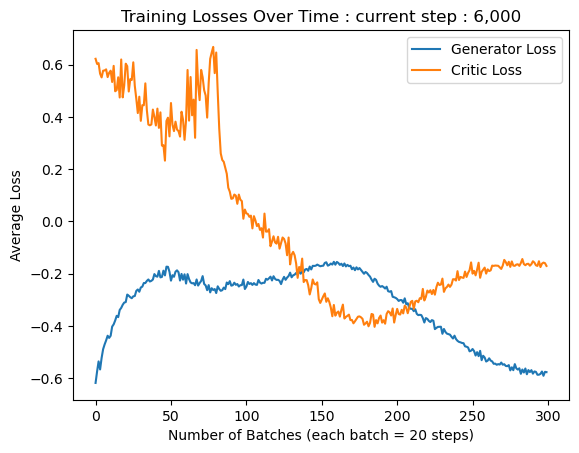

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch035.png


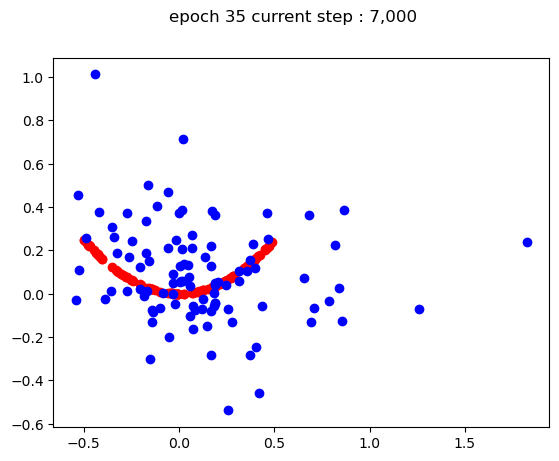


currentStep : 7,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6522,  1.0448]) y range : tensor([-0.4449,  1.6538]) max - min : tensor([1.6970, 2.0987])
Step 7,000: Generator loss: -0.6119082256555557, crtic loss: -0.16039104706943025
Memory usage (RSS): 367.62890625 MB


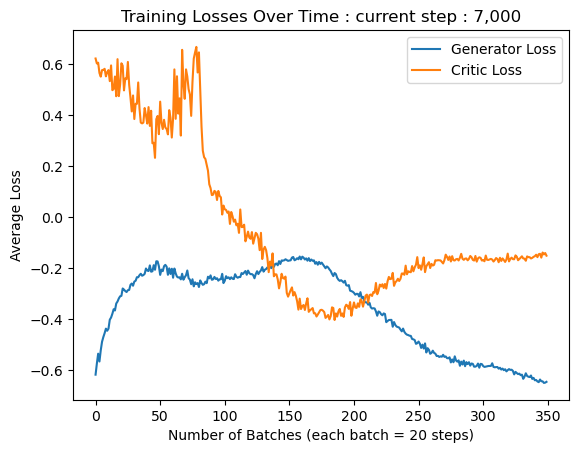

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch040.png


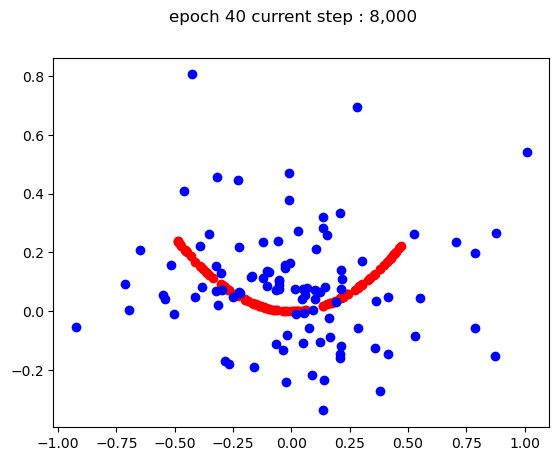


currentStep : 8,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6761,  0.9950]) y range : tensor([-0.2611,  0.7749]) max - min : tensor([1.6711, 1.0360])
Step 8,000: Generator loss: -0.6831912370920181, crtic loss: -0.1391936888515949
Memory usage (RSS): 367.7265625 MB


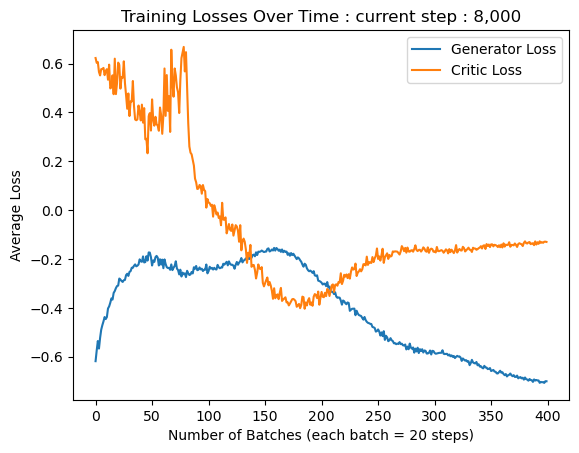

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch045.png


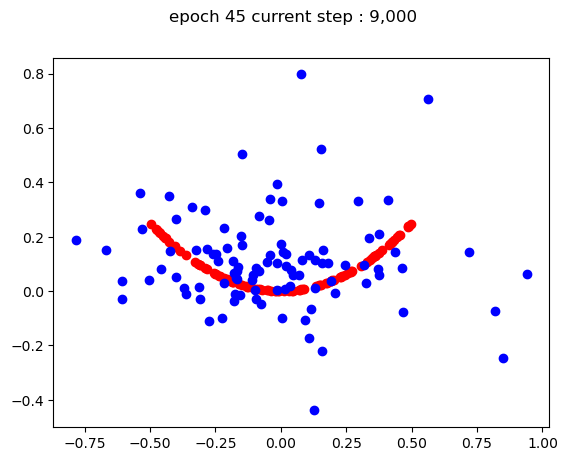


currentStep : 9,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4956,  0.5189]) y range : tensor([-0.1802,  0.7842]) max - min : tensor([1.0145, 0.9644])
Step 9,000: Generator loss: -0.7227861616015434, crtic loss: -0.1171038195043803
Memory usage (RSS): 367.80078125 MB


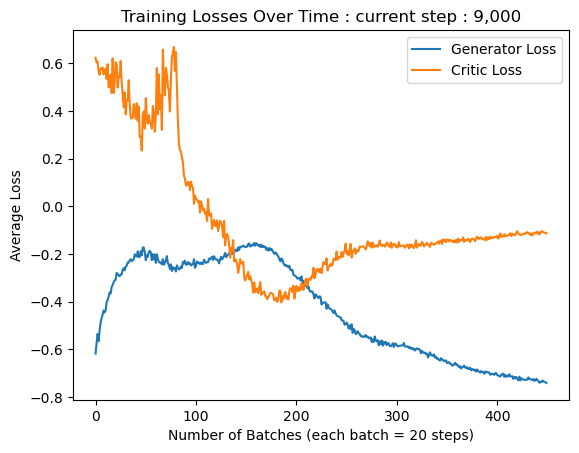

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch050.png


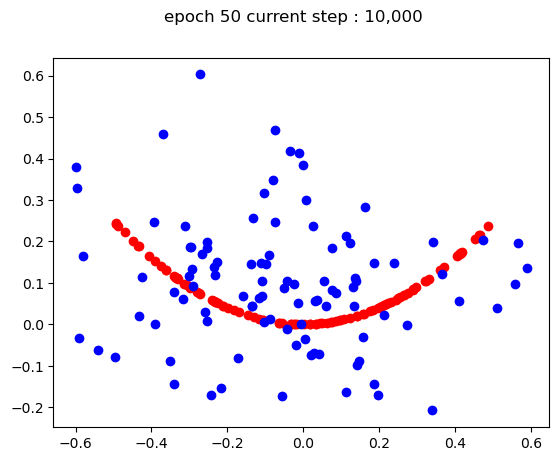


currentStep : 10,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5329,  0.8668]) y range : tensor([-0.3232,  1.1838]) max - min : tensor([1.3997, 1.5070])
Step 10,000: Generator loss: -0.753494488477707, crtic loss: -0.10632220341116194
Memory usage (RSS): 367.84765625 MB


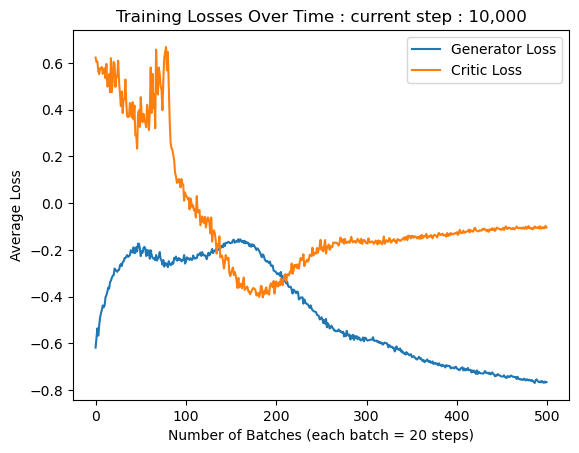

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch055.png


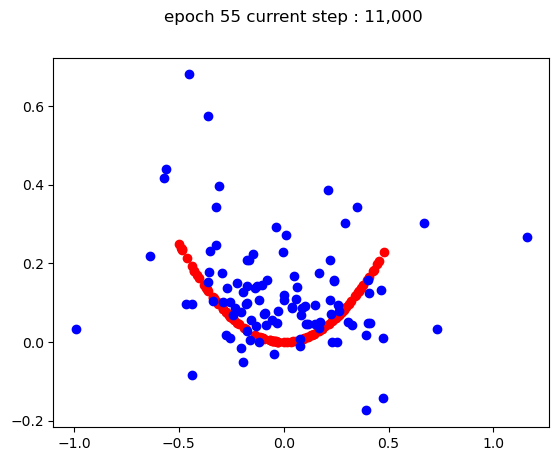


currentStep : 11,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6229,  0.9363]) y range : tensor([-0.1806,  0.5795]) max - min : tensor([1.5592, 0.7601])
Step 11,000: Generator loss: -0.7780445485115052, crtic loss: -0.09952181172147401
Memory usage (RSS): 367.84765625 MB


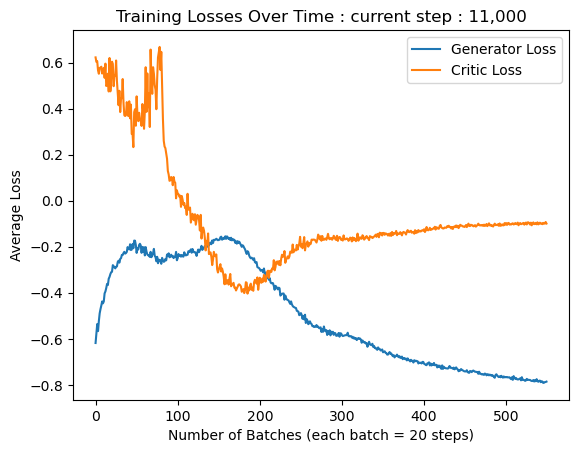

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch060.png


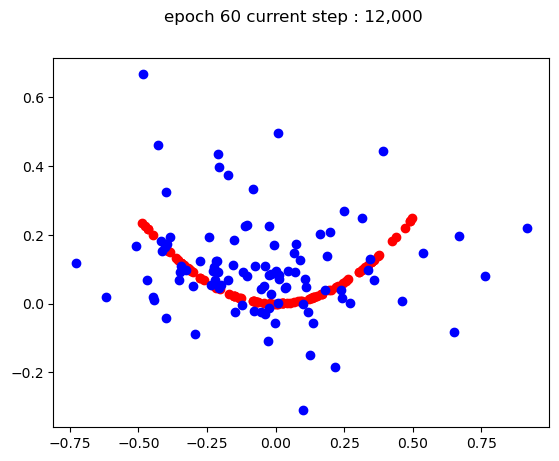


currentStep : 12,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7687,  0.8495]) y range : tensor([-0.1855,  0.5136]) max - min : tensor([1.6182, 0.6991])
Step 12,000: Generator loss: -0.7926517514586449, crtic loss: -0.09427428511232135
Memory usage (RSS): 367.98046875 MB


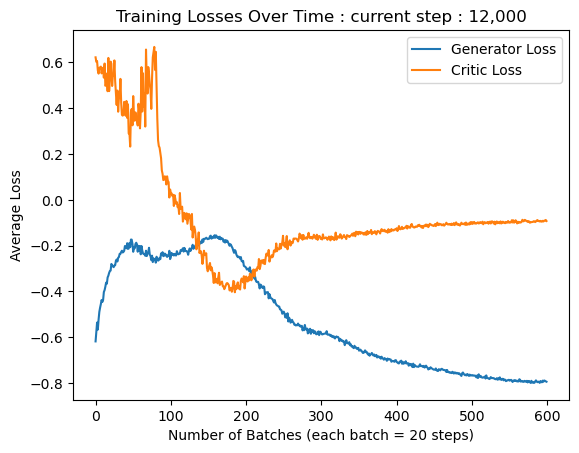

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch065.png


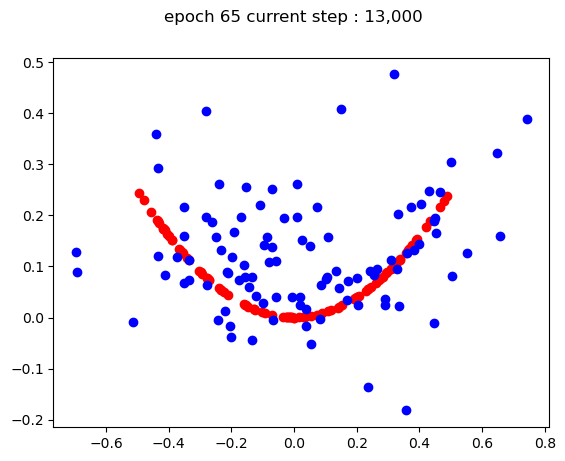


currentStep : 13,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5850,  0.5165]) y range : tensor([-0.2676,  0.7219]) max - min : tensor([1.1015, 0.9895])
Step 13,000: Generator loss: -0.8012899823784828, crtic loss: -0.08706931829079988
Memory usage (RSS): 369.54296875 MB


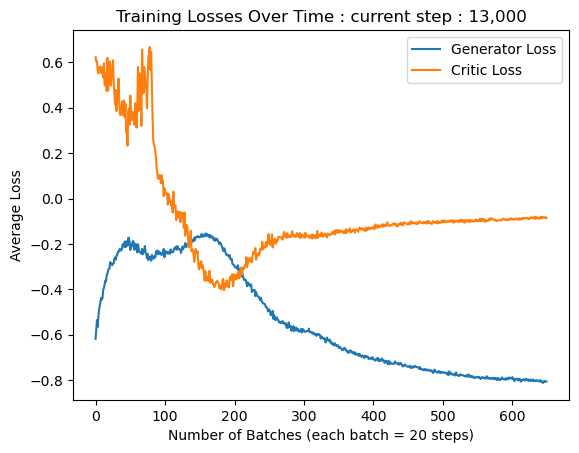

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch070.png


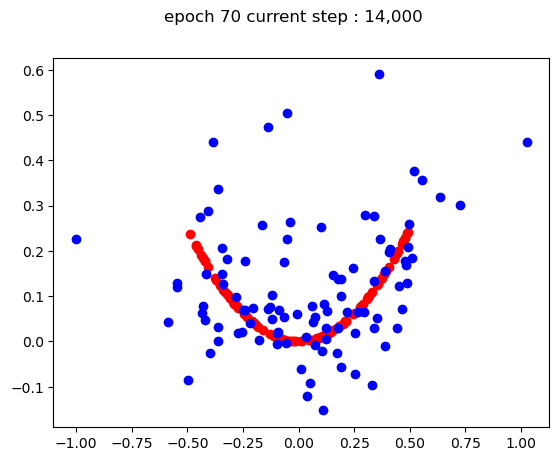


currentStep : 14,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4577,  0.6007]) y range : tensor([-0.2068,  0.5199]) max - min : tensor([1.0584, 0.7267])
Step 14,000: Generator loss: -0.8114718686342239, crtic loss: -0.07982447861135013
Memory usage (RSS): 372.3046875 MB


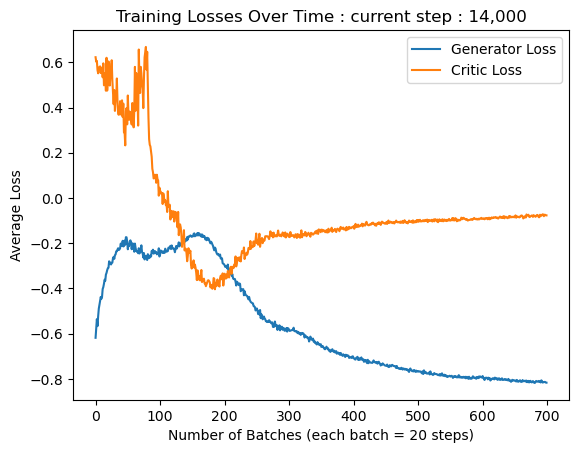

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch075.png


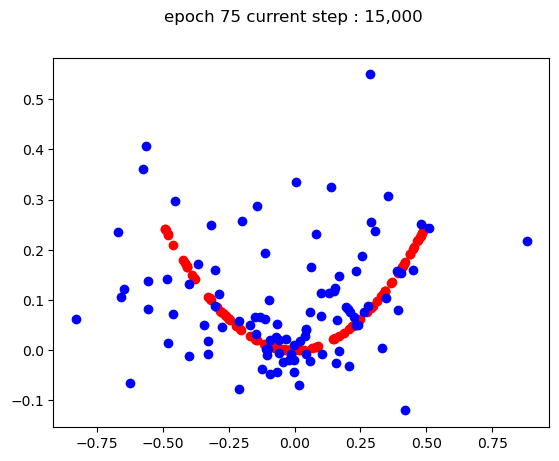


currentStep : 15,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6142,  0.7606]) y range : tensor([-0.1326,  0.5130]) max - min : tensor([1.3747, 0.6457])
Step 15,000: Generator loss: -0.8180222684144973, crtic loss: -0.07265857372432952
Memory usage (RSS): 374.390625 MB


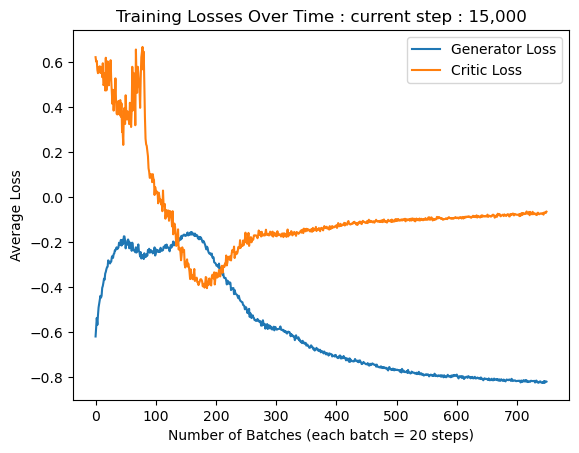

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch080.png


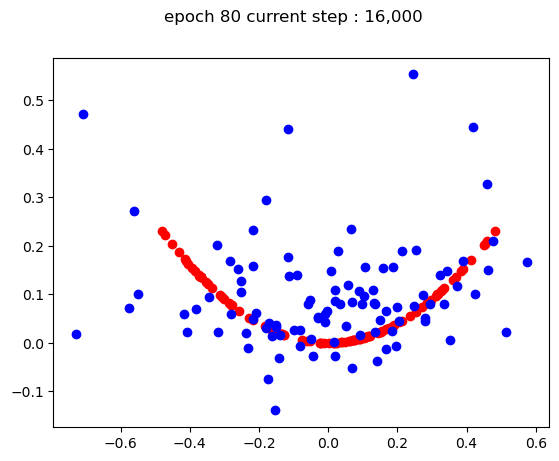


currentStep : 16,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.8366,  0.7744]) y range : tensor([-0.0903,  0.3675]) max - min : tensor([1.6111, 0.4578])
Step 16,000: Generator loss: -0.8184761643409729, crtic loss: -0.06692987803630525
Memory usage (RSS): 377.15234375 MB


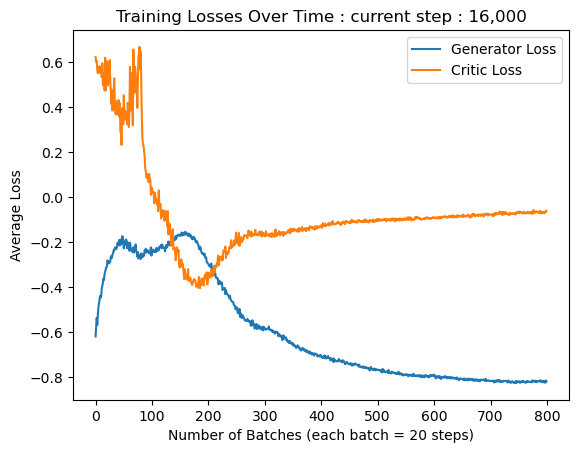

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch085.png


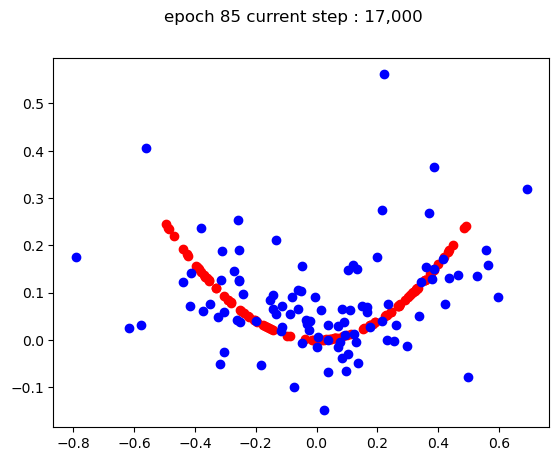


currentStep : 17,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7230,  0.9284]) y range : tensor([-0.0744,  0.4525]) max - min : tensor([1.6515, 0.5269])
Step 17,000: Generator loss: -0.8147231124639511, crtic loss: -0.06275136747322974
Memory usage (RSS): 378.41796875 MB


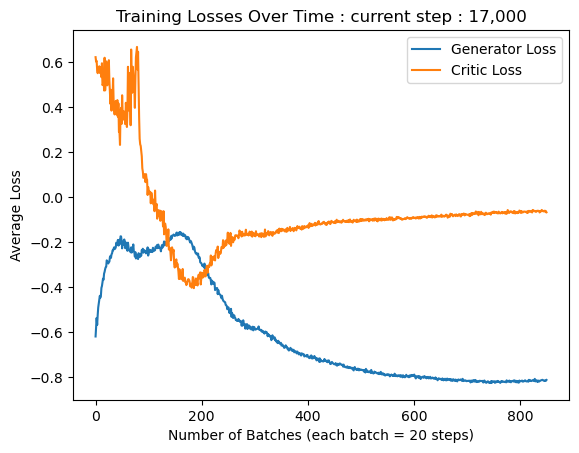

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch090.png


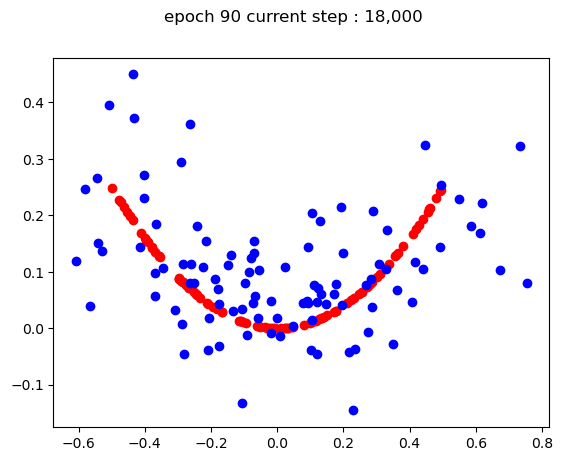


currentStep : 18,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5519,  0.7351]) y range : tensor([-0.0424,  0.3303]) max - min : tensor([1.2870, 0.3727])
Step 18,000: Generator loss: -0.8098111039996148, crtic loss: -0.059396602002903885
Memory usage (RSS): 380.22265625 MB


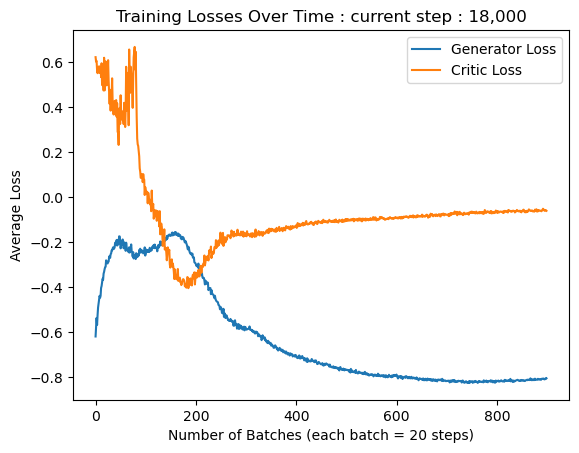

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch095.png


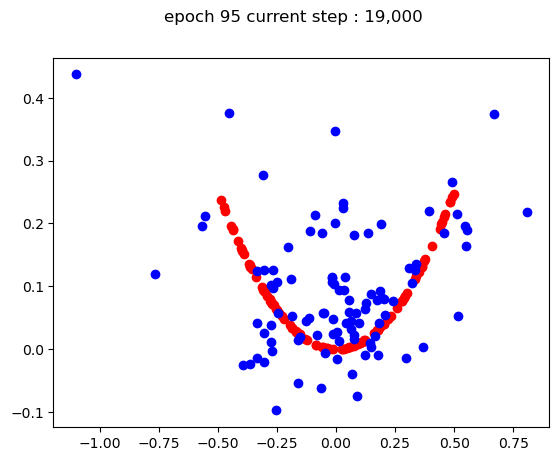


currentStep : 19,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.8128,  0.6357]) y range : tensor([-0.1066,  0.5018]) max - min : tensor([1.4485, 0.6084])
Step 19,000: Generator loss: -0.8026134587526321, crtic loss: -0.056268239648267576
Memory usage (RSS): 382.0546875 MB


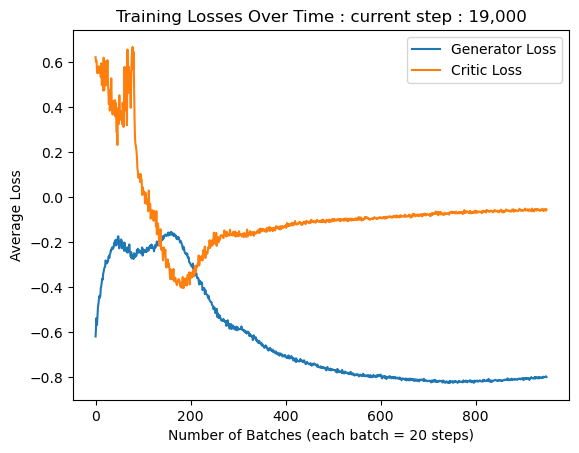

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch100.png


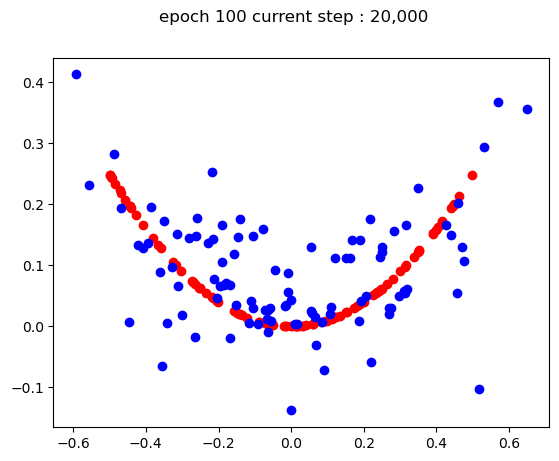


currentStep : 20,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7787,  1.0342]) y range : tensor([-0.0570,  0.6221]) max - min : tensor([1.8128, 0.6791])
Step 20,000: Generator loss: -0.7963975744247437, crtic loss: -0.05370205681659285
Memory usage (RSS): 384.76171875 MB


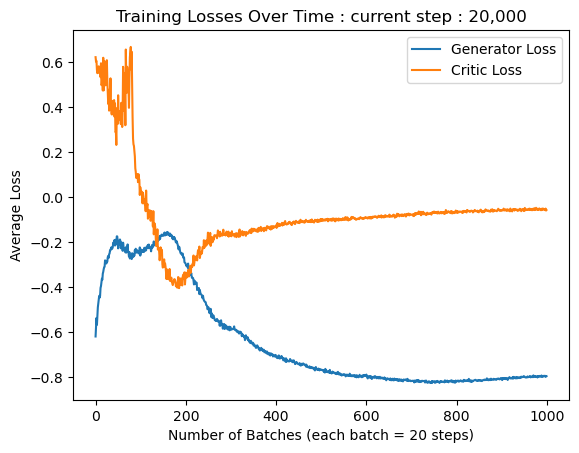

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch105.png


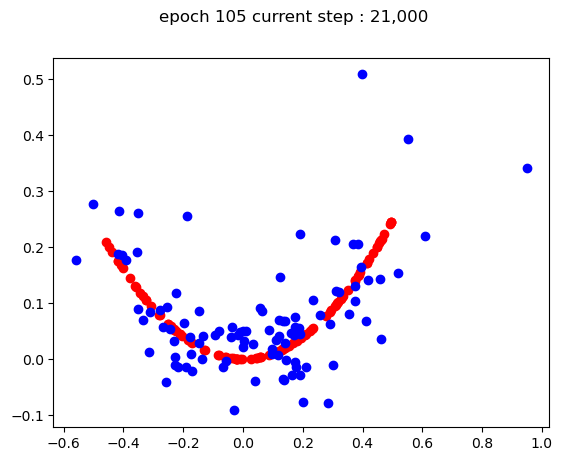


currentStep : 21,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7084,  0.6348]) y range : tensor([-0.0650,  0.4079]) max - min : tensor([1.3431, 0.4728])
Step 21,000: Generator loss: -0.791641578912735, crtic loss: -0.05316494162827728
Memory usage (RSS): 386.17578125 MB


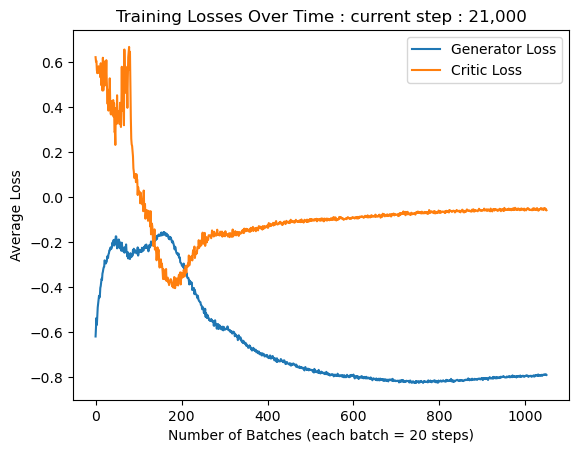

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch110.png


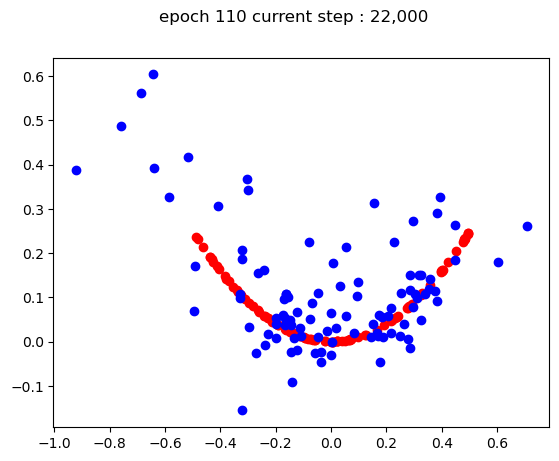


currentStep : 22,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7141,  0.7638]) y range : tensor([-0.0806,  0.3533]) max - min : tensor([1.4780, 0.4340])
Step 22,000: Generator loss: -0.78358866751194, crtic loss: -0.05148275580257179
Memory usage (RSS): 388.83984375 MB


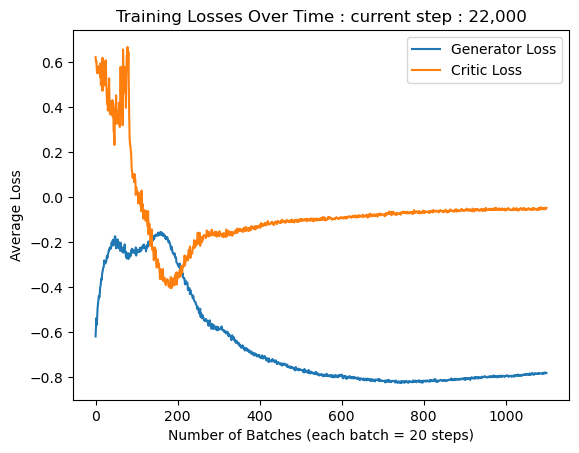

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch115.png


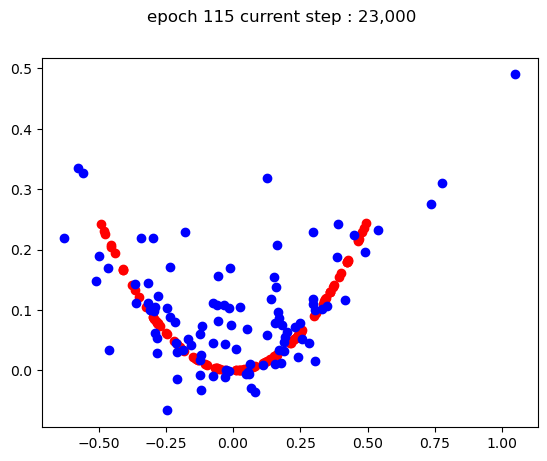


currentStep : 23,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6542,  0.5451]) y range : tensor([-0.0840,  0.3396]) max - min : tensor([1.1993, 0.4236])
Step 23,000: Generator loss: -0.7769853638410569, crtic loss: -0.04913593997135758
Memory usage (RSS): 391.6171875 MB


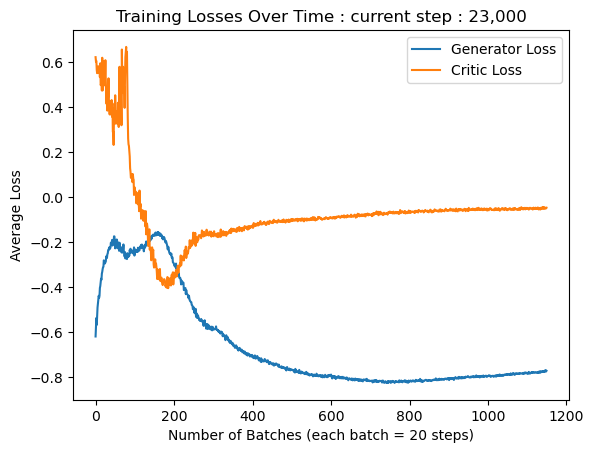

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch120.png


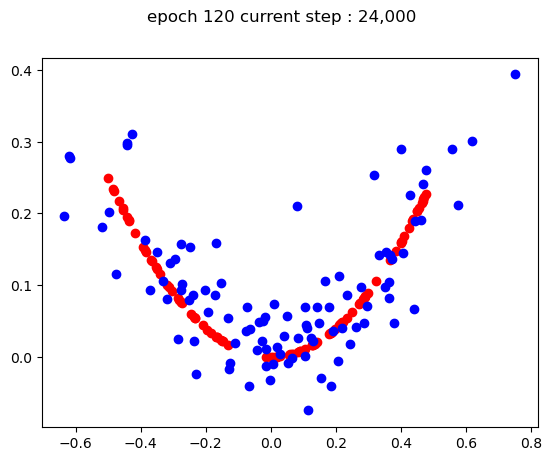


currentStep : 24,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7450,  0.8340]) y range : tensor([-0.1164,  0.4886]) max - min : tensor([1.5790, 0.6050])
Step 24,000: Generator loss: -0.7683995838761329, crtic loss: -0.047788553598523104
Memory usage (RSS): 394.12890625 MB


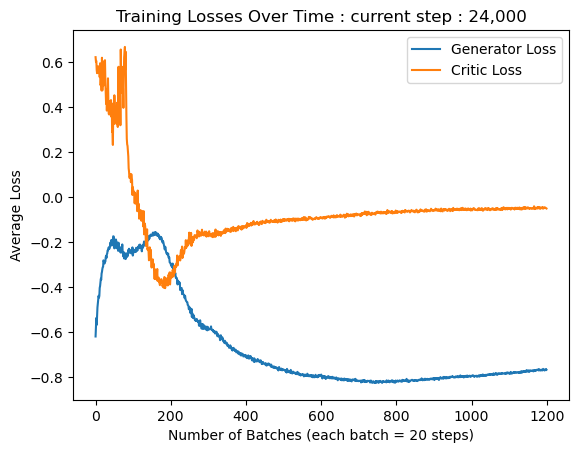

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch125.png


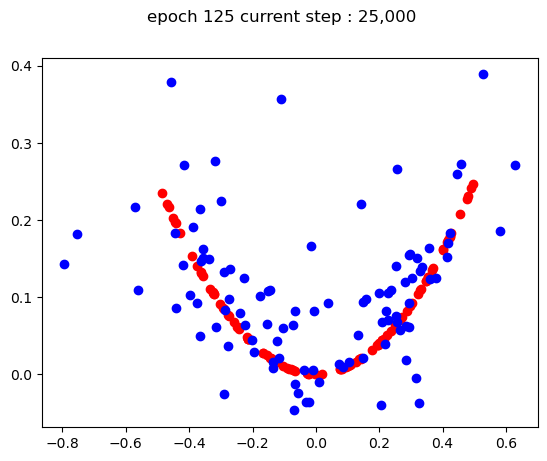


currentStep : 25,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-1.0030,  0.6061]) y range : tensor([-0.0622,  0.3956]) max - min : tensor([1.6092, 0.4578])
Step 25,000: Generator loss: -0.7623115777373314, crtic loss: -0.04592429611030968
Memory usage (RSS): 396.5625 MB


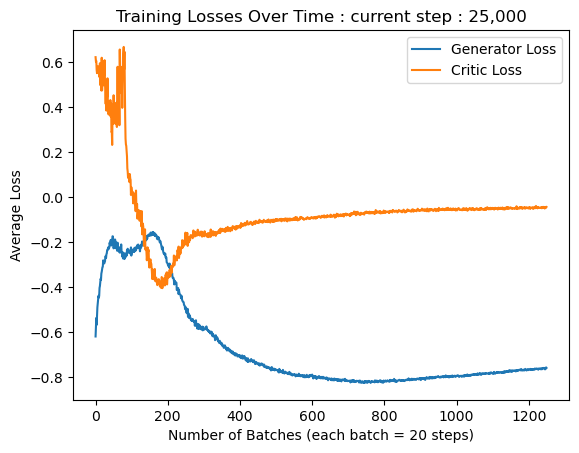

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch130.png


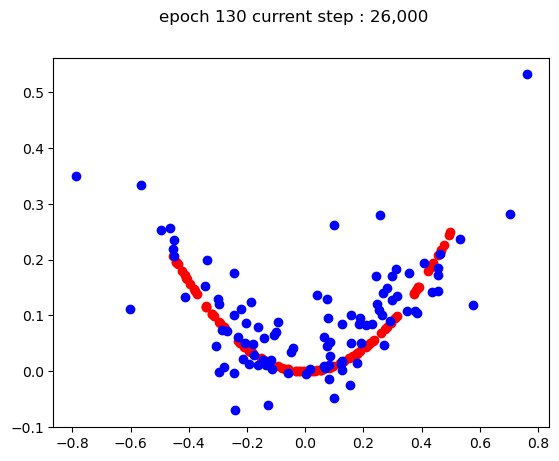


currentStep : 26,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5831,  0.6232]) y range : tensor([-0.0620,  0.3739]) max - min : tensor([1.2063, 0.4359])
Step 26,000: Generator loss: -0.7558309366106987, crtic loss: -0.0445239169336855
Memory usage (RSS): 398.91796875 MB


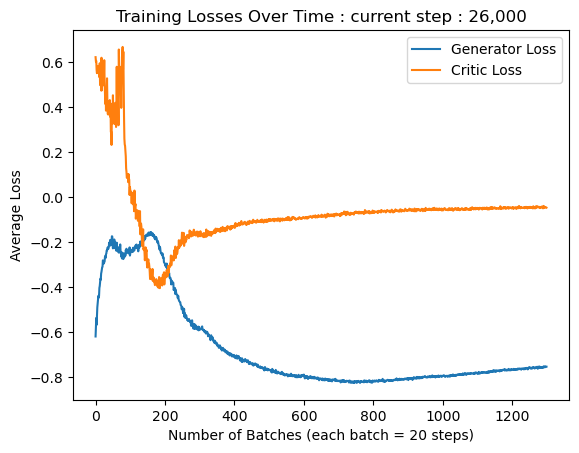

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch135.png


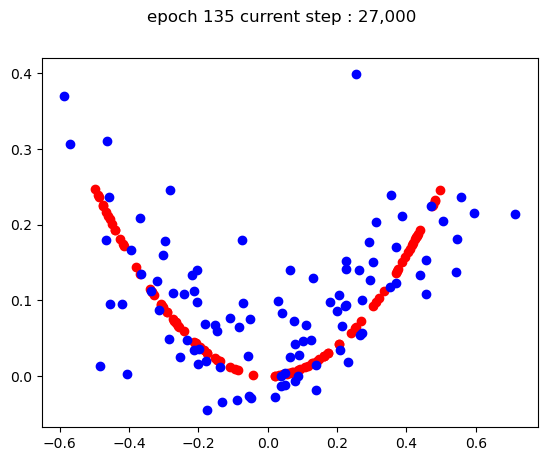


currentStep : 27,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5806,  0.6898]) y range : tensor([-0.0286,  0.4340]) max - min : tensor([1.2704, 0.4625])
Step 27,000: Generator loss: -0.7501820319890976, crtic loss: -0.04285275347791607
Memory usage (RSS): 401.203125 MB


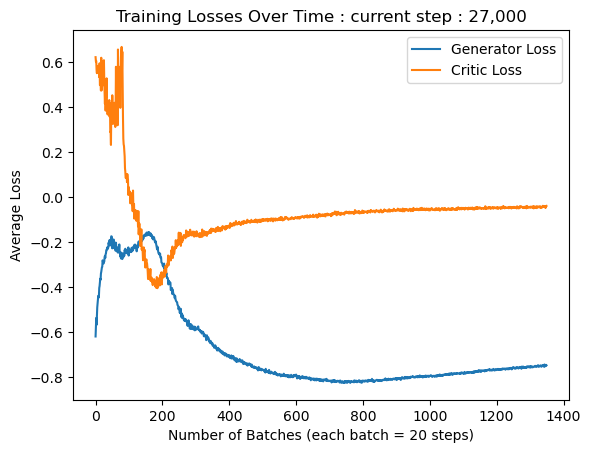

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch140.png


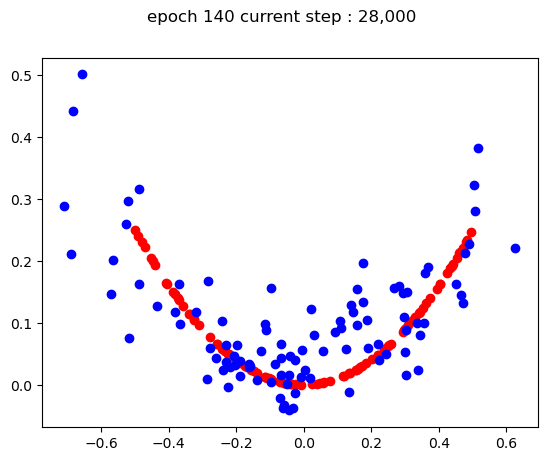


currentStep : 28,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7153,  0.7709]) y range : tensor([-0.0743,  0.3982]) max - min : tensor([1.4862, 0.4725])
Step 28,000: Generator loss: -0.7437964840531349, crtic loss: -0.041782478441297954
Memory usage (RSS): 401.625 MB


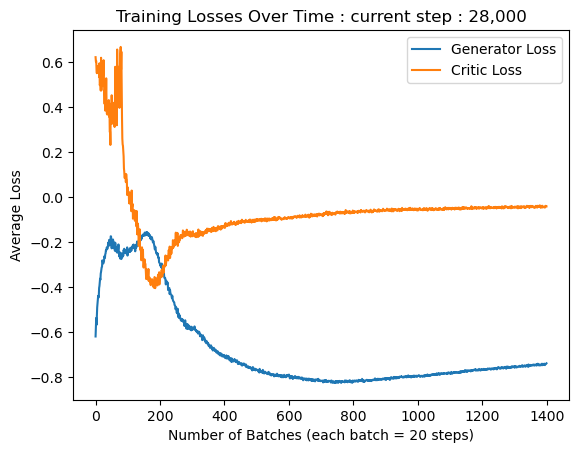

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch145.png


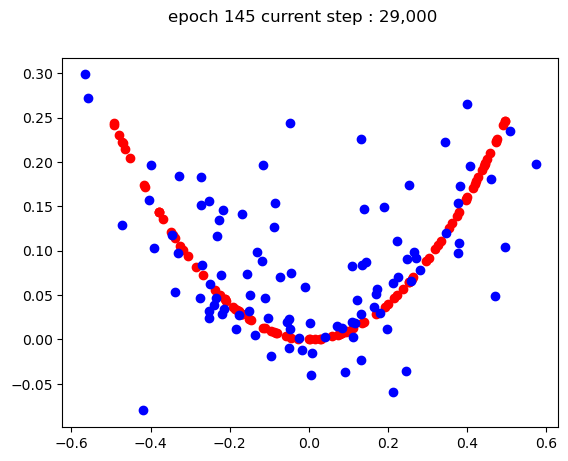


currentStep : 29,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6774,  0.9859]) y range : tensor([-0.0614,  0.4463]) max - min : tensor([1.6634, 0.5077])
Step 29,000: Generator loss: -0.7363486868143082, crtic loss: -0.04008503263276069
Memory usage (RSS): 401.828125 MB


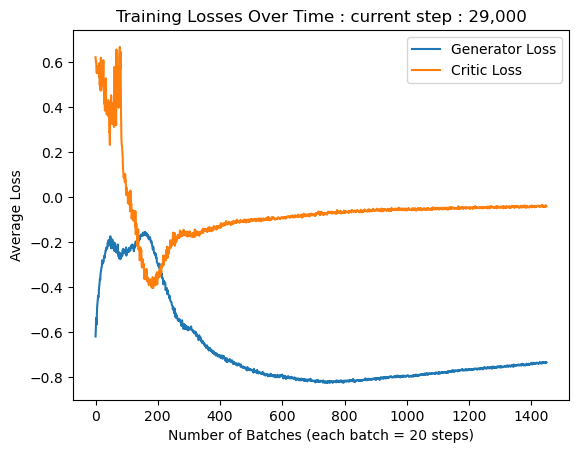

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch150.png


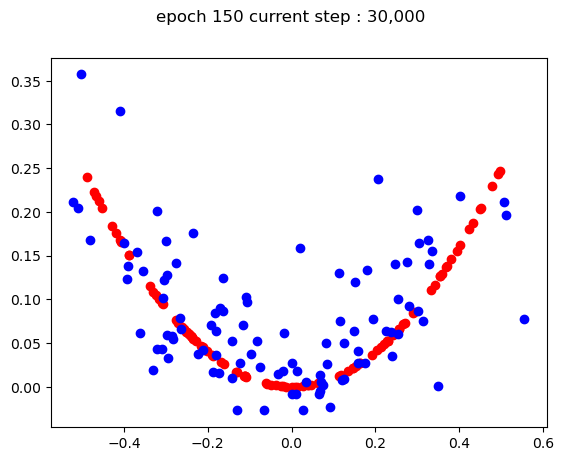


currentStep : 30,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6124,  0.6927]) y range : tensor([-0.0477,  0.3557]) max - min : tensor([1.3051, 0.4034])
Step 30,000: Generator loss: -0.7314596038460731, crtic loss: -0.038680635911785055
Memory usage (RSS): 401.87109375 MB


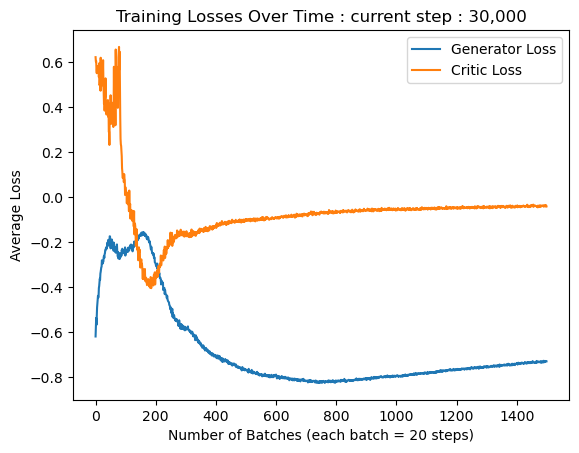

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch155.png


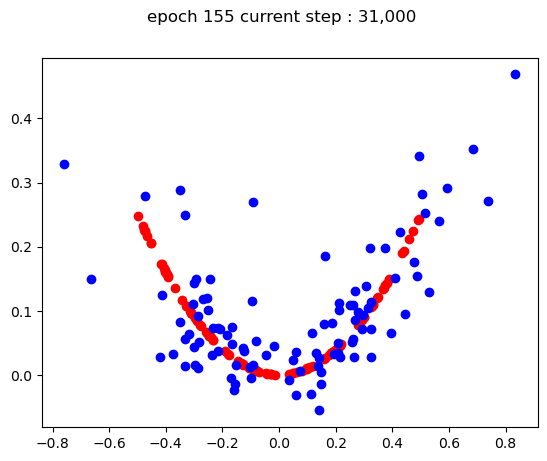


currentStep : 31,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5263,  0.8877]) y range : tensor([-0.0292,  0.5666]) max - min : tensor([1.4140, 0.5957])
Step 31,000: Generator loss: -0.7276956686377525, crtic loss: -0.038397893902938816
Memory usage (RSS): 401.98046875 MB


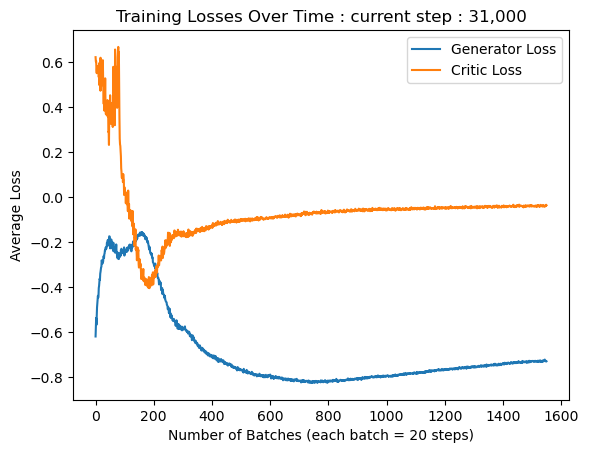

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch160.png


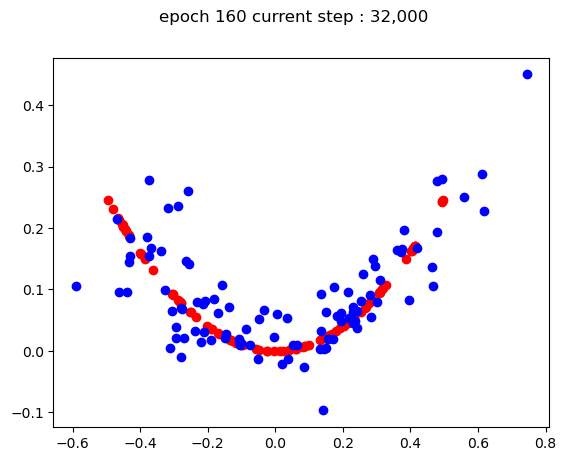


currentStep : 32,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5792,  0.6156]) y range : tensor([-0.0567,  0.3960]) max - min : tensor([1.1948, 0.4527])
Step 32,000: Generator loss: -0.7255653178095818, crtic loss: -0.03699422422237697
Memory usage (RSS): 401.9921875 MB


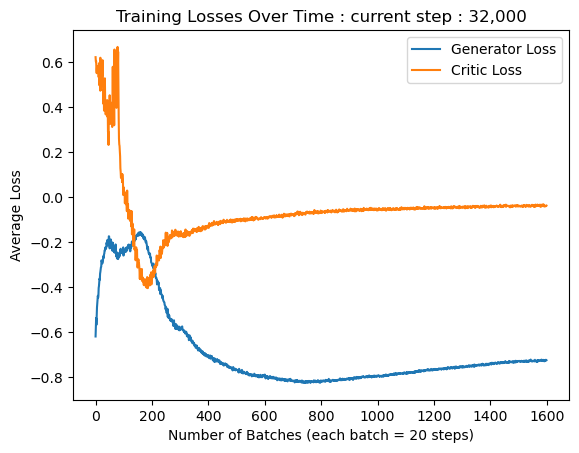

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch165.png


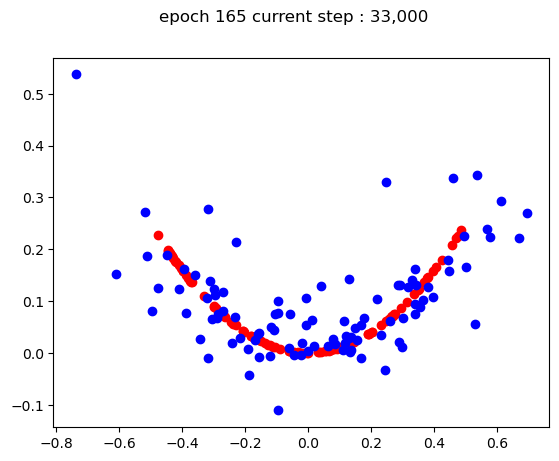


currentStep : 33,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6550,  0.8907]) y range : tensor([-0.0360,  0.3975]) max - min : tensor([1.5457, 0.4336])
Step 33,000: Generator loss: -0.7239422600865364, crtic loss: -0.036119573074579234
Memory usage (RSS): 402.0078125 MB


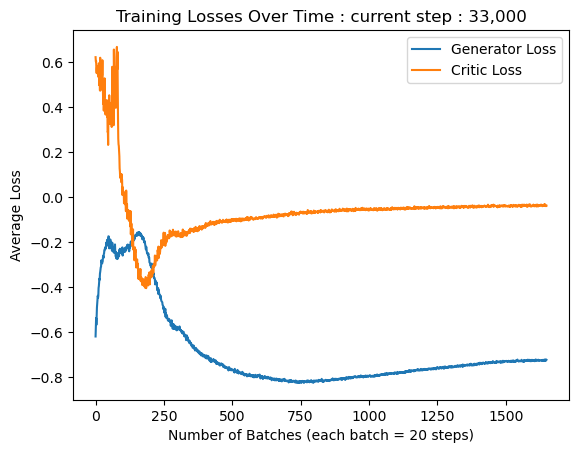

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch170.png


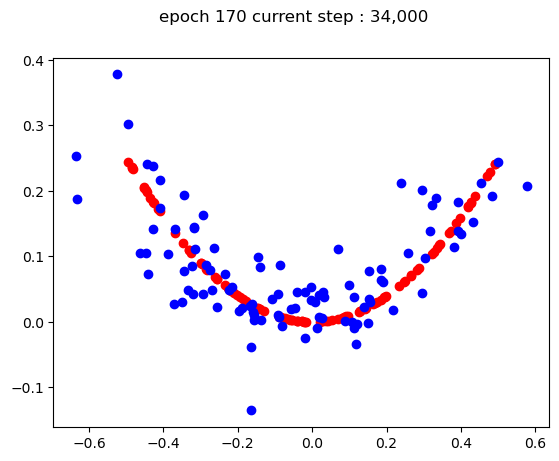


currentStep : 34,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5798,  0.7334]) y range : tensor([-0.0547,  0.3213]) max - min : tensor([1.3132, 0.3760])
Step 34,000: Generator loss: -0.7257530227303505, crtic loss: -0.03443021552283313
Memory usage (RSS): 402.109375 MB


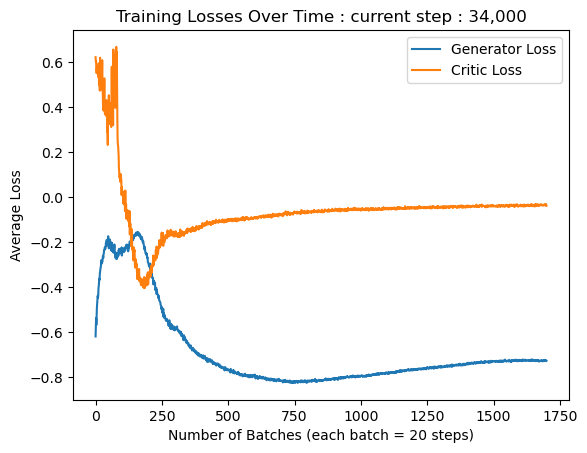

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch175.png


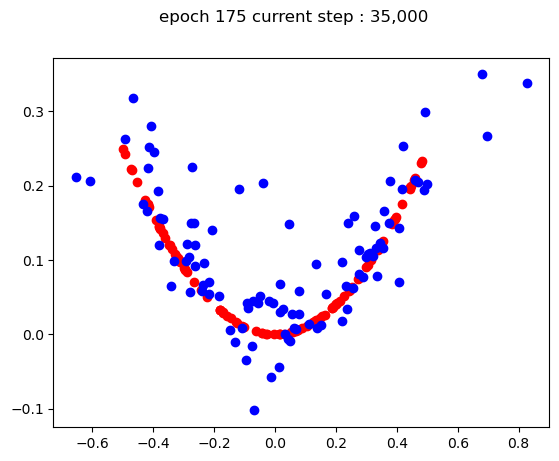


currentStep : 35,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6478,  0.6285]) y range : tensor([-0.0247,  0.4109]) max - min : tensor([1.2764, 0.4356])
Step 35,000: Generator loss: -0.7251246069073677, crtic loss: -0.03340681228227916
Memory usage (RSS): 402.11328125 MB


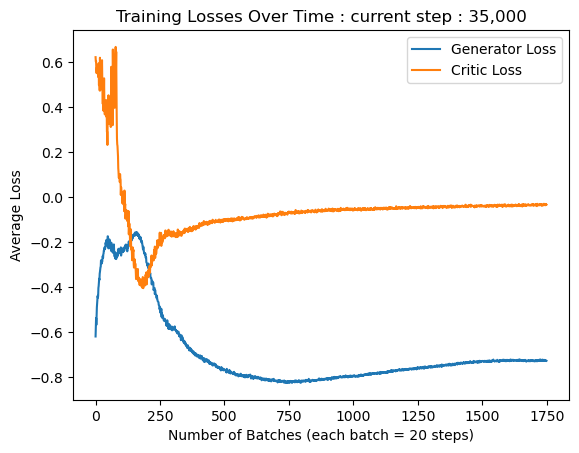

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch180.png


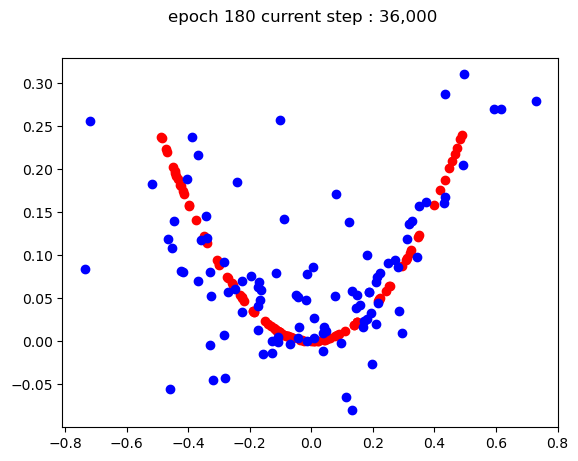


currentStep : 36,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6401,  0.5042]) y range : tensor([-0.0510,  0.3748]) max - min : tensor([1.1443, 0.4258])
Step 36,000: Generator loss: -0.726789954841137, crtic loss: -0.032696245075110354
Memory usage (RSS): 402.11328125 MB


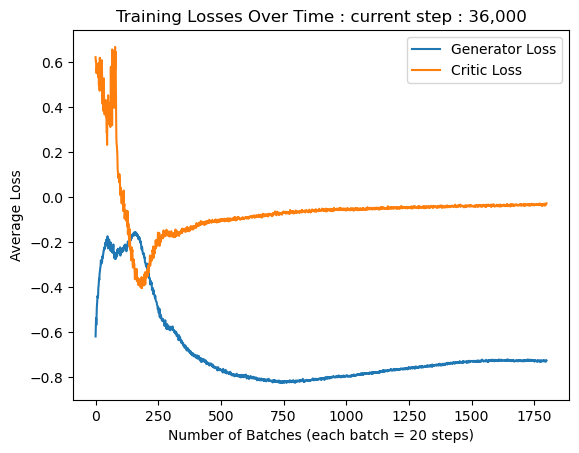

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch185.png


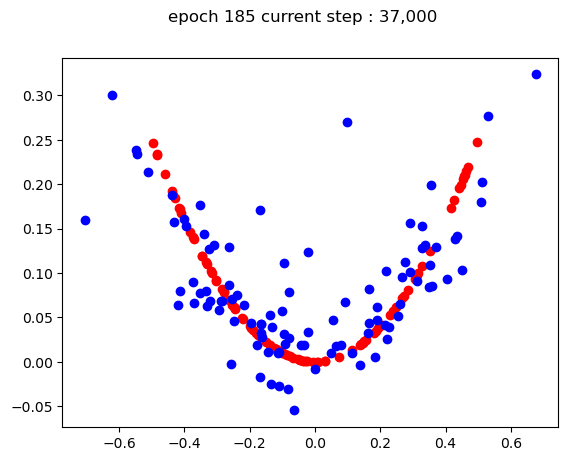


currentStep : 37,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4912,  0.7331]) y range : tensor([-0.0399,  0.2670]) max - min : tensor([1.2243, 0.3069])
Step 37,000: Generator loss: -0.7272530713677406, crtic loss: -0.031530922705121346
Memory usage (RSS): 402.21875 MB


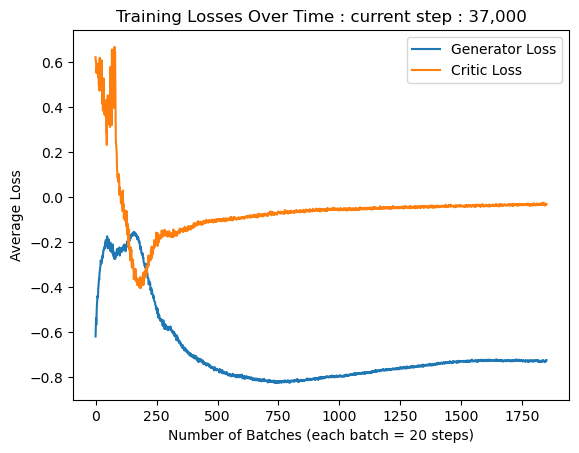

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch190.png


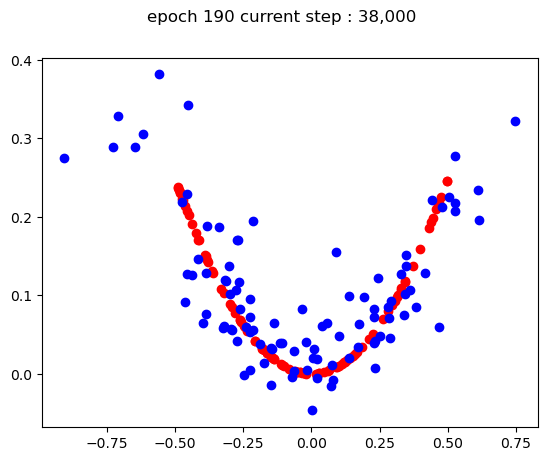


currentStep : 38,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5524,  0.5660]) y range : tensor([-0.0662,  0.2892]) max - min : tensor([1.1184, 0.3554])
Step 38,000: Generator loss: -0.7251217413544655, crtic loss: -0.030096191855426866
Memory usage (RSS): 402.265625 MB


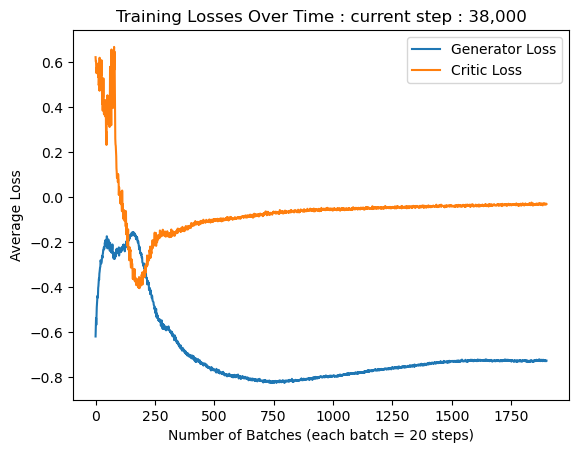

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch195.png


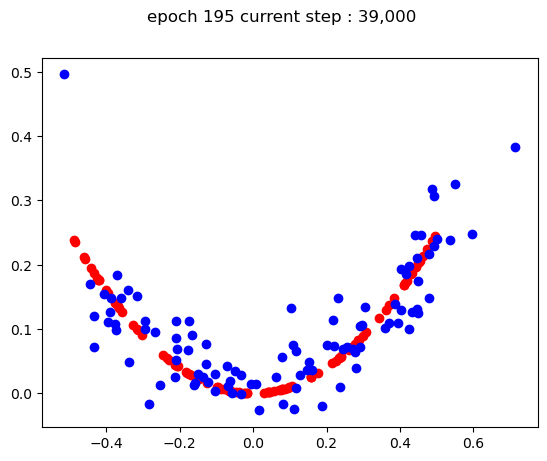


currentStep : 39,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5524,  0.7224]) y range : tensor([-0.0485,  0.3140]) max - min : tensor([1.2748, 0.3625])
Step 39,000: Generator loss: -0.7247823584675789, crtic loss: -0.02894324168376623
Memory usage (RSS): 402.3359375 MB


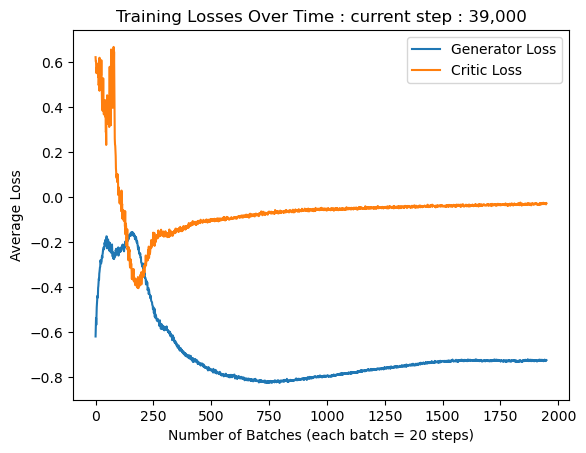

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch200.png


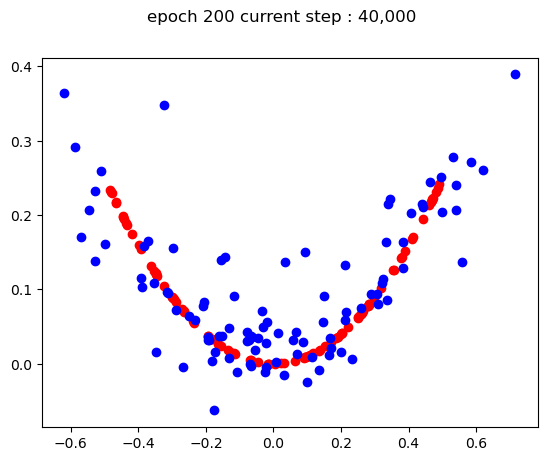


currentStep : 40,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4801,  0.7949]) y range : tensor([-0.0501,  0.3644]) max - min : tensor([1.2750, 0.4145])
Step 40,000: Generator loss: -0.724293394267559, crtic loss: -0.027838986252760486
Memory usage (RSS): 402.3359375 MB


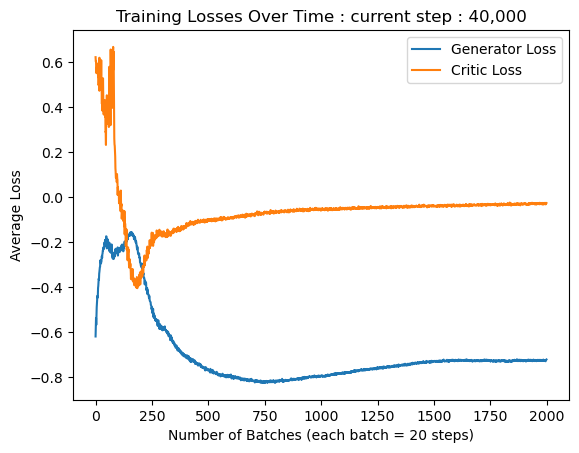

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch205.png


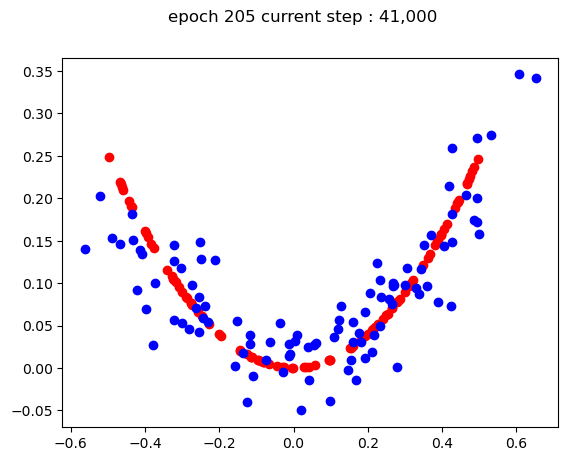


currentStep : 41,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4339,  0.6834]) y range : tensor([-0.0621,  0.3885]) max - min : tensor([1.1173, 0.4505])
Step 41,000: Generator loss: -0.7236243016719818, crtic loss: -0.026272786180954424
Memory usage (RSS): 402.359375 MB


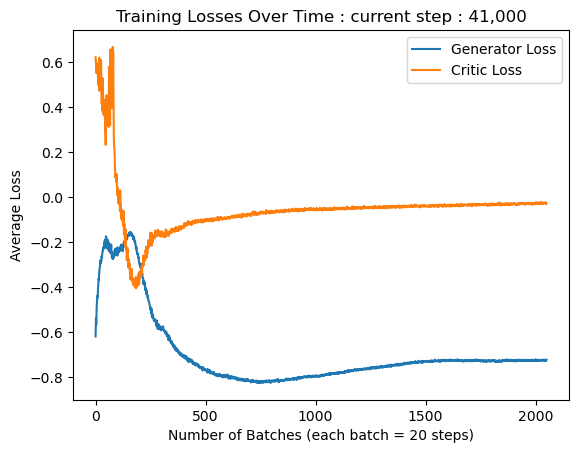

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch210.png


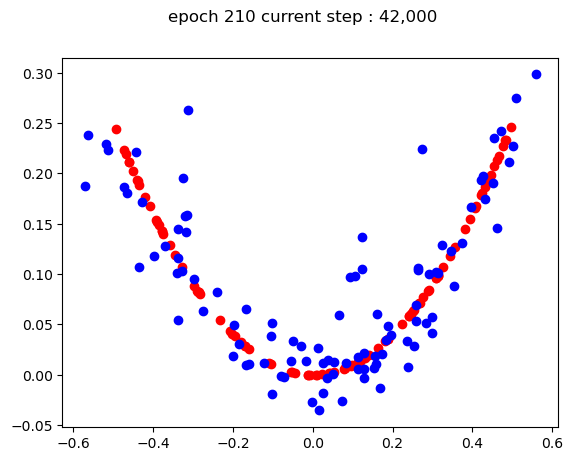


currentStep : 42,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6233,  0.5986]) y range : tensor([-0.0173,  0.2835]) max - min : tensor([1.2219, 0.3008])
Step 42,000: Generator loss: -0.7246893926262855, crtic loss: -0.02540267004827036
Memory usage (RSS): 402.5859375 MB


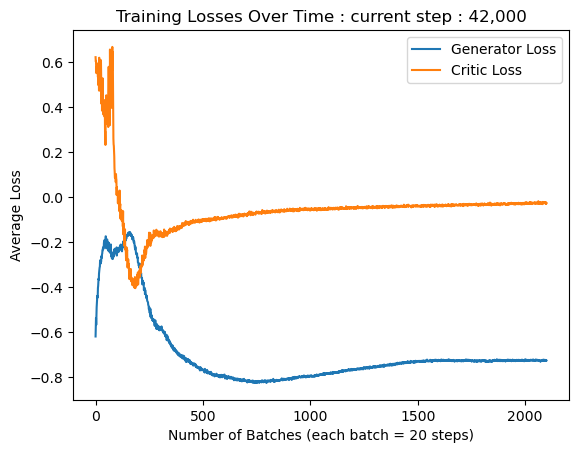

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch215.png


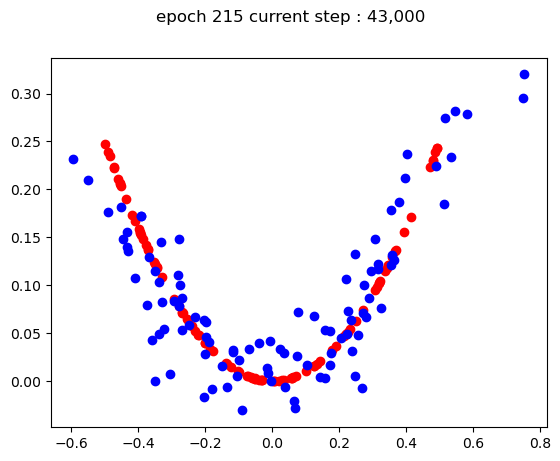


currentStep : 43,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7556,  0.5679]) y range : tensor([-0.0224,  0.3398]) max - min : tensor([1.3235, 0.3621])
Step 43,000: Generator loss: -0.7239749763607979, crtic loss: -0.024561948453215833
Memory usage (RSS): 402.86328125 MB


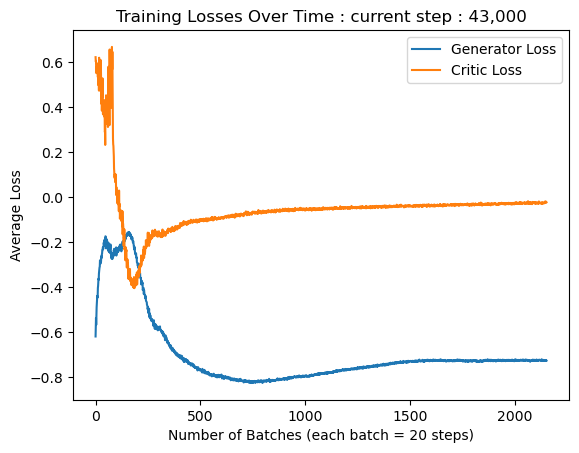

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch220.png


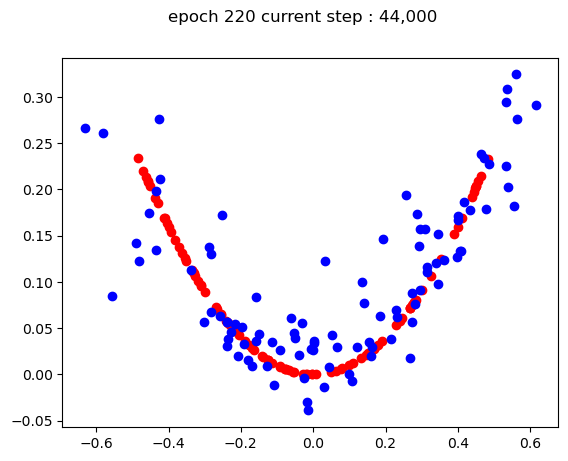


currentStep : 44,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.7720,  0.6028]) y range : tensor([-0.0781,  0.3265]) max - min : tensor([1.3747, 0.4045])
Step 44,000: Generator loss: -0.7248579031229019, crtic loss: -0.022863045537006077
Memory usage (RSS): 403.09765625 MB


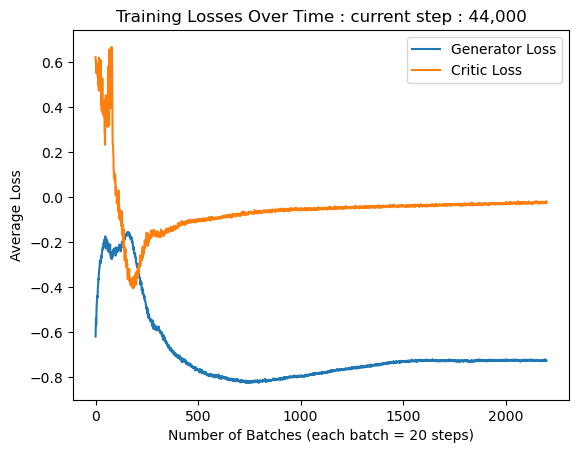

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch225.png


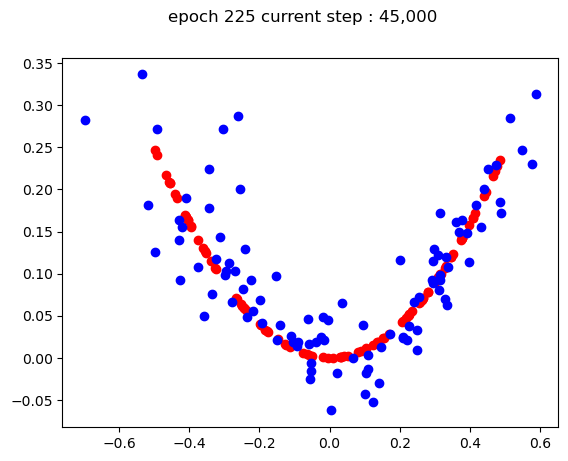


currentStep : 45,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4967,  0.4472]) y range : tensor([-0.0562,  0.2348]) max - min : tensor([0.9439, 0.2910])
Step 45,000: Generator loss: -0.7266834522485733, crtic loss: -0.02226637564795091
Memory usage (RSS): 404.3515625 MB


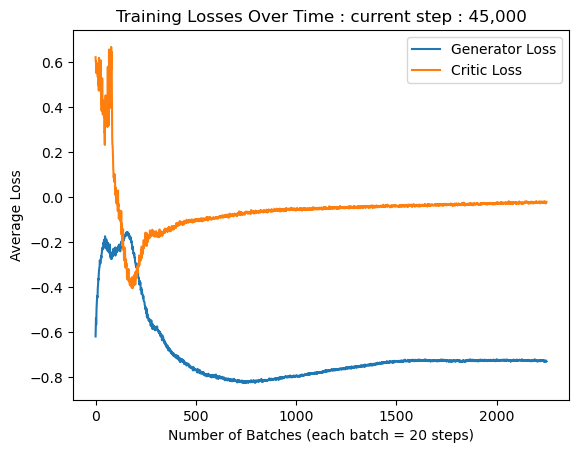

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch230.png


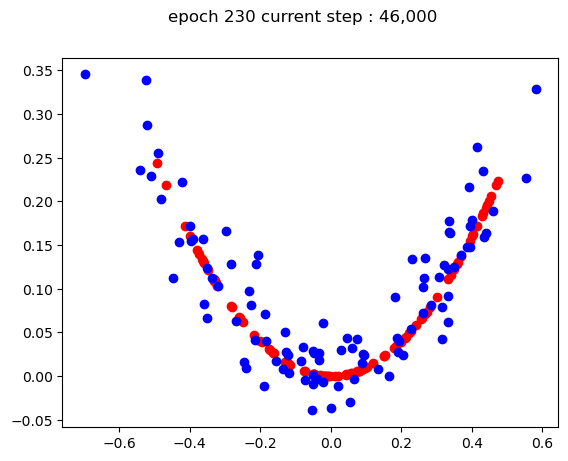


currentStep : 46,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4615,  0.5691]) y range : tensor([-0.0563,  0.2506]) max - min : tensor([1.0306, 0.3070])
Step 46,000: Generator loss: -0.726289354801178, crtic loss: -0.021137258164072407
Memory usage (RSS): 406.015625 MB


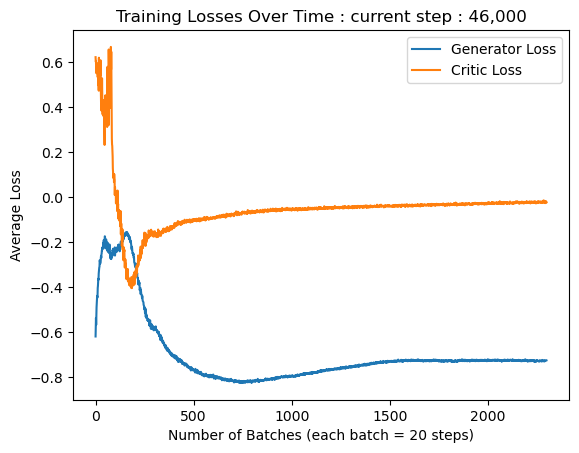

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch235.png


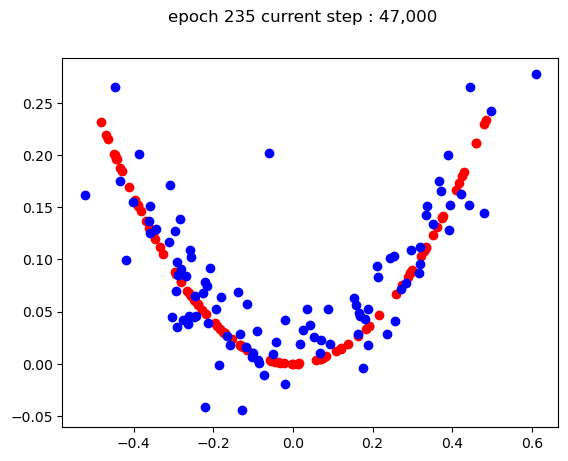


currentStep : 47,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4846,  0.5083]) y range : tensor([-0.0437,  0.2489]) max - min : tensor([0.9929, 0.2926])
Step 47,000: Generator loss: -0.727666581749916, crtic loss: -0.020440480831731132
Memory usage (RSS): 407.83203125 MB


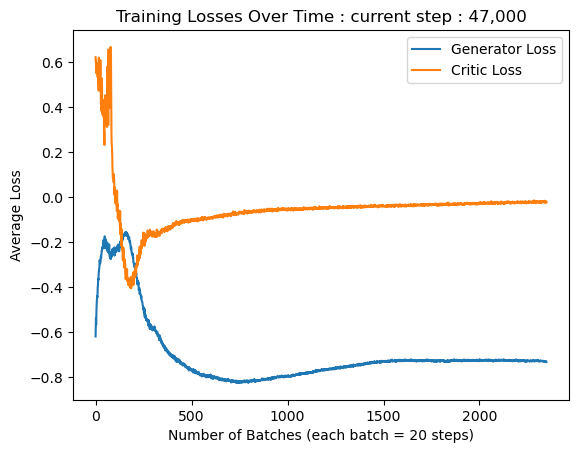

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch240.png


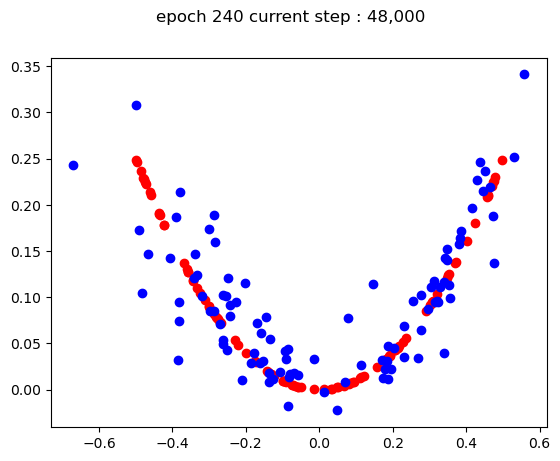


currentStep : 48,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5650,  0.8281]) y range : tensor([-0.0323,  0.3690]) max - min : tensor([1.3930, 0.4013])
Step 48,000: Generator loss: -0.7292786901593208, crtic loss: -0.020653910638578247
Memory usage (RSS): 409.79296875 MB


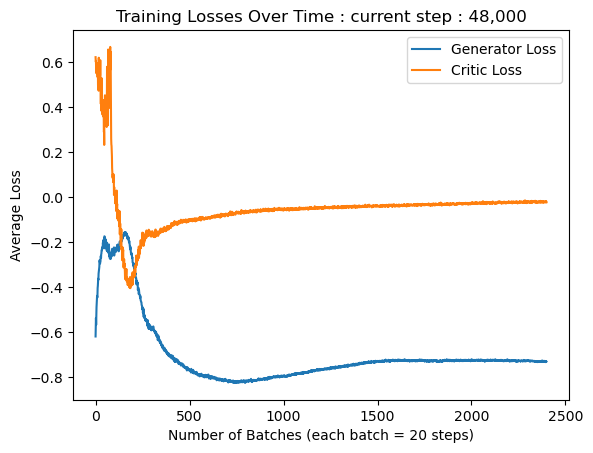

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch245.png


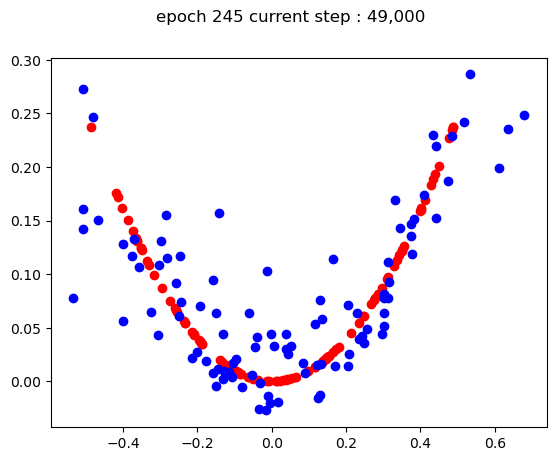


currentStep : 49,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5346,  0.6521]) y range : tensor([-0.0449,  0.3345]) max - min : tensor([1.1867, 0.3794])
Step 49,000: Generator loss: -0.7285481333136559, crtic loss: -0.01970629610316829
Memory usage (RSS): 409.8515625 MB


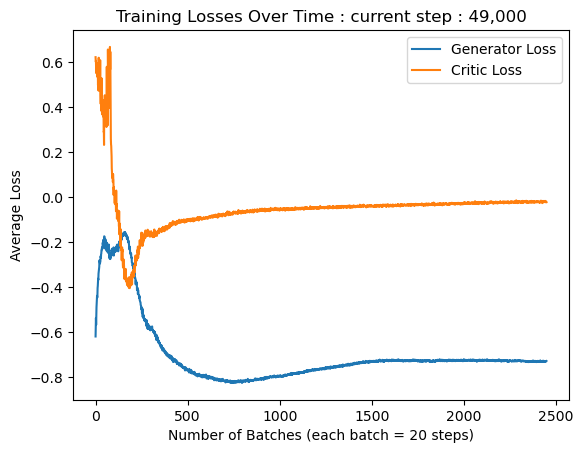

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch250.png


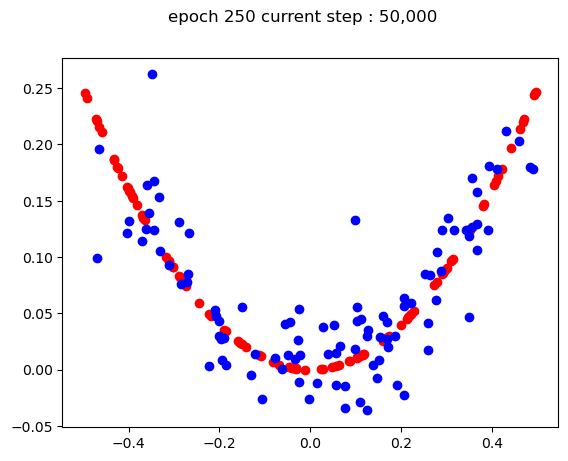


currentStep : 50,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5203,  0.6163]) y range : tensor([-0.0204,  0.3780]) max - min : tensor([1.1366, 0.3984])
Step 50,000: Generator loss: -0.7284155614972114, crtic loss: -0.01884945177184418
Memory usage (RSS): 409.86328125 MB


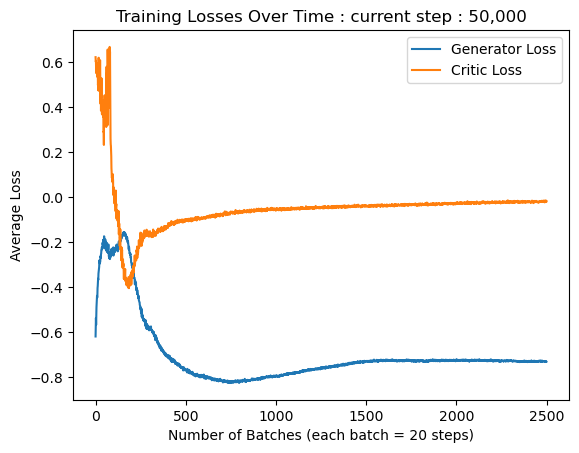

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch255.png


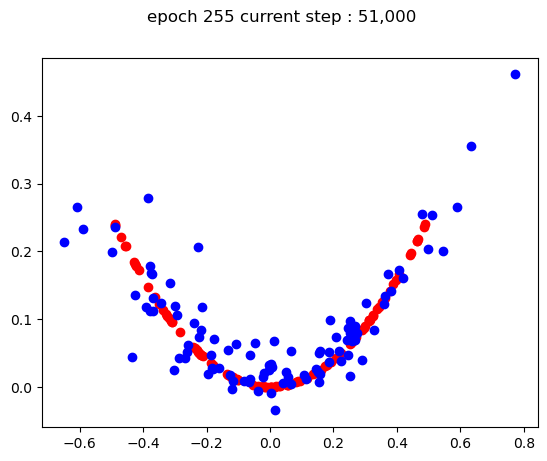


currentStep : 51,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6773,  0.5019]) y range : tensor([-0.0297,  0.3020]) max - min : tensor([1.1792, 0.3317])
Step 51,000: Generator loss: -0.7296706435084342, crtic loss: -0.018144970232713966
Memory usage (RSS): 409.875 MB


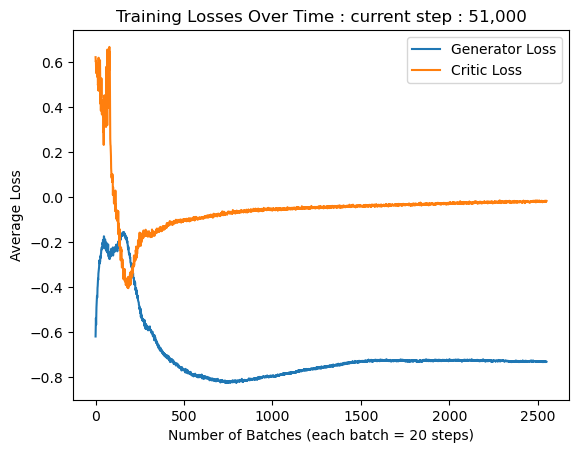

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch260.png


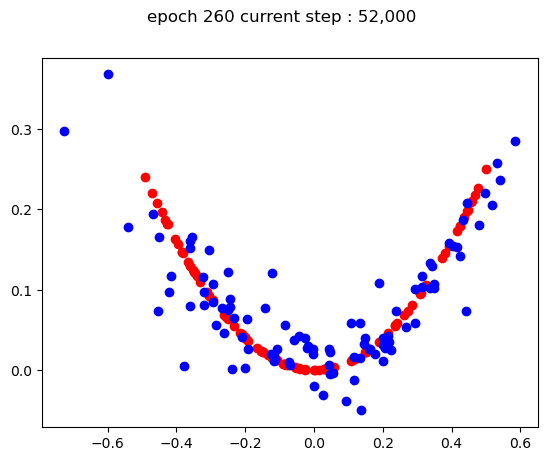


currentStep : 52,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5831,  0.4684]) y range : tensor([-0.0311,  0.2433]) max - min : tensor([1.0516, 0.2744])
Step 52,000: Generator loss: -0.7293775786161423, crtic loss: -0.01767792618786914
Memory usage (RSS): 409.875 MB


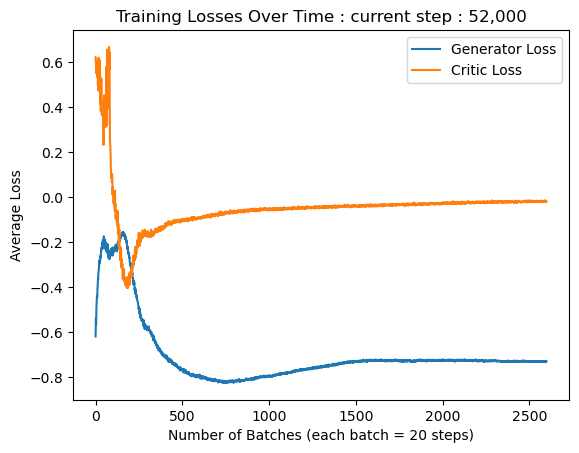

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch265.png


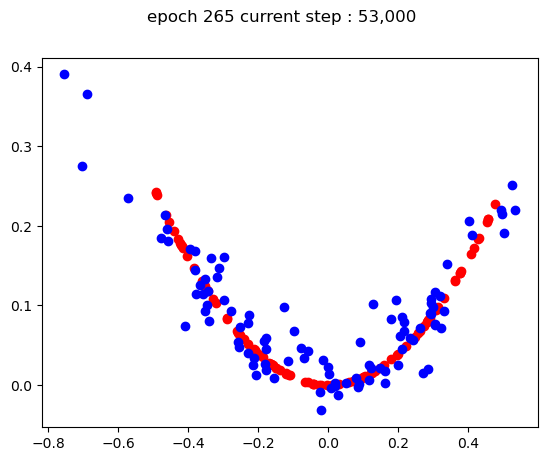


currentStep : 53,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4488,  0.5556]) y range : tensor([-0.0367,  0.2933]) max - min : tensor([1.0044, 0.3300])
Step 53,000: Generator loss: -0.7289741240143776, crtic loss: -0.016907379359845078
Memory usage (RSS): 409.88671875 MB


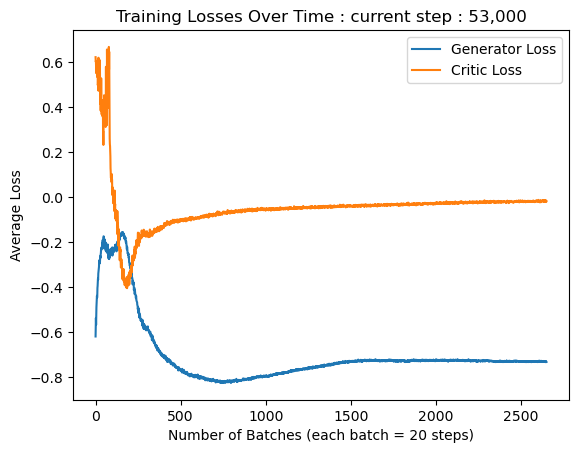

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch270.png


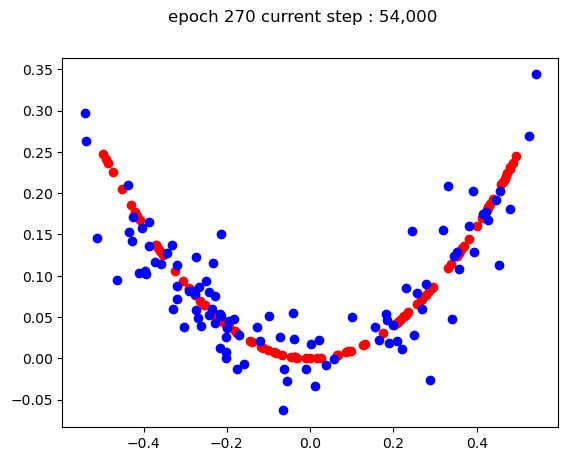


currentStep : 54,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4704,  0.6281]) y range : tensor([-0.0351,  0.3106]) max - min : tensor([1.0985, 0.3457])
Step 54,000: Generator loss: -0.7287934010624886, crtic loss: -0.01641063112644477
Memory usage (RSS): 409.890625 MB


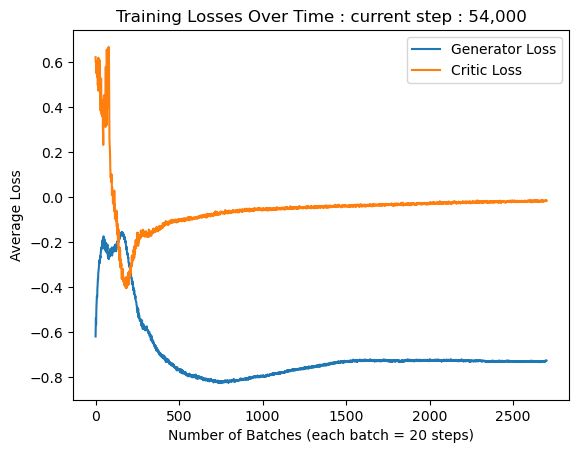

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch275.png


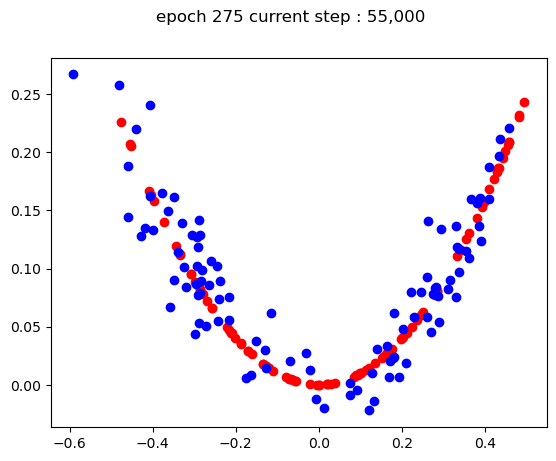


currentStep : 55,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6202,  0.6701]) y range : tensor([-0.0076,  0.4326]) max - min : tensor([1.2904, 0.4402])
Step 55,000: Generator loss: -0.7278801484704017, crtic loss: -0.015620720481174062
Memory usage (RSS): 409.90625 MB


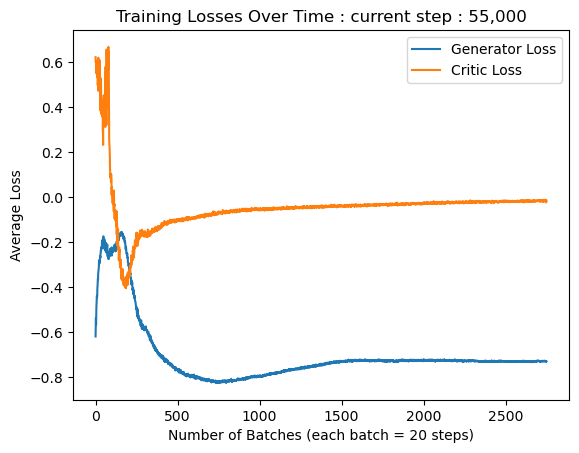

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch280.png


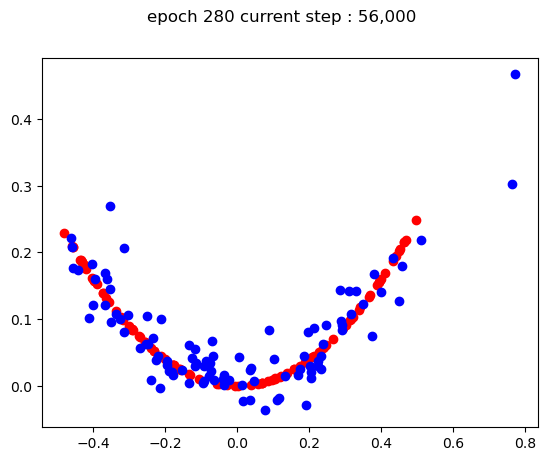


currentStep : 56,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5442,  0.6108]) y range : tensor([-0.0368,  0.3819]) max - min : tensor([1.1551, 0.4187])
Step 56,000: Generator loss: -0.7284856212139129, crtic loss: -0.014802993857720877
Memory usage (RSS): 409.98828125 MB


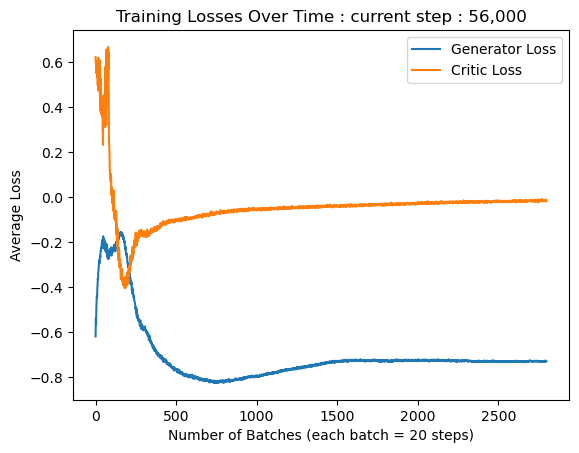

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch285.png


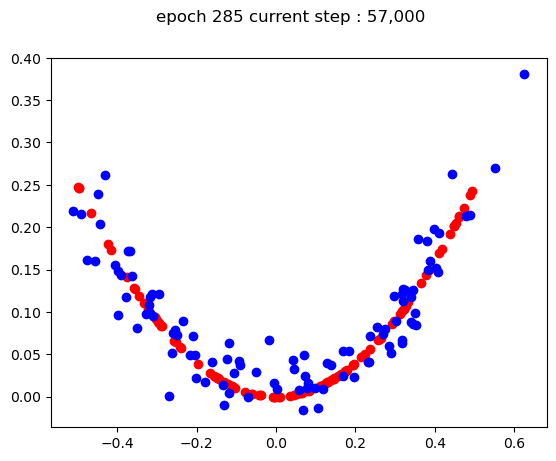


currentStep : 57,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6340,  0.5332]) y range : tensor([-0.0322,  0.3881]) max - min : tensor([1.1673, 0.4203])
Step 57,000: Generator loss: -0.728231216430664, crtic loss: -0.0147136846180074
Memory usage (RSS): 410.0 MB


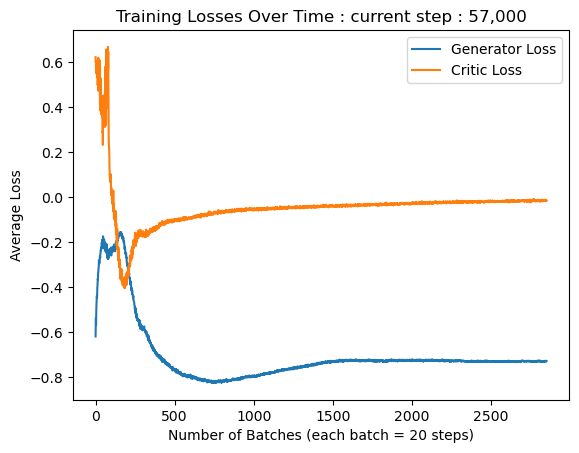

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch290.png


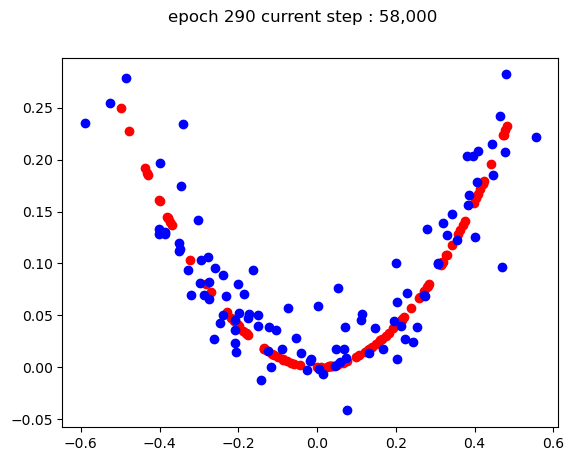


currentStep : 58,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6077,  0.6380]) y range : tensor([-0.0223,  0.3798]) max - min : tensor([1.2457, 0.4021])
Step 58,000: Generator loss: -0.7272915360927582, crtic loss: -0.014481202829303203
Memory usage (RSS): 410.0 MB


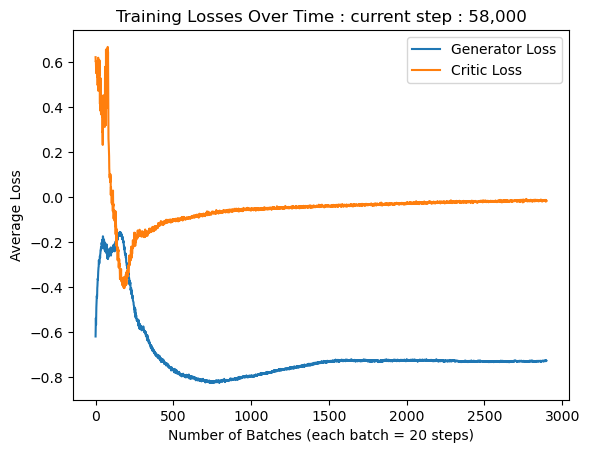

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch295.png


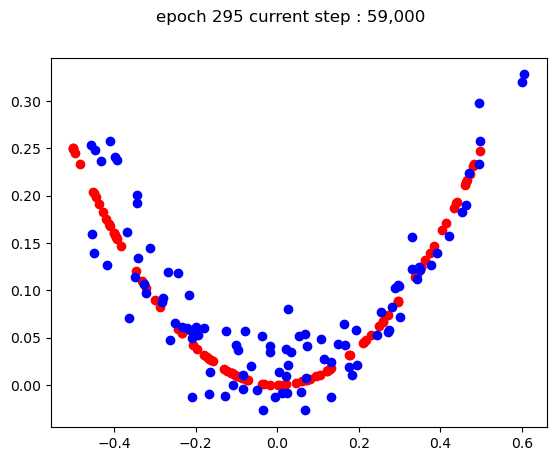


currentStep : 59,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5202,  0.5720]) y range : tensor([-0.0181,  0.3412]) max - min : tensor([1.0922, 0.3593])
Step 59,000: Generator loss: -0.7262840836048127, crtic loss: -0.014051635254826386
Memory usage (RSS): 410.01171875 MB


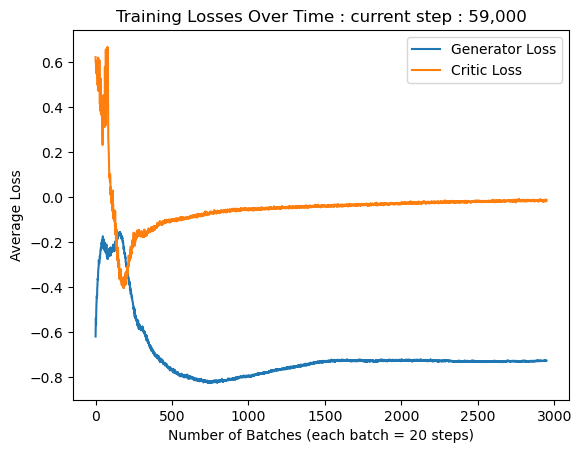

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch300.png


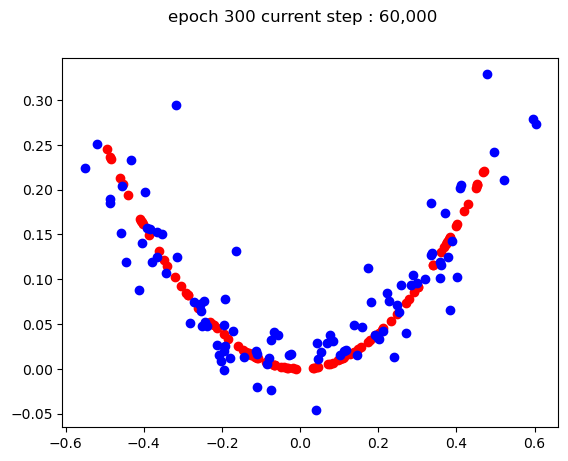


currentStep : 60,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5524,  0.5049]) y range : tensor([-0.0238,  0.2771]) max - min : tensor([1.0573, 0.3009])
Step 60,000: Generator loss: -0.7248680463433266, crtic loss: -0.013400406852457664
Memory usage (RSS): 410.0703125 MB


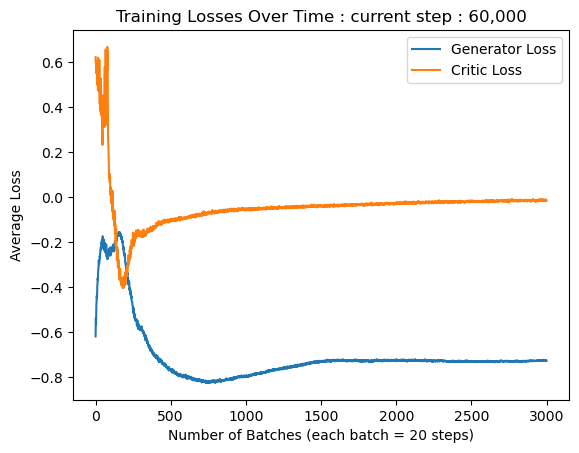

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch305.png


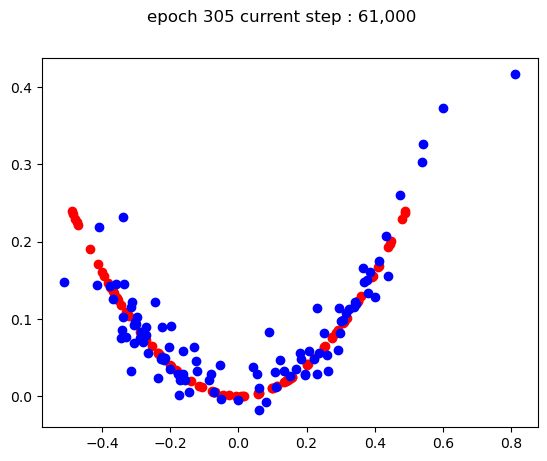


currentStep : 61,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6715,  0.5139]) y range : tensor([-0.0206,  0.2830]) max - min : tensor([1.1854, 0.3036])
Step 61,000: Generator loss: -0.7243900138735772, crtic loss: -0.013056364042498193
Memory usage (RSS): 410.10546875 MB


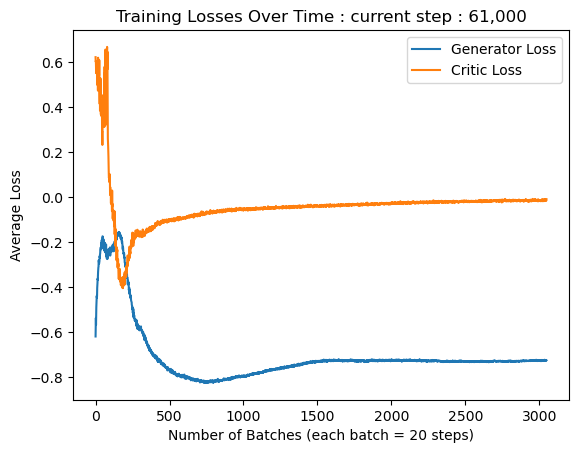

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch310.png


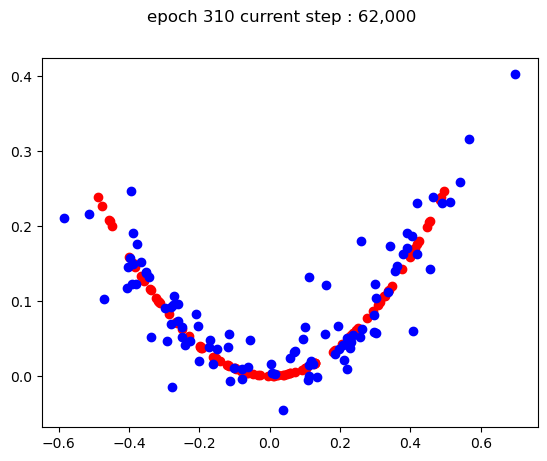


currentStep : 62,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5858,  0.4646]) y range : tensor([-0.0199,  0.2404]) max - min : tensor([1.0504, 0.2603])
Step 62,000: Generator loss: -0.7257135415673256, crtic loss: -0.012942130272462967
Memory usage (RSS): 410.2890625 MB


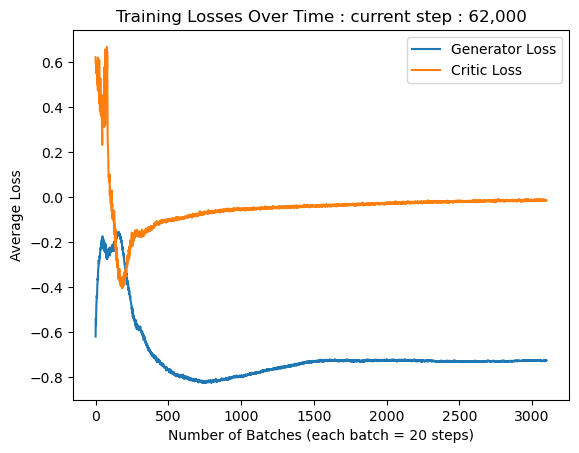

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch315.png


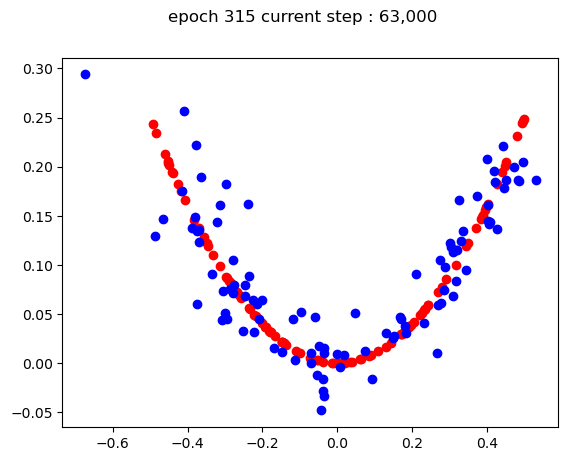


currentStep : 63,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5373,  0.5405]) y range : tensor([-0.0179,  0.2955]) max - min : tensor([1.0778, 0.3133])
Step 63,000: Generator loss: -0.7257489215135574, crtic loss: -0.01270329707283526
Memory usage (RSS): 410.3203125 MB


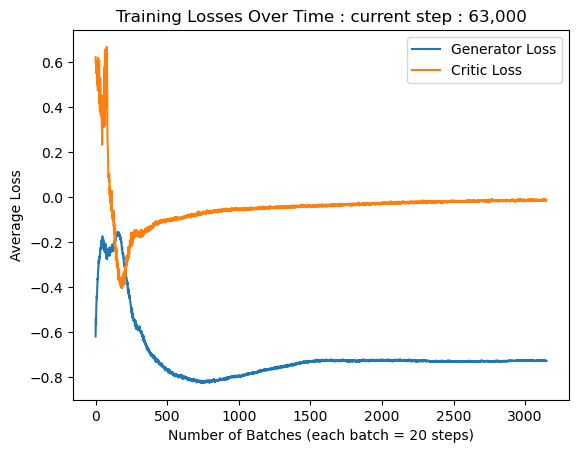

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch320.png


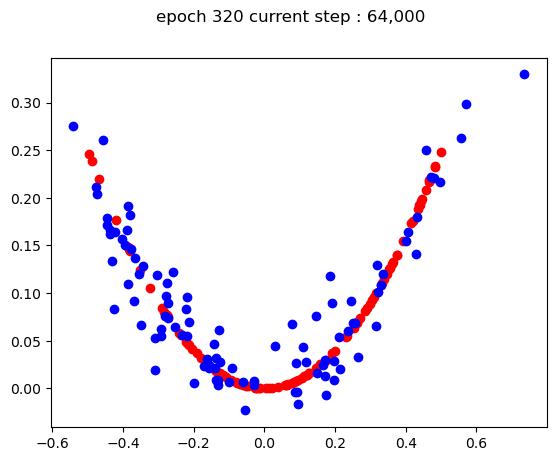


currentStep : 64,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5341,  0.5190]) y range : tensor([-0.0195,  0.2346]) max - min : tensor([1.0531, 0.2540])
Step 64,000: Generator loss: -0.7259340812563896, crtic loss: -0.012266415377892524
Memory usage (RSS): 410.34375 MB


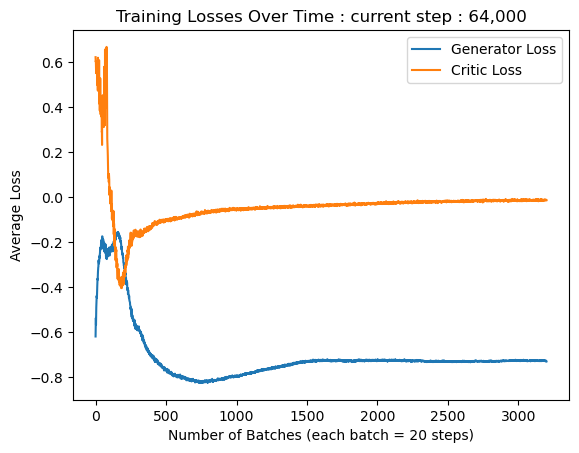

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch325.png


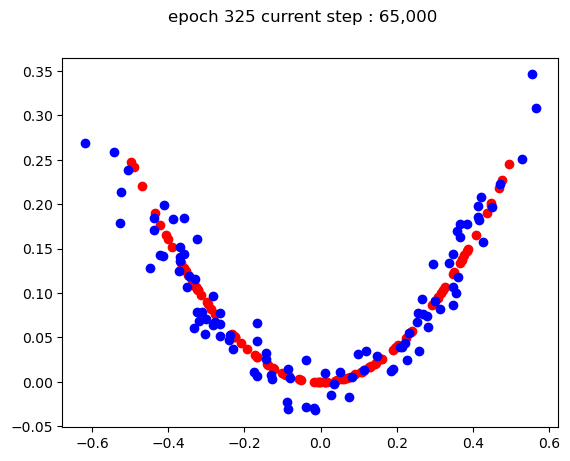


currentStep : 65,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5640,  0.5543]) y range : tensor([-0.0341,  0.3425]) max - min : tensor([1.1183, 0.3766])
Step 65,000: Generator loss: -0.726797704398632, crtic loss: -0.012301681368984303
Memory usage (RSS): 412.453125 MB


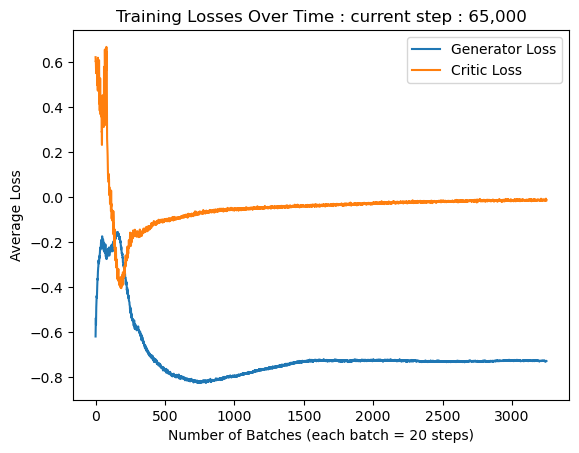

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch330.png


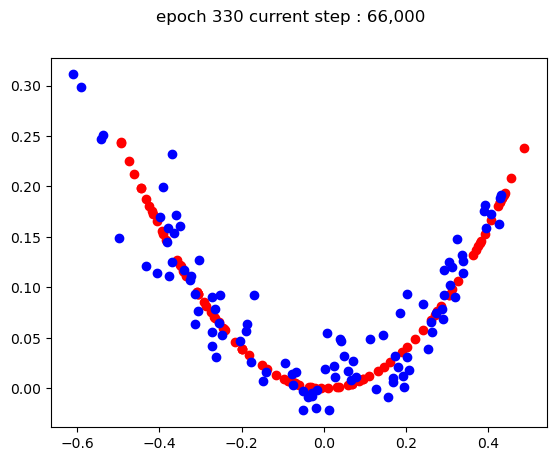


currentStep : 66,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5180,  0.5696]) y range : tensor([-0.0202,  0.3219]) max - min : tensor([1.0876, 0.3421])
Step 66,000: Generator loss: -0.7261870601177216, crtic loss: -0.011809199909027669
Memory usage (RSS): 415.0234375 MB


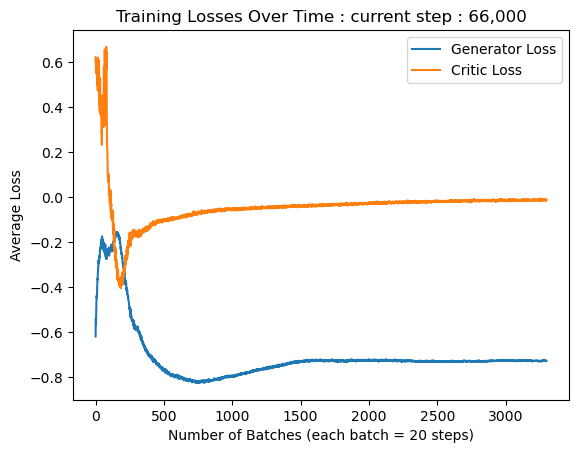

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch335.png


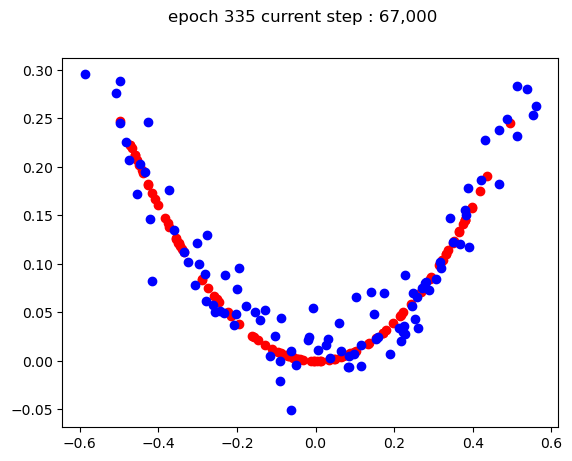


currentStep : 67,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5249,  0.7106]) y range : tensor([-0.0186,  0.4029]) max - min : tensor([1.2356, 0.4215])
Step 67,000: Generator loss: -0.7267180430293083, crtic loss: -0.011831395848654207
Memory usage (RSS): 417.546875 MB


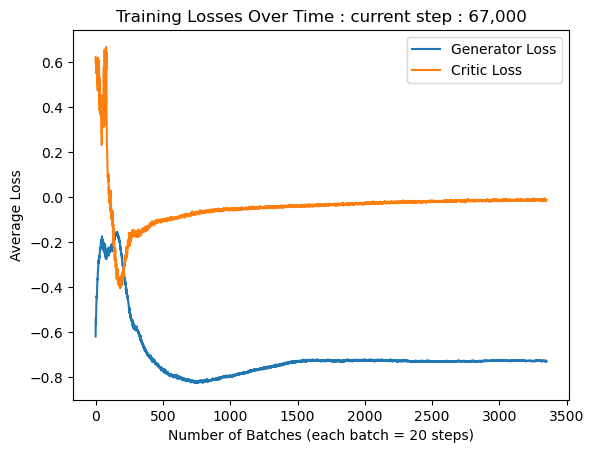

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch340.png


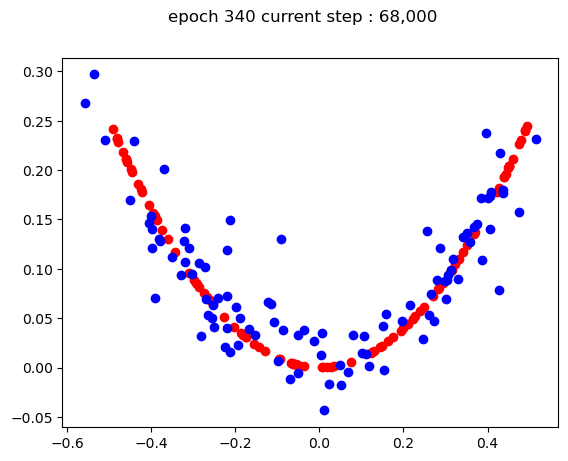


currentStep : 68,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4532,  0.5129]) y range : tensor([-0.0476,  0.2661]) max - min : tensor([0.9661, 0.3137])
Step 68,000: Generator loss: -0.7282124862074852, crtic loss: -0.012210385024640707
Memory usage (RSS): 418.58984375 MB


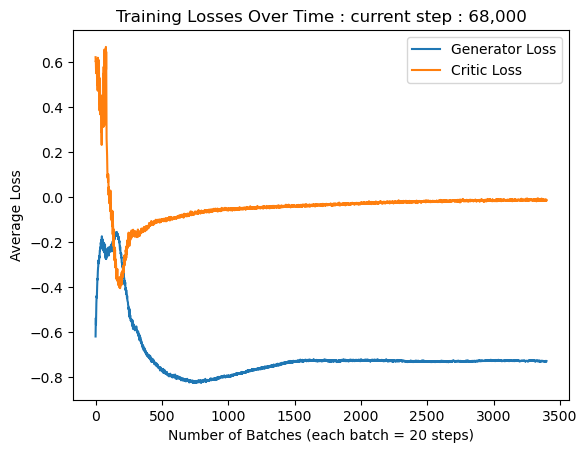

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch345.png


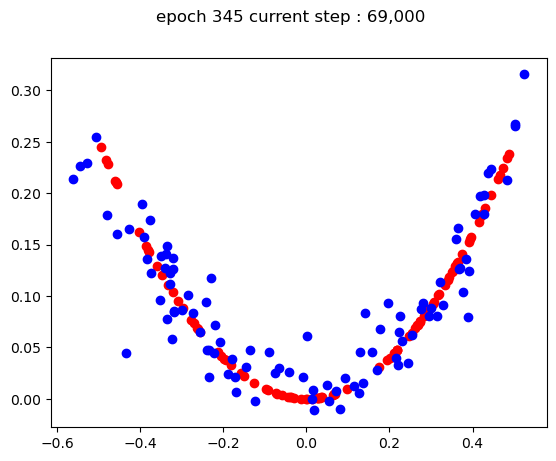


currentStep : 69,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5232,  0.5831]) y range : tensor([-0.0200,  0.3149]) max - min : tensor([1.1063, 0.3349])
Step 69,000: Generator loss: -0.7290418688654899, crtic loss: -0.012538134655542665
Memory usage (RSS): 418.6015625 MB


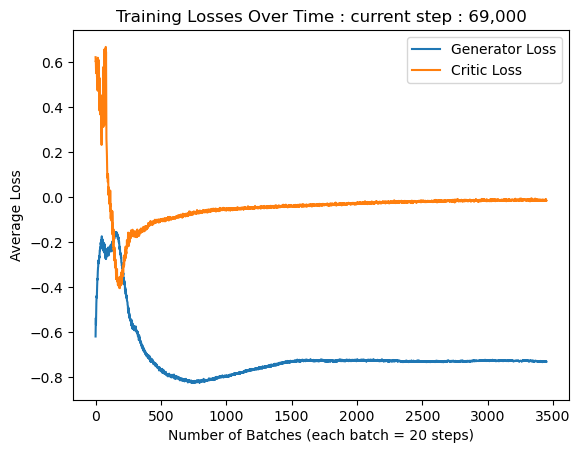

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch350.png


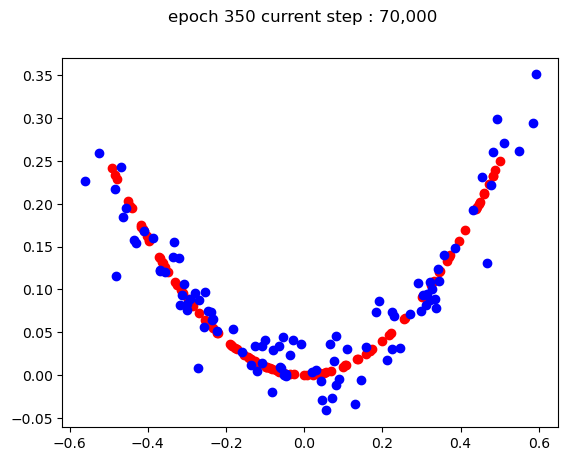


currentStep : 70,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4987,  0.6181]) y range : tensor([-0.0339,  0.3017]) max - min : tensor([1.1168, 0.3356])
Step 70,000: Generator loss: -0.7284838483333588, crtic loss: -0.011812006197031594
Memory usage (RSS): 418.60546875 MB


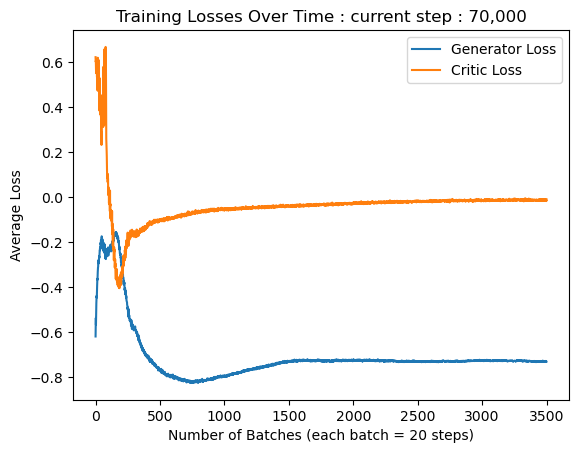

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch355.png


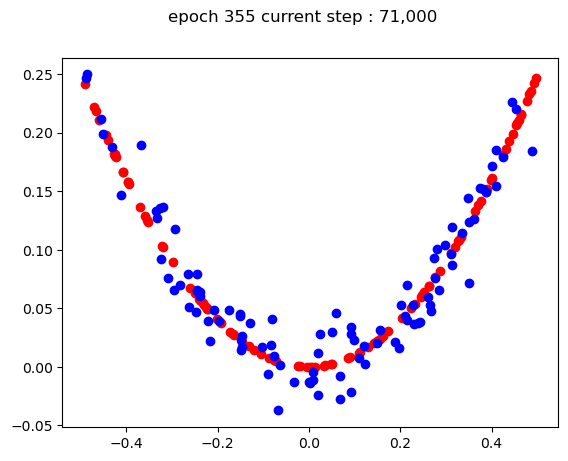


currentStep : 71,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5559,  0.5145]) y range : tensor([-0.0874,  0.2930]) max - min : tensor([1.0704, 0.3804])
Step 71,000: Generator loss: -0.7298788331747055, crtic loss: -0.01157112295776605
Memory usage (RSS): 418.62109375 MB


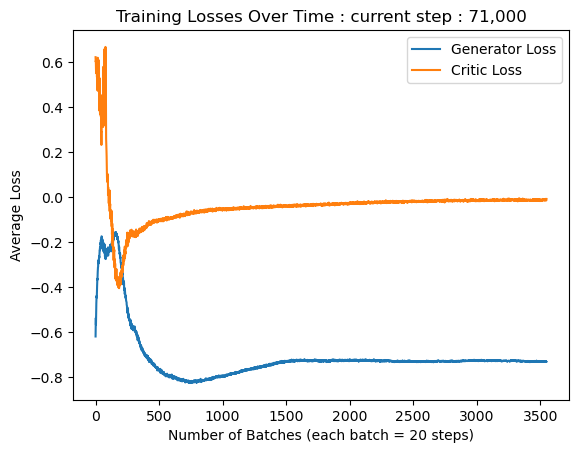

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch360.png


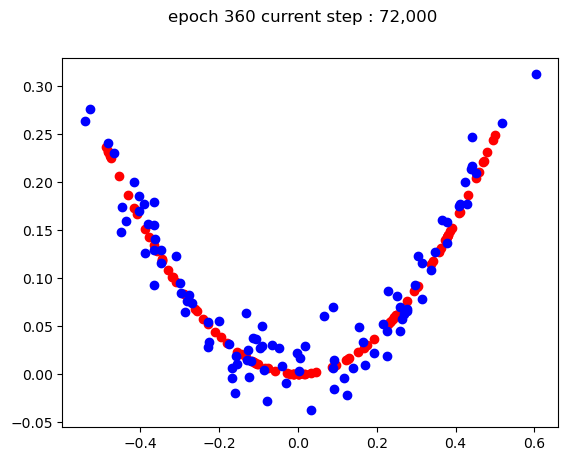


currentStep : 72,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5605,  0.5120]) y range : tensor([-0.0397,  0.2821]) max - min : tensor([1.0725, 0.3218])
Step 72,000: Generator loss: -0.7305568509697914, crtic loss: -0.011974116617348042
Memory usage (RSS): 418.62109375 MB


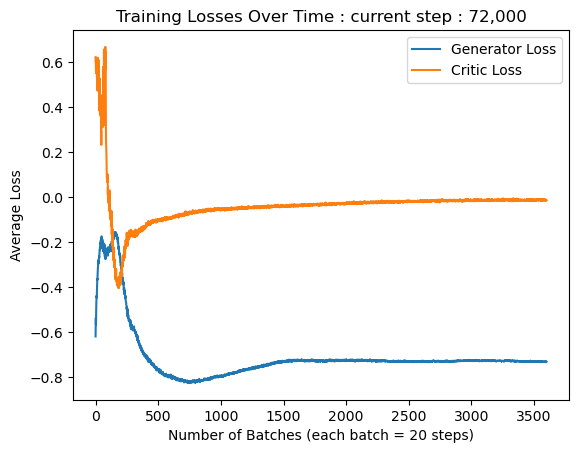

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch365.png


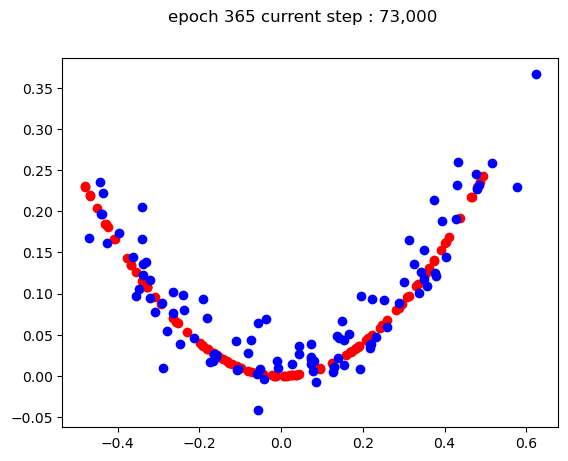


currentStep : 73,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5141,  0.5760]) y range : tensor([-0.0305,  0.2861]) max - min : tensor([1.0901, 0.3166])
Step 73,000: Generator loss: -0.7304643810391426, crtic loss: -0.011822222897782921
Memory usage (RSS): 418.62109375 MB


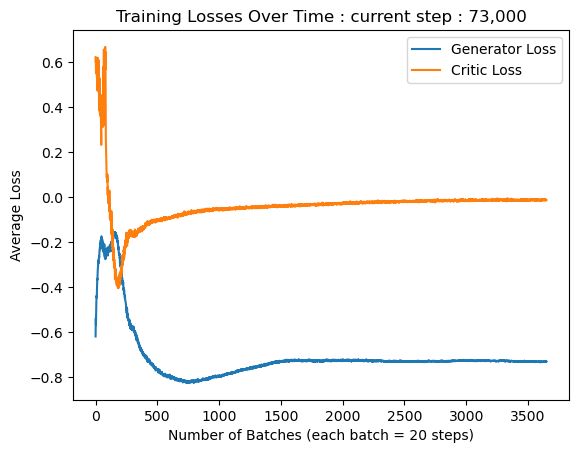

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch370.png


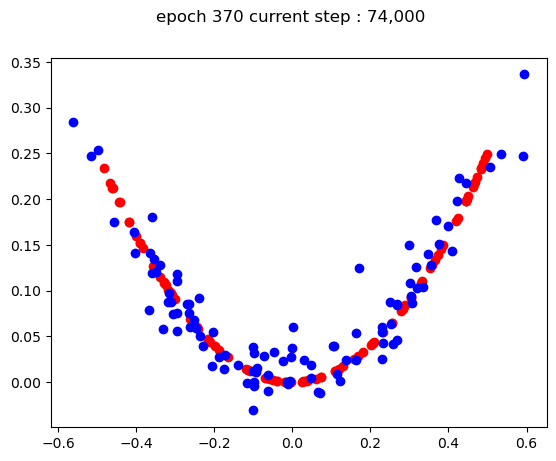


currentStep : 74,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5802,  0.7481]) y range : tensor([-0.0269,  0.4283]) max - min : tensor([1.3283, 0.4552])
Step 74,000: Generator loss: -0.7297968703508377, crtic loss: -0.011380369118787344
Memory usage (RSS): 418.62109375 MB


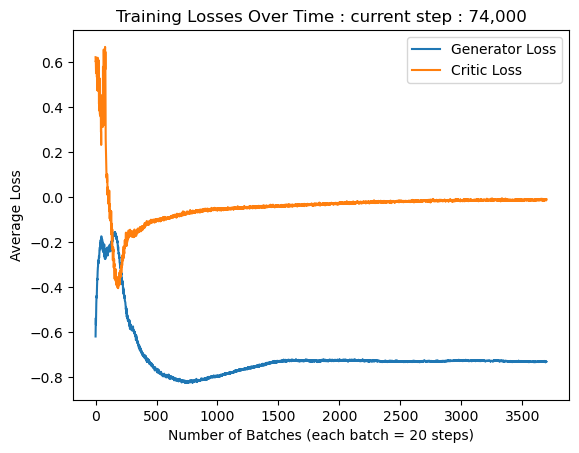

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch375.png


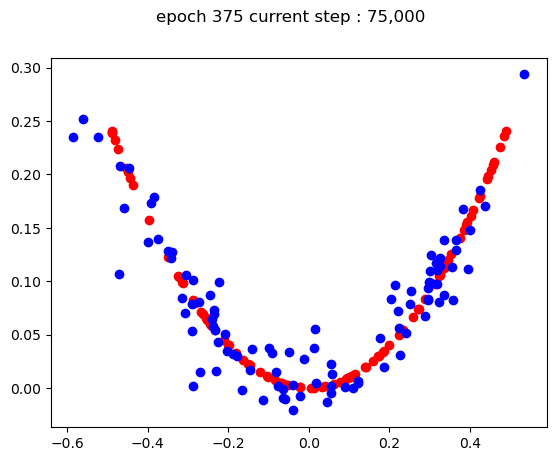


currentStep : 75,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5387,  0.5843]) y range : tensor([-0.0226,  0.2770]) max - min : tensor([1.1230, 0.2996])
Step 75,000: Generator loss: -0.7319930084347724, crtic loss: -0.01230875192480162
Memory usage (RSS): 418.6328125 MB


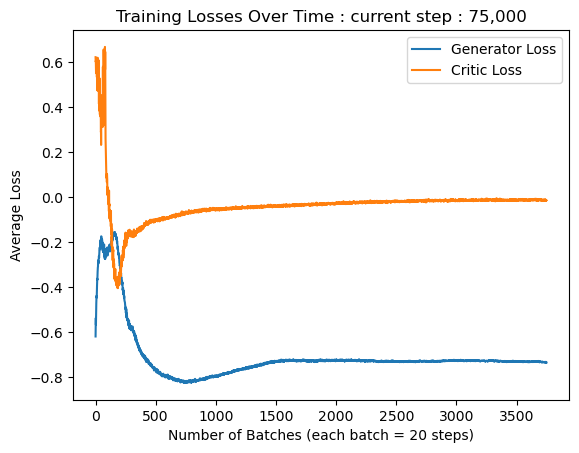

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch380.png


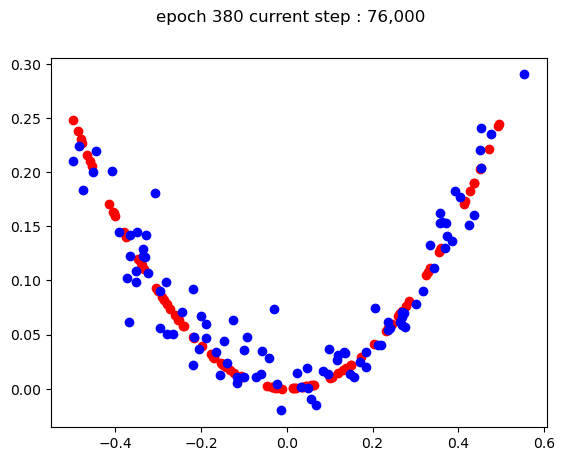


currentStep : 76,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5388,  0.4747]) y range : tensor([-0.0480,  0.2829]) max - min : tensor([1.0135, 0.3309])
Step 76,000: Generator loss: -0.7318642087578774, crtic loss: -0.0123502329404466
Memory usage (RSS): 418.6328125 MB


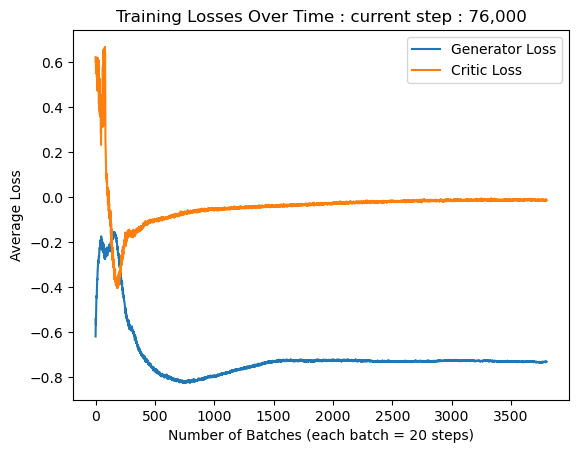

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch385.png


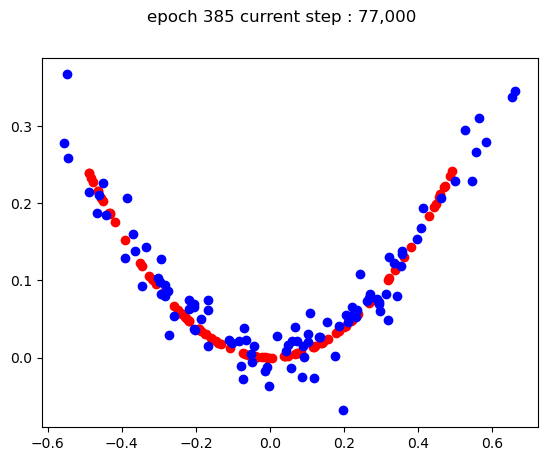


currentStep : 77,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4339,  0.5312]) y range : tensor([-0.0256,  0.2228]) max - min : tensor([0.9651, 0.2484])
Step 77,000: Generator loss: -0.7326194021701813, crtic loss: -0.012629351257951924
Memory usage (RSS): 418.6328125 MB


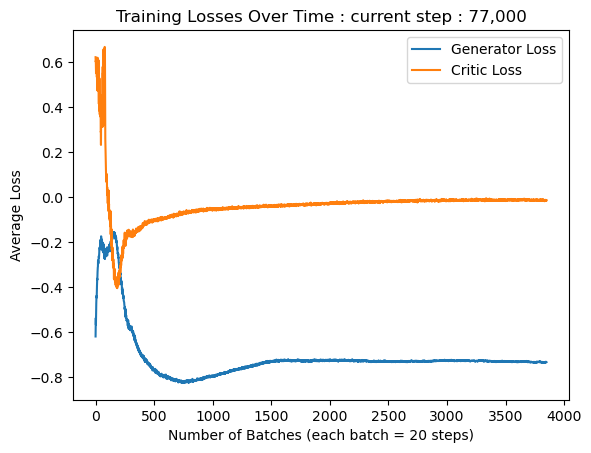

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch390.png


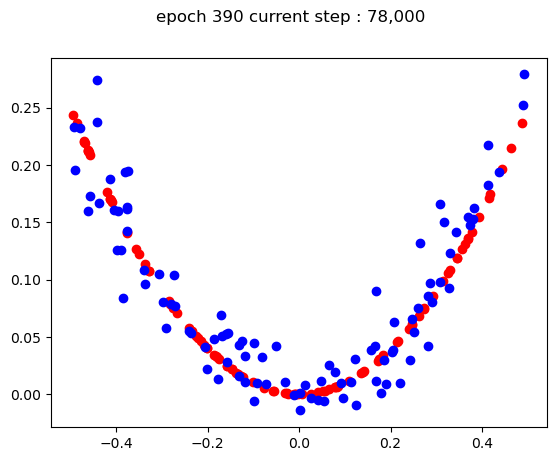


currentStep : 78,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4710,  0.7638]) y range : tensor([-0.0094,  0.4134]) max - min : tensor([1.2349, 0.4228])
Step 78,000: Generator loss: -0.7320144288539886, crtic loss: -0.012173961952421805
Memory usage (RSS): 418.640625 MB


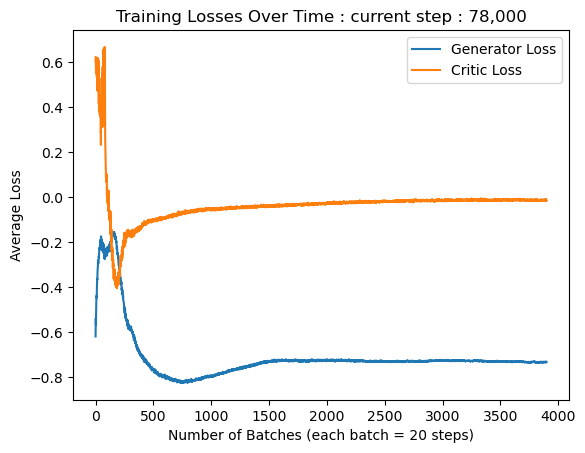

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch395.png


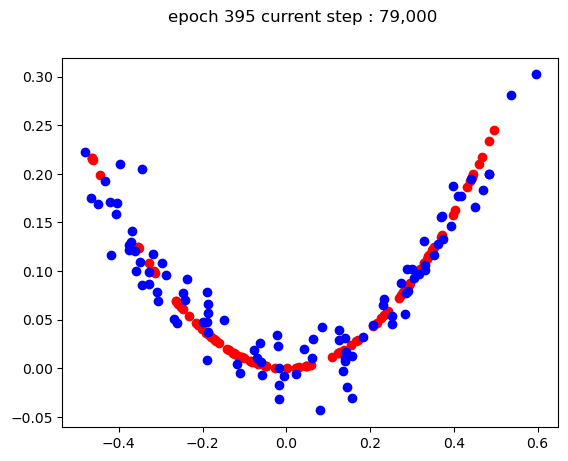


currentStep : 79,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4996,  0.5754]) y range : tensor([-0.0196,  0.3061]) max - min : tensor([1.0750, 0.3257])
Step 79,000: Generator loss: -0.7331954276561737, crtic loss: -0.012724655401799807
Memory usage (RSS): 418.640625 MB


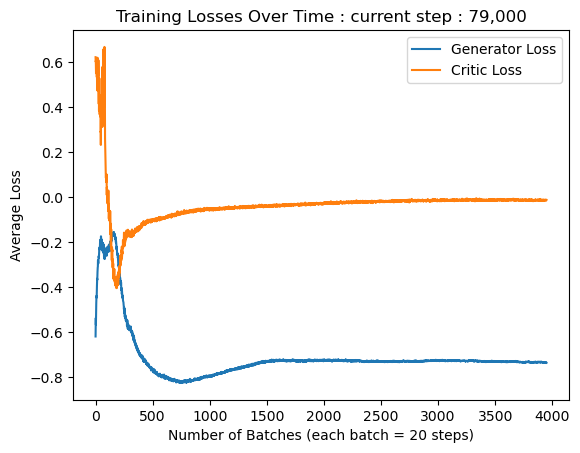

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch400.png


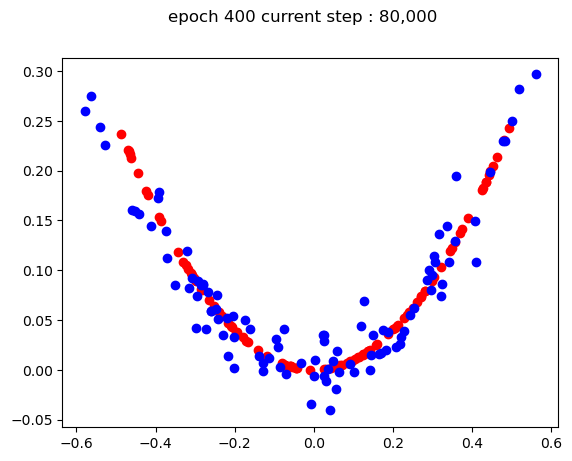


currentStep : 80,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5446,  0.4831]) y range : tensor([-0.0151,  0.3065]) max - min : tensor([1.0277, 0.3216])
Step 80,000: Generator loss: -0.7353980464339256, crtic loss: -0.01227154836012052
Memory usage (RSS): 418.640625 MB


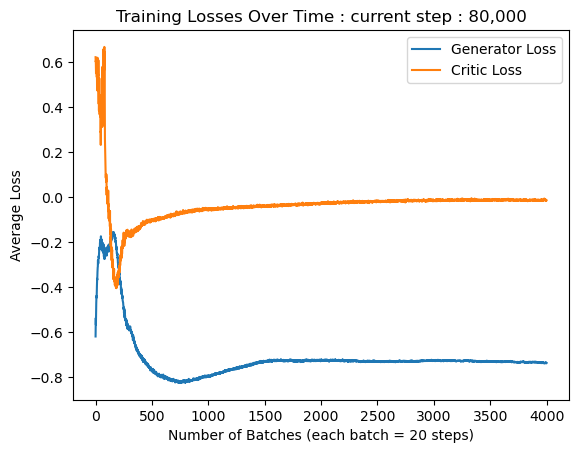

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch405.png


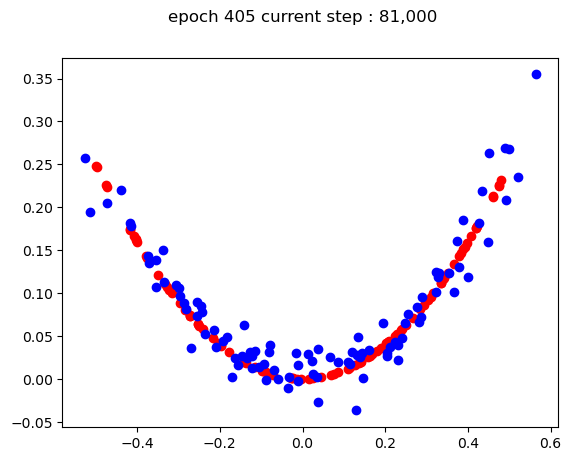


currentStep : 81,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4394,  0.5336]) y range : tensor([-0.0091,  0.2506]) max - min : tensor([0.9730, 0.2597])
Step 81,000: Generator loss: -0.7372236065268517, crtic loss: -0.011818266290752215
Memory usage (RSS): 418.640625 MB


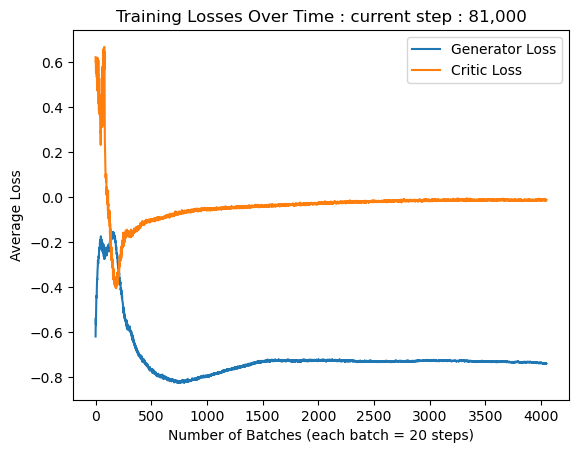

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch410.png


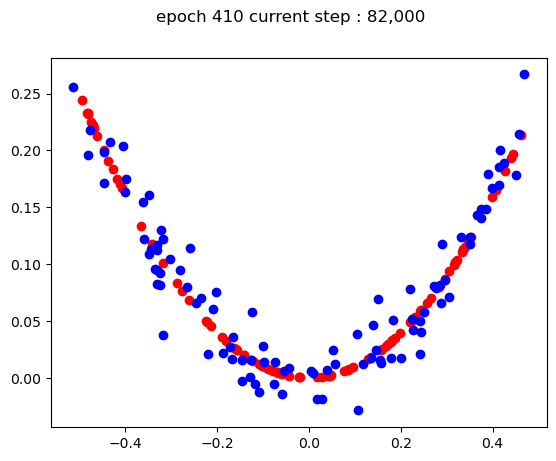


currentStep : 82,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5901,  0.5079]) y range : tensor([-0.0264,  0.2616]) max - min : tensor([1.0981, 0.2880])
Step 82,000: Generator loss: -0.7404583653211594, crtic loss: -0.012032789780944568
Memory usage (RSS): 418.640625 MB


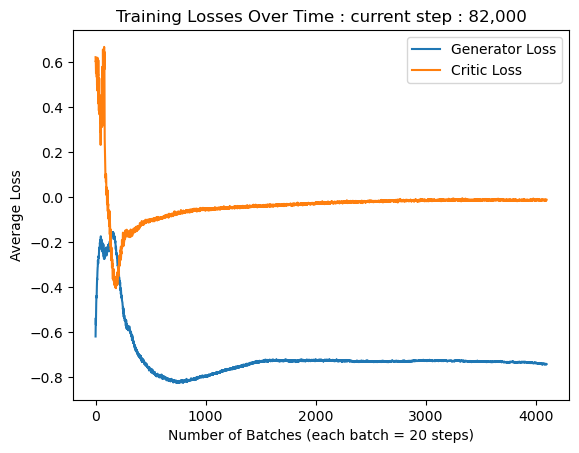

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch415.png


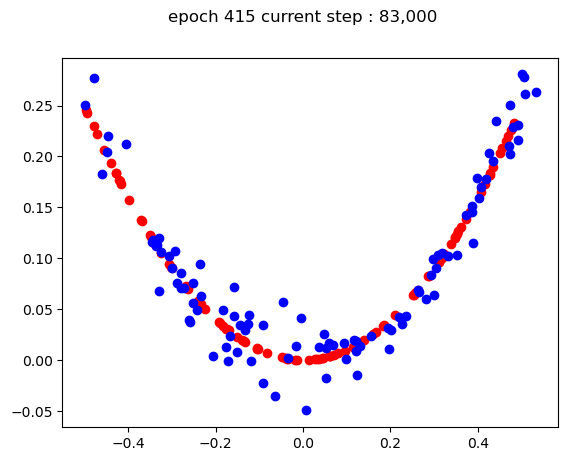


currentStep : 83,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5166,  0.5869]) y range : tensor([-0.0567,  0.3545]) max - min : tensor([1.1035, 0.4112])
Step 83,000: Generator loss: -0.7405067359805108, crtic loss: -0.012141621589008715
Memory usage (RSS): 418.6484375 MB


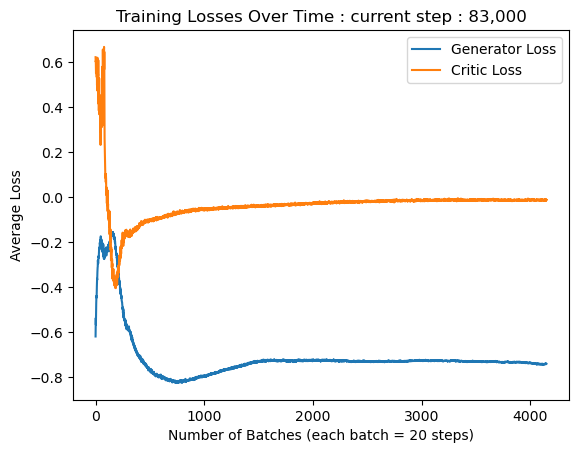

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch420.png


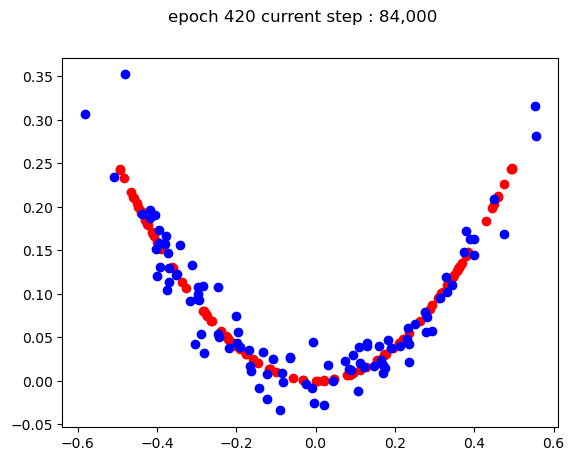


currentStep : 84,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5060,  0.4666]) y range : tensor([-0.0476,  0.2422]) max - min : tensor([0.9725, 0.2898])
Step 84,000: Generator loss: -0.7403808798193932, crtic loss: -0.012203090863814567
Memory usage (RSS): 418.859375 MB


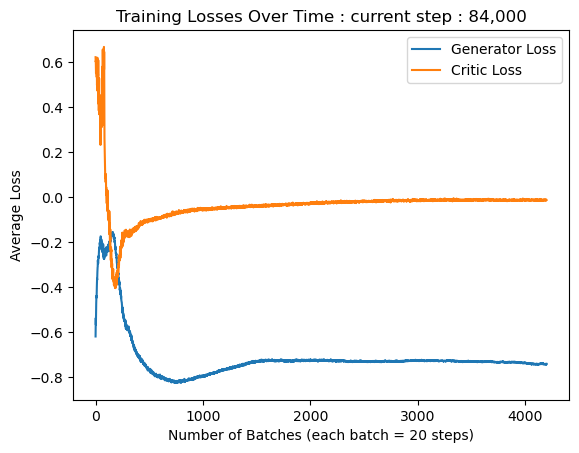

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch425.png


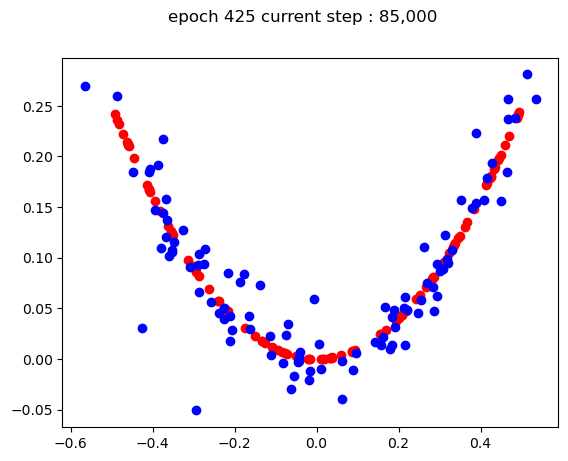


currentStep : 85,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4846,  0.5076]) y range : tensor([-0.0117,  0.2703]) max - min : tensor([0.9922, 0.2820])
Step 85,000: Generator loss: -0.7436665812134743, crtic loss: -0.012345305951172492
Memory usage (RSS): 419.0703125 MB


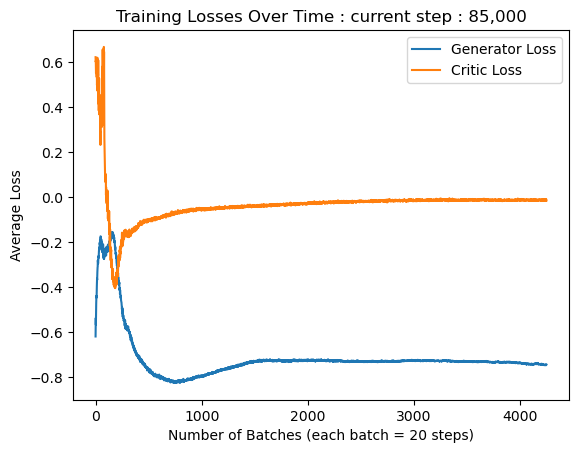

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch430.png


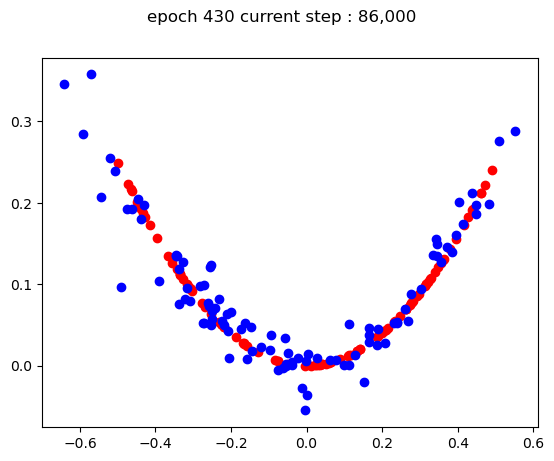


currentStep : 86,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5150,  0.6531]) y range : tensor([-0.0417,  0.3585]) max - min : tensor([1.1680, 0.4003])
Step 86,000: Generator loss: -0.7441829979419708, crtic loss: -0.012544419878022751
Memory usage (RSS): 419.28515625 MB


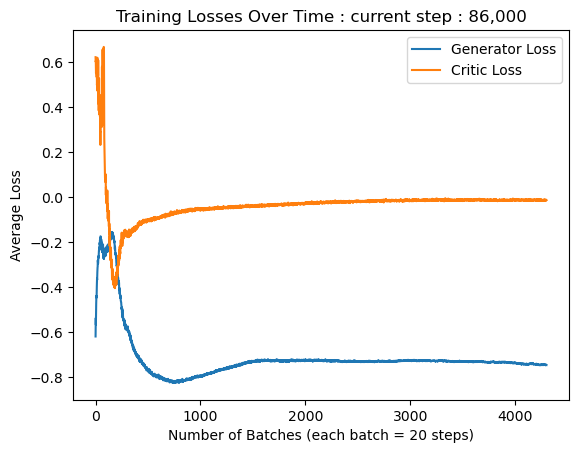

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch435.png


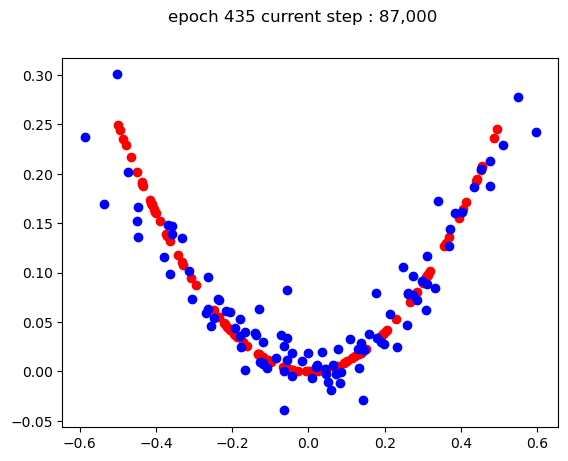


currentStep : 87,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6056,  0.5064]) y range : tensor([-0.0669,  0.2870]) max - min : tensor([1.1120, 0.3539])
Step 87,000: Generator loss: -0.7452091481089592, crtic loss: -0.012282966728694738
Memory usage (RSS): 419.98046875 MB


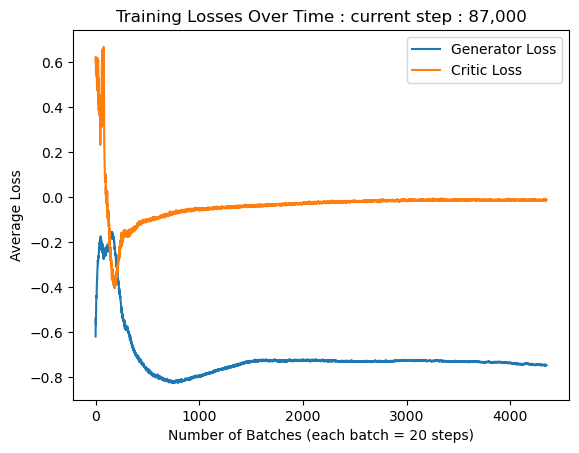

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch440.png


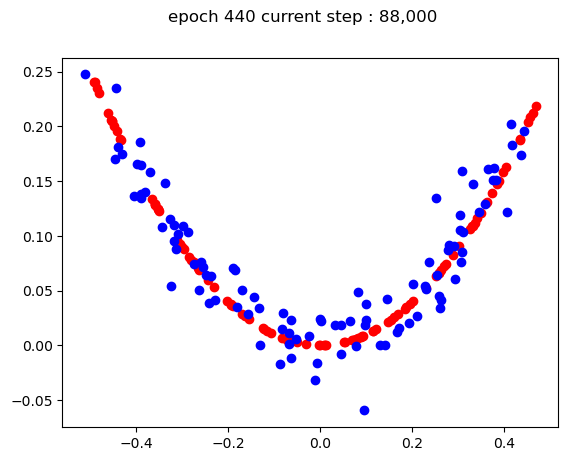


currentStep : 88,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4547,  0.4799]) y range : tensor([-0.0382,  0.2296]) max - min : tensor([0.9346, 0.2678])
Step 88,000: Generator loss: -0.7454422462582588, crtic loss: -0.012075426251976757
Memory usage (RSS): 422.734375 MB


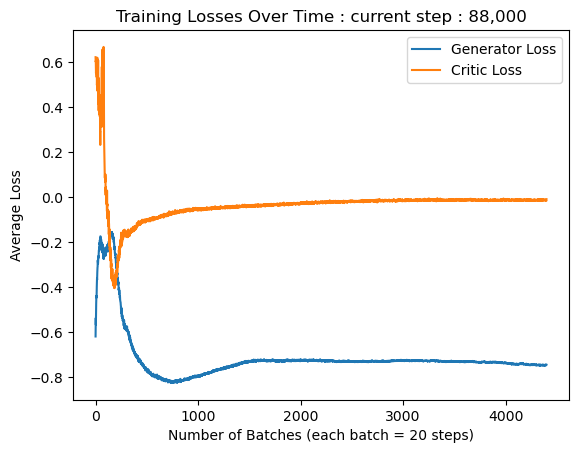

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch445.png


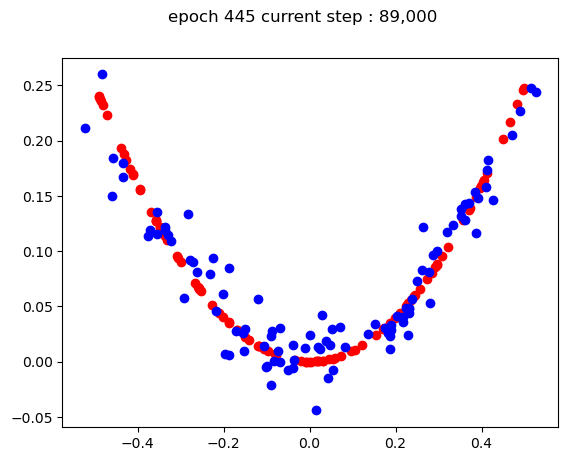


currentStep : 89,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6830,  0.5774]) y range : tensor([-0.0180,  0.3513]) max - min : tensor([1.2605, 0.3692])
Step 89,000: Generator loss: -0.7487279060482979, crtic loss: -0.012130505309626458
Memory usage (RSS): 426.81640625 MB


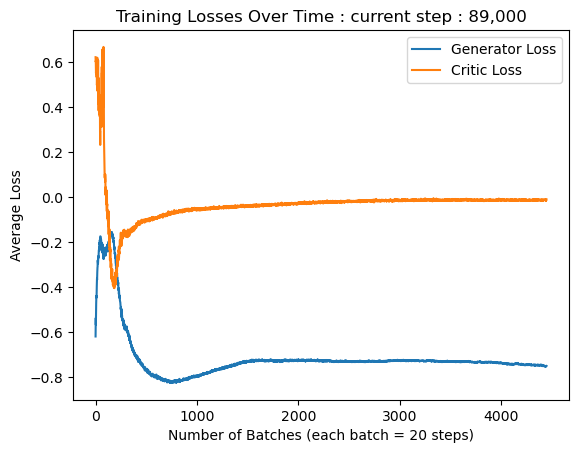

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch450.png


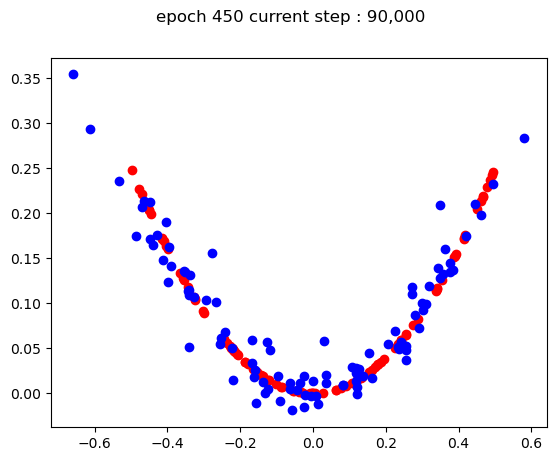


currentStep : 90,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5320,  0.5358]) y range : tensor([-0.0310,  0.2738]) max - min : tensor([1.0678, 0.3048])
Step 90,000: Generator loss: -0.7506546335220337, crtic loss: -0.012148629261809419
Memory usage (RSS): 427.4609375 MB


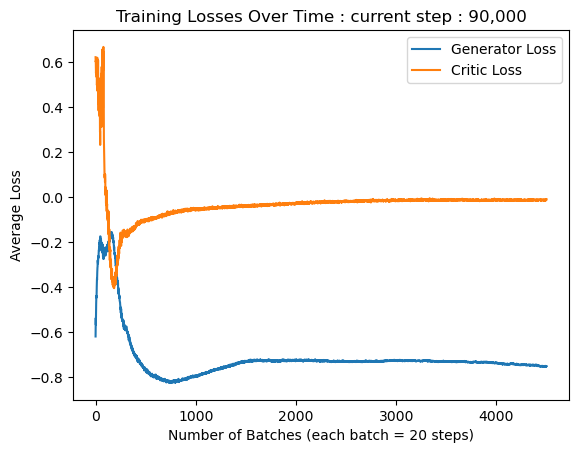

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch455.png


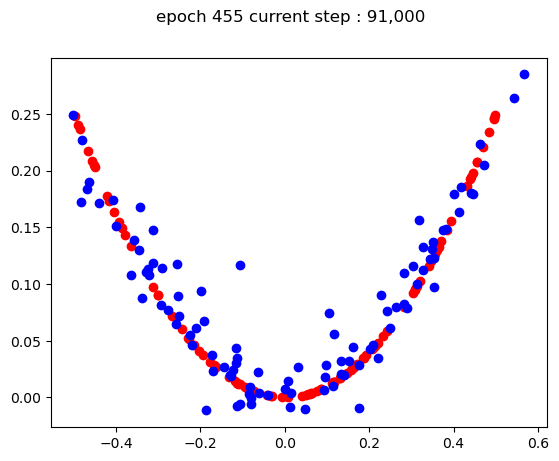


currentStep : 91,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5528,  0.5625]) y range : tensor([-0.0110,  0.2954]) max - min : tensor([1.1153, 0.3065])
Step 91,000: Generator loss: -0.7518652064800262, crtic loss: -0.0120984337980859
Memory usage (RSS): 427.4609375 MB


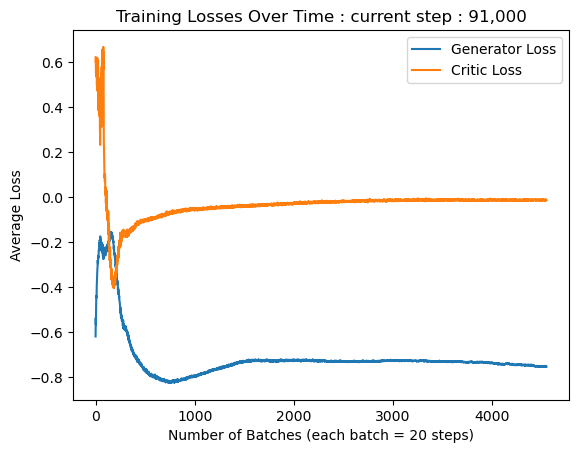

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch460.png


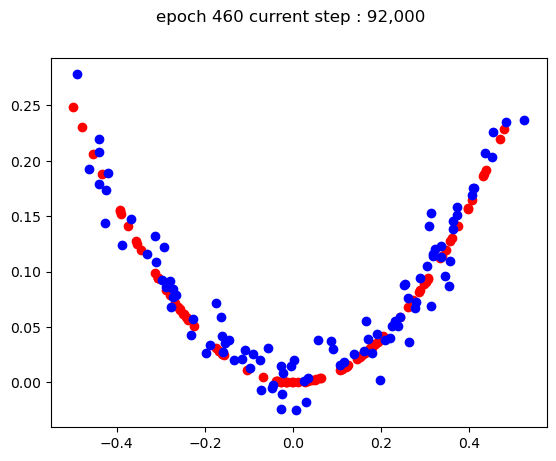


currentStep : 92,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4908,  0.5440]) y range : tensor([-0.0237,  0.3261]) max - min : tensor([1.0348, 0.3498])
Step 92,000: Generator loss: -0.7526854508519173, crtic loss: -0.011903828735119894
Memory usage (RSS): 427.4609375 MB


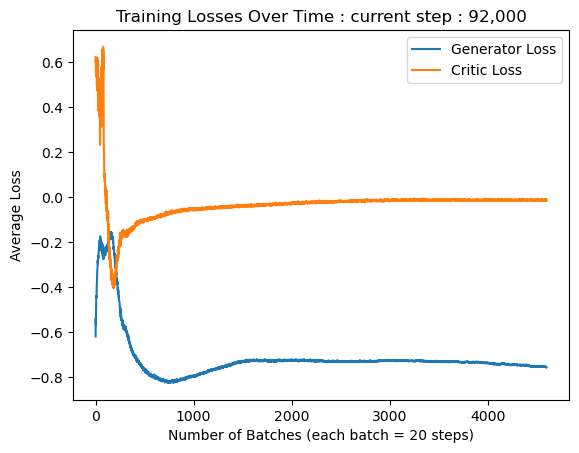

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch465.png


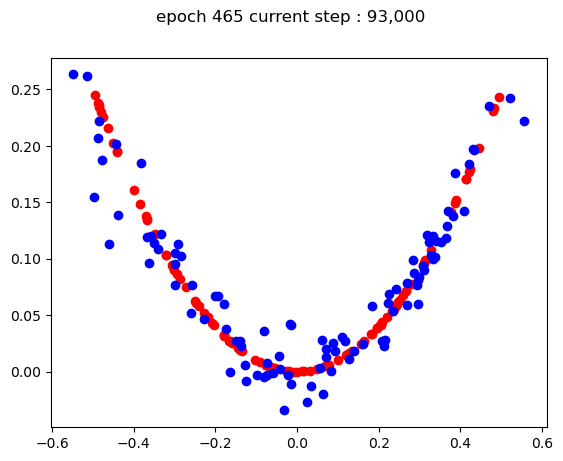


currentStep : 93,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5332,  0.5968]) y range : tensor([-0.0194,  0.2984]) max - min : tensor([1.1300, 0.3178])
Step 93,000: Generator loss: -0.7541856950521469, crtic loss: -0.011537024987593767
Memory usage (RSS): 427.46484375 MB


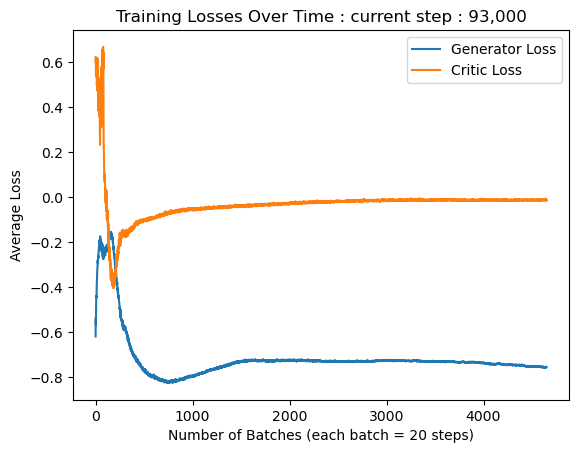

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch470.png


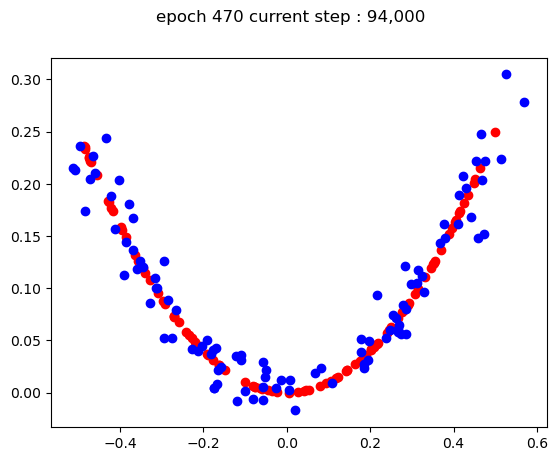


currentStep : 94,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5202,  0.4942]) y range : tensor([-0.0153,  0.2366]) max - min : tensor([1.0144, 0.2520])
Step 94,000: Generator loss: -0.7549807758331298, crtic loss: -0.011649130441265889
Memory usage (RSS): 427.46484375 MB


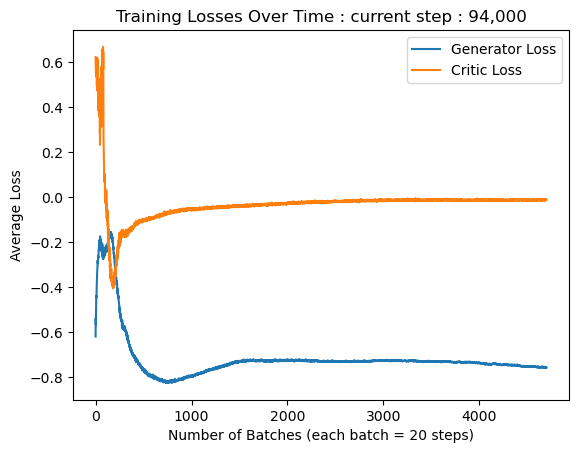

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch475.png


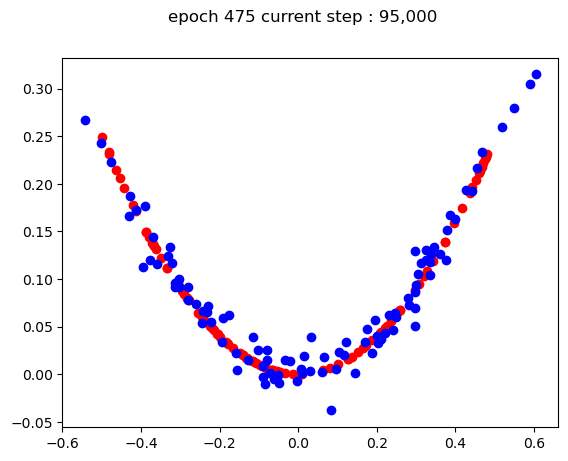


currentStep : 95,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5557,  0.5408]) y range : tensor([-0.0292,  0.2755]) max - min : tensor([1.0965, 0.3046])
Step 95,000: Generator loss: -0.7574672993421555, crtic loss: -0.011150757509446706
Memory usage (RSS): 427.46484375 MB


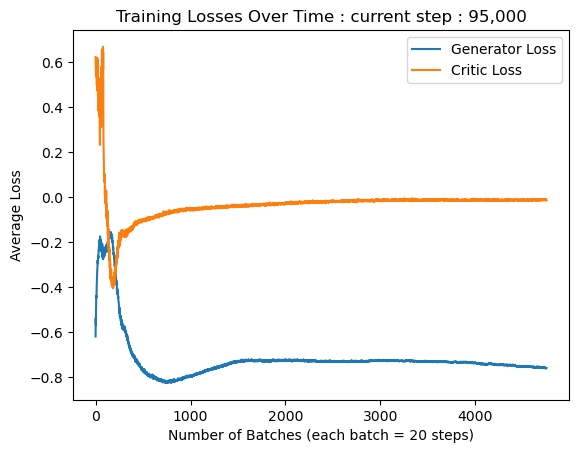

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch480.png


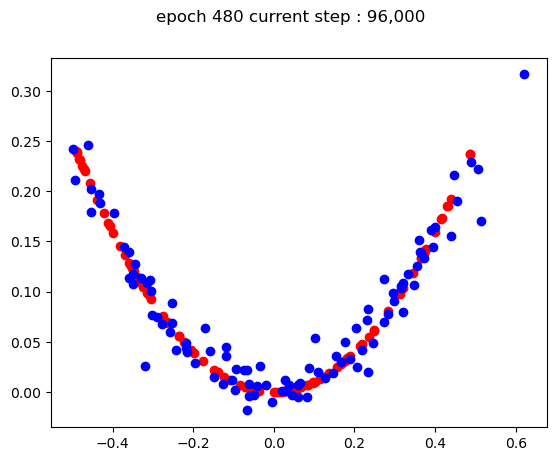


currentStep : 96,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5536,  0.6170]) y range : tensor([-0.0371,  0.3209]) max - min : tensor([1.1706, 0.3580])
Step 96,000: Generator loss: -0.7590092121362686, crtic loss: -0.01093992269541049
Memory usage (RSS): 427.46875 MB


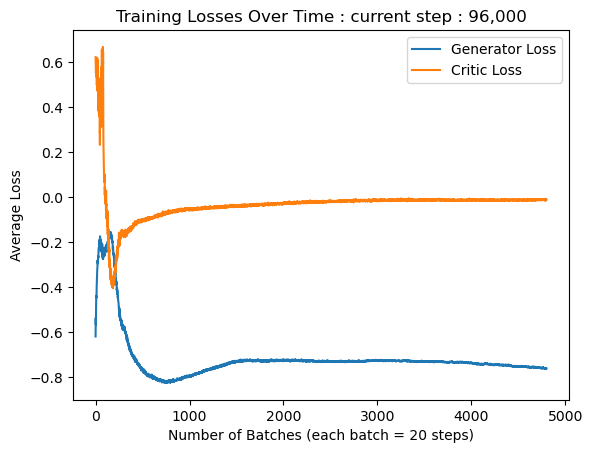

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch485.png


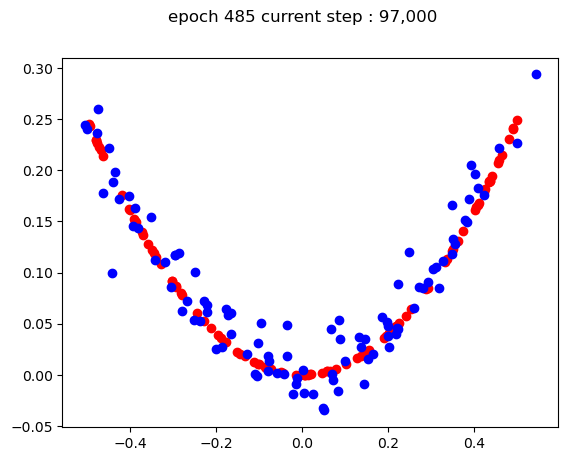


currentStep : 97,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.5204,  0.5321]) y range : tensor([-0.0463,  0.2836]) max - min : tensor([1.0525, 0.3299])
Step 97,000: Generator loss: -0.7621897667646408, crtic loss: -0.011000222239189318
Memory usage (RSS): 427.47265625 MB


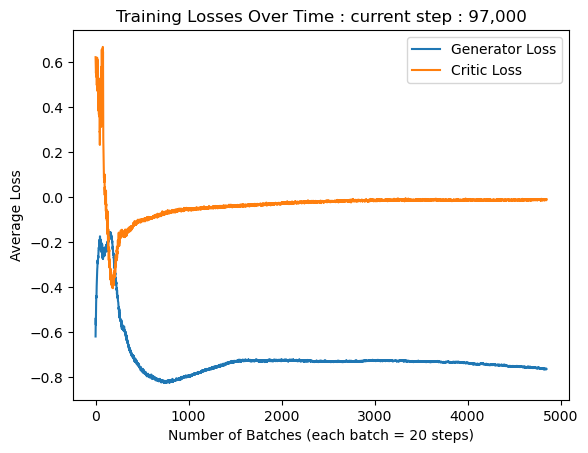

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch490.png


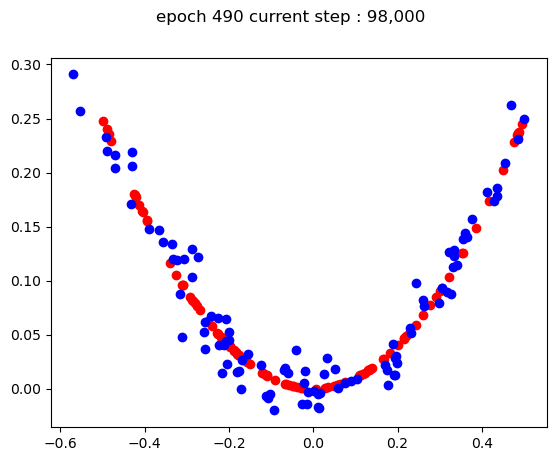


currentStep : 98,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4974,  0.6003]) y range : tensor([-0.0629,  0.3265]) max - min : tensor([1.0978, 0.3895])
Step 98,000: Generator loss: -0.7632256895303726, crtic loss: -0.010921092190989308
Memory usage (RSS): 427.4765625 MB


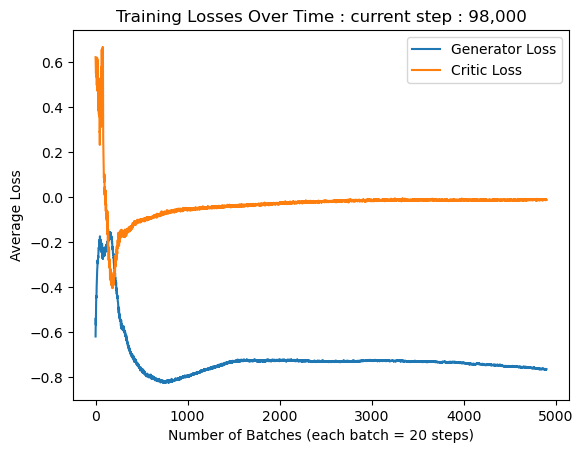

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch495.png


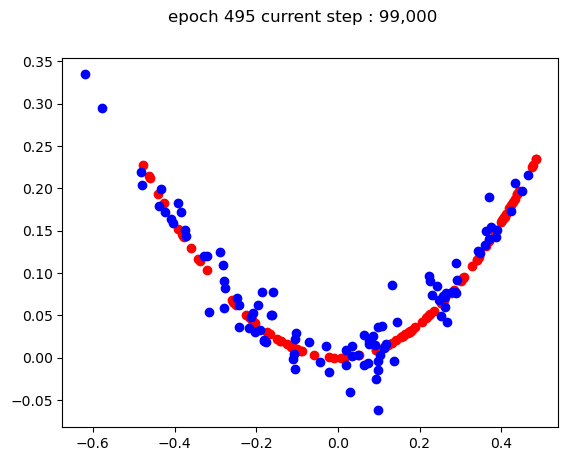


currentStep : 99,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4518,  0.4842]) y range : tensor([-0.0114,  0.2929]) max - min : tensor([0.9360, 0.3043])
Step 99,000: Generator loss: -0.7649312988519669, crtic loss: -0.010677488121628996
Memory usage (RSS): 427.48046875 MB


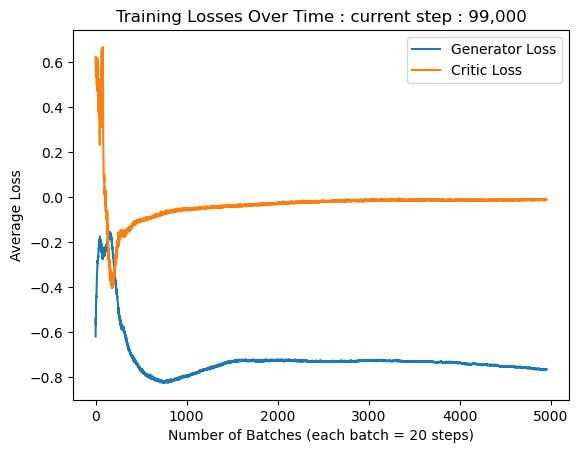

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch500.png


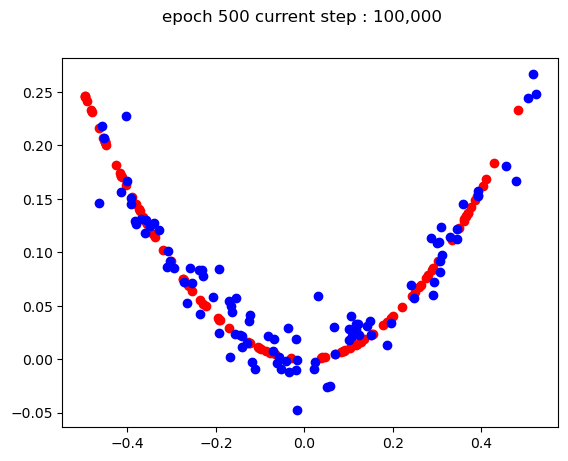


currentStep : 100,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.4717,  0.5510]) y range : tensor([-0.0176,  0.2951]) max - min : tensor([1.0227, 0.3127])
finished
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/WGAN_GP.out/img/generated_plot_epoch500.png


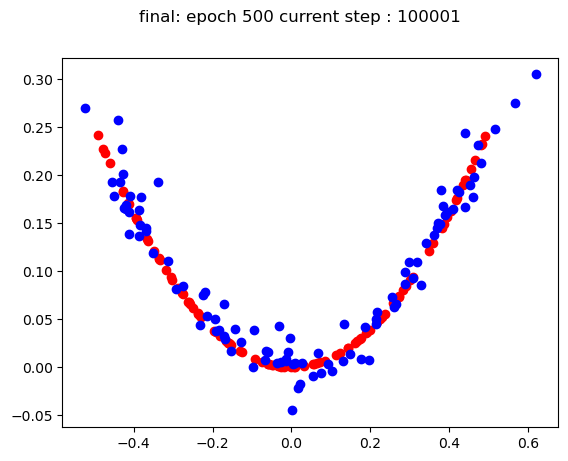

CPU times: user 48min 36s, sys: 2min 14s, total: 50min 51s
Wall time: 25min 41s


In [18]:
%%time

# reset state every time we run
currentStep = 0

# meanGeneratorLoss = 0
# meanDiscriminatorLoss = 0

generatorLosses = []
criticLosses = []

testGenerator= True # if true test generator weights are changing
error = False # default: no error


for epoch in range(nEpochs):

    #
    # add check point at end of each epoch    
    
    # tqdm provides progress bars for loops and iterables.
    # will choose implementaiton based on env. ie shell, juypter, ...
    # https://tqdm.github.io/
    # for i in tqdm( range(numBatchs) ) : 
    for i in range(numBatchs) : 
        # each epoch trains using all training samples where each sample is assigned to 
        # a random batch. After each patch update the model weights
        
        # if we where working with real data it is possible 
        # some batches are short. are < batchSize
        currentBatchSize = batchSize
        realSamples, realLabels = generateRealSamples( currentBatchSize )

        #################        
        ################# Update critic 
        #################        
        meanIterationCriticLoss = 0
        for _ in range( criticRepeats ):
            # update the critic multiple times every time you update the generator This helps 
            # prevent the generator from overpowering the critic. Sometimes, you might see the 
            # reverse, with the generator updated more times than the critic. This depends on 
            # architectural (e.g. the depth and width of the network) and algorithmic 
            # choices (e.g. which loss you're using).

            # Zero out the gradients before backpropagation
            criticOptimizer.zero_grad()
            
            # fakeSamples, fakeLabels  = generateFakeSamples( generator, zDim, currentBatchSize, device )
            # generate points in latent space
            noiseVector = generateLatentPoints(zDim, currentBatchSize)
            fakeSamples = generator( noiseVector )
            
            predictionsOnFakes = critic( fakeSamples )
            predictionsOnReal = critic( realSamples )
            
            epsilon = torch.rand( len(realSamples), 1, device=device, requires_grad=True )
            #print(f'aedwip epsilon.shape: {epsilon.shape}')
            #print(f'aedwip epsilon: {epsilon}')
            
            gradient = getGradient( critic, realSamples, fakeSamples.detach(), epsilon )
            gp = gradientPenalty( gradient )
            criticLoss = getCriticLoss( predictionsOnFakes, predictionsOnReal, gp, cLambda )
            
            # Keep track of the average critic loss in this batch
            meanIterationCriticLoss += criticLoss.item() / criticRepeats
            
            # Update gradients
            criticLoss.backward(retain_graph=True)
            
            # Update optimizer
            criticOptimizer.step()

        # concatenate the list items
        #print(f'aedwip meanIterationCriticLoss : {meanIterationCriticLoss}' )        
        criticLosses += [meanIterationCriticLoss]

        #################        
        ################# Update generator 
        ################# 
        meanIterationGeneratorLoss = 0
        for _ in range( generatorRepeats ):
            generatorOptimizer.zero_grad()
            # I think generateFakeSamples was preventing generator from updating
            #fakeSamples2, fakeLabels2  = generateFakeSamples( generator, zDim, currentBatchSize, device )
            noiseVector2 = generateLatentPoints(zDim, currentBatchSize)
            fakeSamples2 = generator( noiseVector2 )
            predictionsOnFakes2 = critic( fakeSamples2 )
            
            generatorLoss = getGeneratorLoss( predictionsOnFakes2 )
             # update the gradients
            generatorLoss.backward()
            
            # Update the weights
            generatorOptimizer.step()
            # Keep track of the average generators loss in this batch            
            meanIterationGeneratorLoss += generatorLoss.item() / generatorRepeats

           
    
            # Keep track of the average generator loss in this batch
        generatorLosses += [meanIterationGeneratorLoss]

        

        ### Visualization code ###
        if currentStep % displayStep == 0 and currentStep > 0:
            genMean = sum(generatorLosses[-displayStep:]) / displayStep
            criticMean = sum(criticLosses[-displayStep:]) / displayStep            
            msg = f'Step {currentStep:,}: Generator loss: {genMean}, crtic loss: {criticMean}'
            print( msg )

            # Get memory usage of the current process in bytes
            process = psutil.Process()
            memory_info = process.memory_info()
            rss_memory = memory_info.rss  # Resident Set Size (physical memory used)
            print("Memory usage (RSS):", rss_memory / (1024 * 1024), "MB")   
            
            #
            # plot learning curves
            # 
            stepBins = 20  # the number of step in each bin
            numExamples = (len(generatorLosses) // stepBins) * stepBins
            # print(f'aedwip len(generatorLosses) : {len(generatorLosses)}' )
            # print(f'aedwip numExamples : {numExamples}' )

            # create plots
            # x axis is the number of bings
            # y axis = averge loss for each bin
            plt.plot(
                range(numExamples // stepBins), 
                torch.Tensor(generatorLosses[:numExamples]).view(-1, stepBins).mean(1),
                label="Generator Loss"
            )            
            plt.plot(
                range(numExamples // stepBins), 
                torch.Tensor(criticLosses[:numExamples]).view(-1, stepBins).mean(1),
                label="Critic Loss"
            )
            
            plt.xlabel(f"Number of Batches (each batch = {stepBins} steps)")
            plt.ylabel("Average Loss")
            plt.title(f"Training Losses Over Time : current step : {currentStep:,}")

            plt.legend()
            plt.show()        
            
        currentStep += 1

        
        #if (epoch + 1) % displayQuotient == 0 and currentStep > 0:
        if currentStep % plotStep == 0 and currentStep > 0:
            title = f"epoch {epoch + 1:,} current step : {currentStep:,}"
            summarizePerformance(generator, zDim, imgOut, title)
            debugGAN(currentStep, criticRepeats, generatorRepeats, generator, zDim, currentBatchSize, device)


print(f'finished')
title = f"final: epoch {epoch + 1} current step : {currentStep + 1} "
summarizePerformance(generator, zDim, imgOut, title)

In [19]:
debugGAN(currentStep, criticRepeats, generatorRepeats, generator, zDim, currentBatchSize, device)


currentStep : 100,000 criticRepeats : 5 generatorRepeats : 1
x range : tensor([-0.6214,  0.4779]) y range : tensor([-0.0297,  0.3545]) max - min : tensor([1.0993, 0.3842])
